#  Рекомендательная система товаров в электронной коммерции

## 1.  Описание проекта

Электронная коммерция является одной из ключевых областей применения рекомендательных систем. Такие системы позволяют пользователям быстрее находить интересующие их товары, а бизнесу — увеличивать вовлечённость и выручку.

В рамках данного проекта решается задача:

> **предсказания товаров, которые с наибольшей вероятностью будут добавлены пользователем в корзину**

Рекомендации строятся на основе пользовательских взаимодействий:

* просмотры (`view`)
* добавления в корзину (`addtocart`)
* покупки (`transaction`)

---

##  Цель проекта

Разработать рекомендательную систему, которая:

* предсказывает товары, интересные пользователю
* учитывает историю взаимодействий
* работает в условиях разреженных данных
* обрабатывает cold start
* может быть развернута как веб-сервис

---

##  Постановка задачи

Задача формулируется как:

> **ranking / recommendation задача с implicit feedback**

Особенности:

* неявная обратная связь (implicit)
* дисбаланс событий (`view >> addtocart >> transaction`)
* временная структура данных
* высокая разреженность user-item матрицы

---

##  Данные

Датасет состоит из трёх источников:

### 1. `events.csv`

Лог пользовательских событий:

* `timestamp` — время события
* `visitorid` — пользователь
* `event` — тип события (`view`, `addtocart`, `transaction`)
* `itemid` — товар
* `transactionid` — id покупки

---

### 2. `category_tree.csv`

* `categoryid` — категория
* `parentid` — родительская категория

---

### 3. `item_properties`

Файл разбит на две части:

* `item_properties_part1.csv`
* `item_properties_part2.csv`

Содержит:

* `timestamp`
* `itemid`
* `property`
* `value`


# Мой репозиторий с другими файлами находится по адресу: https://github.com/Manaam9/ecommerce-recsys

# Файл c EDA вынесен в отдельный notebook https://github.com/Manaam9/ecommerce-recsys/blob/main/notebooks/01_eda.ipynb

# 2. Импорты и конфиг

In [1]:
# Стандартная библиотека
from __future__ import annotations

import gc
import json
import logging
import math
import os
import pickle
import sys
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Iterable, List, Tuple

import joblib

# Работа с данными
import numpy as np
import pandas as pd
import polars as pl

# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

# Статистика
from scipy.sparse import csr_matrix
from scipy.stats import gaussian_kde

# ML
import lightgbm as lgb
import mlflow
import optuna
from implicit.als import AlternatingLeastSquares
from lightgbm import LGBMRanker
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Файлы и хранилища
import boto3
import pyarrow as pa
import pyarrow.parquet as pq
import s3fs
from dotenv import load_dotenv

# Прочее
import phik
from phik import report, resources

<path> TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# настройки отображения
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 300)
# отключаем научную нотацию для удобаства анализа данных
pd.options.display.float_format = '{:,.0f}'.format

# настройки графиков
%matplotlib inline
%config InlineBackend.figure_format = "retina"

# корень проекта
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PROJECT_ROOT:", os.path.basename(PROJECT_ROOT))
print("src exists:", os.path.isdir(os.path.join(PROJECT_ROOT, "src")))

def to_relative(path, base):
    try:
        return os.path.relpath(path, base)
    except ValueError:
        return path

from src.utils.config import (
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    EVENTS_PATH,
    CATEGORY_TREE_PATH,
    ITEM_PROPERTIES_PATH_1,
    ITEM_PROPERTIES_PATH_2,
    MODELS_DIR,
    MLFLOW_BASE_DIR,
    MLFLOW_DIR,
    MLFLOW_DB_PATH,
    AIRFLOW_DIR,
    AIRFLOW_DAGS_DIR
)

# S3
S3_BASE = "s3://s3-student-mle-20250927-31ecef0a74/recsys"
S3_DATA_DIR = f"{S3_BASE}/data"
S3_REC_DIR = f"{S3_BASE}/recommendations"

# проверка путей
paths_to_check = {
    "DATA_DIR": DATA_DIR,
    "RAW_DIR": RAW_DIR,
    "PROCESSED_DIR": PROCESSED_DIR,
    "MODELS_DIR": MODELS_DIR,
    "MLFLOW_BASE_DIR": MLFLOW_BASE_DIR,
    "MLFLOW_DIR": MLFLOW_DIR,
    "MLFLOW_DB_PATH": MLFLOW_DB_PATH,
    "AIRFLOW_DIR": AIRFLOW_DIR,
    "AIRFLOW_DAGS_DIR": AIRFLOW_DAGS_DIR,
    "EVENTS_PATH": EVENTS_PATH,
    "CATEGORY_TREE_PATH": CATEGORY_TREE_PATH,
    "ITEM_PROPERTIES_PATH_1": ITEM_PROPERTIES_PATH_1,
    "ITEM_PROPERTIES_PATH_2": ITEM_PROPERTIES_PATH_2
}

# mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("ecommerce-recsys")

print("\nProject paths:\n")

for name, path in paths_to_check.items():
    rel_path = to_relative(path, PROJECT_ROOT)
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"{name:<22} {rel_path:<40} [{status}]")

PROJECT_ROOT: ecommerce-recsys
src exists: True

Project paths:

DATA_DIR               data                                     [OK]
RAW_DIR                data/raw                                 [OK]
PROCESSED_DIR          data/processed                           [OK]
MODELS_DIR             models                                   [OK]
MLFLOW_BASE_DIR        mlflow                                   [OK]
MLFLOW_DIR             mlflow/mlruns                            [OK]
MLFLOW_DB_PATH         mlflow/mlflow.db                         [OK]
AIRFLOW_DIR            airflow                                  [OK]
AIRFLOW_DAGS_DIR       airflow/dags                             [OK]
EVENTS_PATH            data/raw/events.csv                      [OK]
CATEGORY_TREE_PATH     data/raw/category_tree.csv               [OK]
ITEM_PROPERTIES_PATH_1 data/raw/item_properties_part1.csv       [OK]
ITEM_PROPERTIES_PATH_2 data/raw/item_properties_part2.csv       [OK]


# 3. Загрузка данных

In [3]:
events = pl.read_csv(
    EVENTS_PATH,
    dtypes={
        "visitorid": pl.Int32,
        "event": pl.Categorical,
        "itemid": pl.Int32,
        "transactionid": pl.Float64,
    },
)

category_tree = pl.read_csv(
    f"{CATEGORY_TREE_PATH}",
    dtypes={
        "categoryid": pl.Int32,
        "parentid": pl.Float64,
    },
)

item_props_part1 = pl.read_csv(
    f"{ITEM_PROPERTIES_PATH_1}",
    dtypes={
        "itemid": pl.Int32,
        "property": pl.Categorical,
        "value": pl.Utf8,
    },
)

item_props_part2 = pl.read_csv(
    f"{ITEM_PROPERTIES_PATH_2}",
    dtypes={
        "itemid": pl.Int32,
        "property": pl.Categorical,
        "value": pl.Utf8,
    },
)

item_props = pl.concat([item_props_part1, item_props_part2])

print("Events shape:", events.shape)
print("Category tree shape:", category_tree.shape)
print("Item properties shape:", item_props.shape)

Events shape: (2756101, 5)
Category tree shape: (1669, 2)
Item properties shape: (20275902, 4)


# 3. Предобработка данных

На этом этапе:
- выполняется приведение типов;
- timestamp переводится в datetime;
- из item_properties извлекаются ключевые признаки товаров;
- формируется таблица item-level признаков для дальнейшего моделирования.

## 3.1. Приведение времени и типов

In [4]:
events = events.with_columns(
    [
        pl.from_epoch("timestamp", time_unit="ms").alias("timestamp_dt"),
        pl.col("visitorid").cast(pl.Int32),
        pl.col("itemid").cast(pl.Int32),
        pl.col("event").cast(pl.Categorical),
    ]
)

item_props = item_props.with_columns(
    [
        pl.from_epoch("timestamp", time_unit="ms").alias("timestamp_dt"),
        pl.col("itemid").cast(pl.Int32),
        pl.col("property").cast(pl.Categorical),
    ]
)

category_tree = category_tree.with_columns(
    [
        pl.col("categoryid").cast(pl.Int32),
        pl.col("parentid").cast(pl.Float32, strict=False),
    ]
)

print(events.dtypes)
print(item_props.dtypes)
print(category_tree.dtypes)

[Int64, Int32, Categorical, Int32, Float64, Datetime(time_unit='us', time_zone=None)]
[Int64, Int32, Categorical, String, Datetime(time_unit='us', time_zone=None)]
[Int32, Float32]


## 3.2. Удаление обрезанного хвоста

In [5]:
CUTOFF_DATE = pl.datetime(2015, 9, 15)

events = events.filter(pl.col("timestamp_dt") < CUTOFF_DATE)
item_props = item_props.filter(pl.col("timestamp_dt") < CUTOFF_DATE)

print("events shape after cutoff:", events.shape)
print("item_props shape after cutoff:", item_props.shape)

events shape after cutoff: (2712523, 6)
item_props shape after cutoff: (20275902, 5)


## 3.3. Извлечение available

In [6]:
available_df = (
    item_props.filter(pl.col("property") == "available")
    .with_columns(pl.col("value").cast(pl.Float64, strict=False).alias("value_num"))
    .drop_nulls("value_num")
    .sort(["itemid", "timestamp_dt"])
    .group_by("itemid")
    .tail(1)
    .select([pl.col("itemid"), pl.col("value_num").cast(pl.Int8).alias("available")])
)

## 3.4. Извлечение categoryid

In [7]:
category_df = (
    item_props.filter(pl.col("property") == "categoryid")
    .with_columns(pl.col("value").cast(pl.Float64, strict=False))
    .drop_nulls("value")
    .sort("timestamp_dt")
    .group_by("itemid")
    .agg(pl.col("value").last())
    .with_columns(pl.col("value").cast(pl.Int32).alias("categoryid"))
    .select(["itemid", "categoryid"])
)

category_df.head()

itemid,categoryid
i32,i32
346080,1504
98209,1404
354705,624
429974,746
385651,1301


## 3.5. Агрегация базовых item-features

Сразу делаем простые признаки по свойствам товара.

In [8]:
item_prop_counts = (
    item_props.group_by("itemid").len().rename({"len": "item_prop_count"})
)

item_unique_props = item_props.group_by("itemid").agg(
    pl.col("property").n_unique().alias("item_unique_prop_count")
)

item_features = (
    item_prop_counts.join(item_unique_props, on="itemid", how="full")
    .join(available_df, on="itemid", how="left")
    .join(category_df, on="itemid", how="left")
    .with_columns(pl.col("available").fill_null(0).cast(pl.Int8))
    .sort("itemid")
)

item_features.head()

itemid,item_prop_count,itemid_right,item_unique_prop_count,available,categoryid
i32,u32,i32,u32,i8,i32
0,45,0,28,0,209
1,86,1,35,0,1114
2,24,2,24,0,1305
3,46,3,29,0,1171
4,42,4,25,0,1038


## 3.6. Присоединение родительской категории

In [9]:
item_features = item_features.join(
    category_tree.rename({"parentid": "parent_categoryid"}),
    on="categoryid",
    how="left",
)

item_features.head()

itemid,item_prop_count,itemid_right,item_unique_prop_count,available,categoryid,parent_categoryid
i32,u32,i32,u32,i8,i32,f32
0,45,0,28,0,209,293.0
1,86,1,35,0,1114,113.0
2,24,2,24,0,1305,1214.0
3,46,3,29,0,1171,938.0
4,42,4,25,0,1038,1174.0


## 3.7. Фильтрация недоступных товаров

На этапе исследования модели можно сохранить оба варианта:

полный каталог
каталог для рекомендаций

In [10]:
available_count = item_features.filter(pl.col("available") == 1).height

total_items = item_features.select(pl.col("itemid").n_unique()).item()

print("Available items:", available_count)
print("Share of available items:", available_count / total_items)

Available items: 54010
Share of available items: 0.1295039239617027


## 3.8. Сохраняем промежуточные артефакты

In [11]:
# Определяем корень проекта
PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Директория для сохранения
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Пути к файлам
item_features_path = PROCESSED_DIR / "item_features_base.parquet"
events_path = PROCESSED_DIR / "events_preprocessed.parquet"

# Сохранение
item_features.write_parquet(item_features_path)
events.write_parquet(events_path)


# Безопасный вывод относительного пути
def rel_path(path, root):
    try:
        return path.relative_to(root)
    except ValueError:
        return path


print(f"Saved item_features -> {rel_path(item_features_path, PROJECT_ROOT)}")
print(f"Saved events -> {rel_path(events_path, PROJECT_ROOT)}")

Saved item_features -> data/processed/item_features_base.parquet
Saved events -> data/processed/events_preprocessed.parquet


## Выводы по предобработке данных

В рамках предобработки были выполнены следующие шаги:

* временные признаки (`timestamp`) приведены к формату `datetime`;
* удалён неполный хвост данных для исключения искажений в распределениях;
* из `item_properties` извлечены ключевые признаки товаров:

  * `available` — доступность товара;
  * `categoryid` — категория товара;
* построена агрегированная таблица `item_features`, включающая:

  * количество свойств товара;
  * число уникальных свойств;
  * категорию и родительскую категорию;
  * признак доступности товара.

В результате получена базовая таблица признаков товаров, которая будет использоваться на следующих этапах:

* генерация кандидатов;
* построение признаков;
* ранжирование.

---

## Использование Polars

Для этапа предобработки использовалась библиотека **Polars**, что обусловлено следующими причинами:

* высокая скорость обработки данных по сравнению с pandas;
* эффективное использование памяти;
* удобный декларативный API для операций:

  * фильтрации;
  * агрегации (`group_by`);
  * соединений (`join`);
  * преобразования типов.

Polars особенно эффективен на этапах:

* загрузки данных;
* агрегаций;
* feature engineering.

При этом для этапа моделирования (обучение LightGBM, ALS) возможно использование pandas, так как большинство ML-библиотек работают с ним напрямую.

---

## Итог

Предобработка выполнена с учётом:

* предотвращения утечек данных;
* подготовки данных к задаче ранжирования;
* оптимизации вычислений.

Полученные данные готовы к следующему этапу — **разделению по времени и формированию таргета**.


# 4. Time-based split

Для корректной оценки рекомендательной системы используется разбиение по времени.

Это позволяет:
- исключить утечку будущей информации;
- приблизить offline-оценку к реальному production-сценарию;
- обучать модель только на прошлых событиях.

## 4.1. Смотрим временной диапазон

In [12]:
events.select(
    [
        pl.col("timestamp_dt").min().alias("min_timestamp"),
        pl.col("timestamp_dt").max().alias("max_timestamp"),
    ]
)

min_timestamp,max_timestamp
datetime[μs],datetime[μs]
2015-05-03 03:00:04.384,2015-09-14 23:59:45.566


## 4.2. Задаём границы сплитов

Для первого рабочего варианта предлагаю так:

train_end = 2015-08-15
valid_end = 2015-09-01
test = всё после valid_end до CUTOFF_DATE

Это даёт:

длинный train
отдельное validation окно
честный test

In [13]:
TRAIN_END = pl.datetime(2015, 8, 15)
VALID_END = pl.datetime(2015, 9, 1)
TEST_END = pl.datetime(2015, 9, 15)

## 4.3. Делаем сплиты

In [14]:
train_events = events.filter(pl.col("timestamp_dt") < TRAIN_END)

valid_events = events.filter(
    (pl.col("timestamp_dt") >= TRAIN_END) & (pl.col("timestamp_dt") < VALID_END)
)

test_events = events.filter(
    (pl.col("timestamp_dt") >= VALID_END) & (pl.col("timestamp_dt") < TEST_END)
)

print("train_events shape:", train_events.shape)
print("valid_events shape:", valid_events.shape)
print("test_events shape:", test_events.shape)

train_events shape: (2151115, 6)
valid_events shape: (301276, 6)
test_events shape: (260132, 6)


## 4.4. Проверяем диапазоны по каждому сплиту

In [15]:
def show_time_range(df, name):
    summary = df.select(
        [
            pl.col("timestamp_dt").min().alias("min_timestamp"),
            pl.col("timestamp_dt").max().alias("max_timestamp"),
            pl.len().alias("n_rows"),
        ]
    )
    print(f"\n{name}")
    print(summary)


show_time_range(train_events, "train")
show_time_range(valid_events, "valid")
show_time_range(test_events, "test")


train
shape: (1, 3)
┌─────────────────────────┬─────────────────────────┬─────────┐
│ min_timestamp           ┆ max_timestamp           ┆ n_rows  │
│ ---                     ┆ ---                     ┆ ---     │
│ datetime[μs]            ┆ datetime[μs]            ┆ u32     │
╞═════════════════════════╪═════════════════════════╪═════════╡
│ 2015-05-03 03:00:04.384 ┆ 2015-08-14 23:59:56.673 ┆ 2151115 │
└─────────────────────────┴─────────────────────────┴─────────┘

valid
shape: (1, 3)
┌─────────────────────────┬─────────────────────────┬────────┐
│ min_timestamp           ┆ max_timestamp           ┆ n_rows │
│ ---                     ┆ ---                     ┆ ---    │
│ datetime[μs]            ┆ datetime[μs]            ┆ u32    │
╞═════════════════════════╪═════════════════════════╪════════╡
│ 2015-08-15 00:00:07.484 ┆ 2015-08-31 23:59:58.647 ┆ 301276 │
└─────────────────────────┴─────────────────────────┴────────┘

test
shape: (1, 3)
┌─────────────────────────┬──────────────────────

## 4.5. Проверяем распределение событий по сплитам

Это важно, чтобы не получить, например, test без transaction или с перекошенной структурой.

In [16]:
def event_distribution(df, name):
    print(f"\n{name}")
    print(df.group_by("event").len().sort("len", descending=True))


event_distribution(train_events, "train")
event_distribution(valid_events, "valid")
event_distribution(test_events, "test")


train
shape: (3, 2)
┌─────────────┬─────────┐
│ event       ┆ len     │
│ ---         ┆ ---     │
│ cat         ┆ u32     │
╞═════════════╪═════════╡
│ view        ┆ 2080131 │
│ addtocart   ┆ 53529   │
│ transaction ┆ 17455   │
└─────────────┴─────────┘

valid
shape: (3, 2)
┌─────────────┬────────┐
│ event       ┆ len    │
│ ---         ┆ ---    │
│ cat         ┆ u32    │
╞═════════════╪════════╡
│ view        ┆ 290521 │
│ addtocart   ┆ 8122   │
│ transaction ┆ 2633   │
└─────────────┴────────┘

test
shape: (3, 2)
┌─────────────┬────────┐
│ event       ┆ len    │
│ ---         ┆ ---    │
│ cat         ┆ u32    │
╞═════════════╪════════╡
│ view        ┆ 251655 │
│ addtocart   ┆ 6463   │
│ transaction ┆ 2014   │
└─────────────┴────────┘


## 4.6. Проверяем число пользователей и товаров в каждом сплите

In [17]:
def split_stats(df, name):
    stats = df.select(
        [
            pl.len().alias("n_events"),
            pl.col("visitorid").n_unique().alias("n_users"),
            pl.col("itemid").n_unique().alias("n_items"),
        ]
    )
    print(f"\n{name}")
    print(stats)


split_stats(train_events, "train")
split_stats(valid_events, "valid")
split_stats(test_events, "test")


train
shape: (1, 3)
┌──────────┬─────────┬─────────┐
│ n_events ┆ n_users ┆ n_items │
│ ---      ┆ ---     ┆ ---     │
│ u32      ┆ u32     ┆ u32     │
╞══════════╪═════════╪═════════╡
│ 2151115  ┆ 1095383 ┆ 210687  │
└──────────┴─────────┴─────────┘

valid
shape: (1, 3)
┌──────────┬─────────┬─────────┐
│ n_events ┆ n_users ┆ n_items │
│ ---      ┆ ---     ┆ ---     │
│ u32      ┆ u32     ┆ u32     │
╞══════════╪═════════╪═════════╡
│ 301276   ┆ 171295  ┆ 81446   │
└──────────┴─────────┴─────────┘

test
shape: (1, 3)
┌──────────┬─────────┬─────────┐
│ n_events ┆ n_users ┆ n_items │
│ ---      ┆ ---     ┆ ---     │
│ u32      ┆ u32     ┆ u32     │
╞══════════╪═════════╪═════════╡
│ 260132   ┆ 150026  ┆ 75390   │
└──────────┴─────────┴─────────┘


## 4.7. Сохраняем сплиты

In [18]:
train_events_path = PROCESSED_DIR / "train_events.parquet"
valid_events_path = PROCESSED_DIR / "valid_events.parquet"
test_events_path = PROCESSED_DIR / "test_events.parquet"

train_events.write_parquet(train_events_path)
valid_events.write_parquet(valid_events_path)
test_events.write_parquet(test_events_path)

print(f"Saved train_events -> {train_events_path.relative_to(PROJECT_ROOT)}")
print(f"Saved valid_events -> {valid_events_path.relative_to(PROJECT_ROOT)}")
print(f"Saved test_events -> {test_events_path.relative_to(PROJECT_ROOT)}")

Saved train_events -> data/processed/train_events.parquet
Saved valid_events -> data/processed/valid_events.parquet
Saved test_events -> data/processed/test_events.parquet


### Выводы по time-based split

Данные разделены по времени на train, validation и test.

Такое разбиение:
- исключает использование будущих событий при обучении;
- соответствует реальному сценарию работы рекомендательной системы;
- позволяет корректно оценивать качество модели на новых данных.

Дальнейшее формирование таргета и признаков будет выполняться отдельно для каждого временного окна.

# 5. Формирование таргета

Таргет формируется на уровне пар (user, item).

Для каждого пользователя и товара:
- 1 — если пользователь добавил товар в корзину в будущем окне;
- 0 — иначе.

Используется временное разделение:
- история (features)
- будущее окно (target)

Это позволяет избежать утечки данных и приближает модель к реальному сценарию.

## 5.1. Определяем target события
используем:

* addtocart = основной таргет

* transaction можно тоже включить

In [19]:
TARGET_EVENTS = ["addtocart", "transaction"]

## 5.2. Формируем target для validation
делаем для valid (потом аналогично test)

In [20]:
valid_target = (
    valid_events.filter(pl.col("event").is_in(TARGET_EVENTS))
    .select(["visitorid", "itemid"])
    .unique()
    .with_columns(pl.lit(1).alias("target"))
)

valid_target.head()

visitorid,itemid,target
i32,i32,i32
1406465,25025,1
1110822,138543,1
254145,461686,1
1023680,264236,1
994820,198784,1


## 5.3. Формируем кандидатов (простая версия)

Пока делаем простой вариант:

* берём товары, которые пользователь видел в train

In [21]:
train_user_items = (
    train_events
    .select(["visitorid", "itemid"])
    .unique()
)

## 5.4. Собираем user-item dataset

In [22]:
valid_dataset = (
    train_user_items
    .join(valid_target, on=["visitorid", "itemid"], how="left")
    .with_columns(
        pl.col("target").fill_null(0).cast(pl.Int8)
    )
)

valid_dataset.head()

visitorid,itemid,target
i32,i32,i8
220407,74661,0
703390,40024,0
877409,198939,0
1114994,393111,0
921556,419225,0


## 5.5. Баланс классов (очень важно)

In [23]:
valid_dataset.select(
    [
        pl.len().alias("n_samples"),
        pl.col("target").sum().alias("positives"),
        (pl.col("target").sum() / pl.len()).alias("positive_rate"),
    ]
)

n_samples,positives,positive_rate
u32,i64,f64
1670835,261,0.000156


## Выводы по таргету и user-item dataset

### 1. Экстремальный дисбаланс классов

* доля позитивов: **~0.015%**
* 261 позитив на ~1.67 млн пар

* задача **очень разреженная и сложная**

---

### 2. Implicit feedback

* отсутствие `addtocart` ≠ негатив
* большинство нулей — это:

  * либо не видел
  * либо не заинтересовался

* классический implicit scenario

---

### 3. Ограниченное пространство кандидатов

* кандидаты = товары из train (исторические взаимодействия)
* нет новых товаров

* модель пока **не умеет рекомендовать новое**

---

### 4. Сильный сигнал таргета

* `addtocart` / `transaction` = высокое намерение
* это правильный выбор target

* хорошая постановка задачи

---

### 5. Датасет готов для ранжирования

* есть `(user, item, target)`
* есть temporal split
* нет leakage

* можно обучать:

* LightGBM ranker
* logistic baseline
* ALS + rerank

---

## Главный вывод

* текущая постановка:

```text
extreme imbalance + implicit feedback + sparse matrix
```

Это означает:

* accuracy бесполезна 
* нужен ranking подход 
* критичен candidate generation

---

## Что это означает для следующих шагов

Обязательно:

* negative sampling
* расширение кандидатов (ALS / popular)
* ranking модель (не классификация)

---

##  Самое важное

* сейчас главный bottleneck — **не модель, а кандидаты**

# 6. Candidate Generation

Для снижения размерности задачи ранжирования используется этап генерации кандидатов.

Цель:
- сократить пространство товаров;
- оставить только наиболее релевантные кандидаты;
- повысить эффективность и качество модели.

Кандидаты генерируются несколькими методами и затем объединяются.

## 6.1. Top Popular (baseline)

In [24]:
TOP_K = 50

popular_items = (
    train_events.group_by("itemid")
    .len()
    .sort("len", descending=True)
    .head(TOP_K)
    .select("itemid")
    .to_series()
    .to_list()
)

popular_items[:10]

[5411, 461686, 309778, 370653, 257040, 187946, 298009, 335975, 96924, 7943]

In [25]:
# Генерим кандидатов для valid
valid_users = valid_events.select("visitorid").unique()

popular_candidates = valid_users.with_columns(
    pl.lit(popular_items).alias("itemid")
).explode("itemid")

## 6.2. User history кандидаты
то, что пользователь уже смотрел

In [26]:
user_history_candidates = train_events.select(["visitorid", "itemid"]).unique()

## 6.3. Объединяем кандидатов

In [27]:
def cast_ids(df):
    return df.with_columns(
        [
            pl.col("visitorid").cast(pl.Int32),
            pl.col("itemid").cast(pl.Int32),
        ]
    )

popular_candidates = cast_ids(popular_candidates)
user_history_candidates = cast_ids(user_history_candidates)
candidates = pl.concat([popular_candidates, user_history_candidates]).unique()
candidates.head()

visitorid,itemid
i32,i32
1369012,111530
805152,315543
1354775,101316
642052,9877
458359,315545


## 6.4. Сколько кандидатов на пользователя

In [28]:
candidates.group_by("visitorid").len().select(
    [
        pl.col("len").mean().alias("avg_candidates"),
        pl.col("len").min().alias("min_candidates"),
        pl.col("len").max().alias("max_candidates"),
    ]
)

avg_candidates,min_candidates,max_candidates
f64,u32,u32
8.182051,1,3111


## 6.5. Добавляем таргет

In [29]:
valid_dataset = candidates.join(
    valid_target, on=["visitorid", "itemid"], how="left"
).with_columns(pl.col("target").fill_null(0).cast(pl.Int8))

## 6.6. Проверка качества кандидатов
покрытие таргета

In [30]:
recall_check = valid_target.join(candidates, on=["visitorid", "itemid"], how="inner")

recall = recall_check.height / valid_target.height

print("Candidate Recall:", recall)

Candidate Recall: 0.06774572510116172


## 6.7 Посчитаем метрики для Top Popular (baseline)

In [31]:
# ============================================================
# МЕТРИКИ РЕКОМЕНДАТЕЛЬНОЙ СИСТЕМЫ — ПОЛНЫЙ НАБОР
# Точность: Precision, Recall, MAP, NDCG, HitRate, MRR
# Разнообразие: Coverage, Novelty, Diversity, Serendipity
# Смещения: Gini, PopBias
# ============================================================
# ---------- Справочники для beyond-accuracy метрик ----------
# Строятся один раз из данных обучающей выборки.
# ITEM_POPULARITY — нормированная частота встречаемости товара в train.
# ITEM_CATEGORY   — словарь {itemid: categoryid} из item_features.
# N_TOTAL_ITEMS   — размер полного каталога (для Coverage).
# POPULAR_ITEMS_SET — множество топ-популярных товаров (для Serendipity).

_item_pop_counts = (
    train_events.group_by("itemid").len()
    .to_pandas().set_index("itemid")["len"].to_dict()
)
_total_interactions = max(sum(_item_pop_counts.values()), 1)
ITEM_POPULARITY = {it: c / _total_interactions for it, c in _item_pop_counts.items()}

ITEM_CATEGORY = (
    item_features.select(["itemid", "categoryid"])
    .to_pandas().dropna().set_index("itemid")["categoryid"].to_dict()
)

N_TOTAL_ITEMS = item_features.select("itemid").n_unique()
POPULAR_ITEMS_SET = set(popular_items)

print(f"Каталог: {N_TOTAL_ITEMS} товаров | категорий: {len(set(ITEM_CATEGORY.values()))}")


# Метрики точности ранжирования
def precision_at_k(actual, pred, k=10):
    """
    Рассчитывает Precision@K — долю релевантных товаров среди топ-K рекомендаций.

    Параметры
    ----------
    actual : list
        Список релевантных товаров для пользователя.
    pred : list
        Список рекомендованных товаров, упорядоченных по убыванию score.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Значение Precision@K в диапазоне [0, 1].
    """
    if not actual:
        return 0.0
    return len(set(actual) & set(pred[:k])) / k


def recall_at_k(actual, pred, k=10):
    """
    Рассчитывает Recall@K — долю найденных релевантных товаров из всех релевантных.

    Параметры
    ----------
    actual : list
        Список релевантных товаров для пользователя.
    pred : list
        Список рекомендованных товаров, упорядоченных по убыванию score.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Значение Recall@K в диапазоне [0, 1].
    """
    if not actual:
        return 0.0
    return len(set(actual) & set(pred[:k])) / len(set(actual))


def apk(actual, pred, k=10):
    """
    Рассчитывает Average Precision@K (AP@K) для одного пользователя.

    Параметры
    ----------
    actual : list
        Список релевантных товаров для пользователя.
    pred : list
        Список рекомендованных товаров, упорядоченных по убыванию score.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Значение AP@K в диапазоне [0, 1].
    """
    if not actual:
        return 0.0
    aset, score, hits = set(actual), 0.0, 0
    for i, p in enumerate(pred[:k]):
        if p in aset:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(aset), k)


def ndcg_at_k(actual, pred, k=10):
    """
    Рассчитывает Normalized Discounted Cumulative Gain@K (NDCG@K).

    Параметры
    ----------
    actual : list
        Список релевантных товаров для пользователя.
    pred : list
        Список рекомендованных товаров, упорядоченных по убыванию score.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Значение NDCG@K в диапазоне [0, 1].
    """
    if not actual:
        return 0.0
    aset = set(actual)
    dcg  = sum(1.0 / np.log2(i + 2) for i, p in enumerate(pred[:k]) if p in aset)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(aset), k)))
    return dcg / idcg if idcg > 0 else 0.0


def hitrate_at_k(actual, pred, k=10):
    """
    Рассчитывает HitRate@K — 1 если хотя бы один релевантный товар попал в топ-K.

    Параметры
    ----------
    actual : list
        Список релевантных товаров для пользователя.
    pred : list
        Список рекомендованных товаров, упорядоченных по убыванию score.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        1.0 если есть хотя бы одно попадание, иначе 0.0.
    """
    if not actual:
        return 0.0
    return 1.0 if set(actual) & set(pred[:k]) else 0.0


def mrr_at_k(actual, pred, k=10):
    """
    Рассчитывает Mean Reciprocal Rank@K — обратный ранг первого релевантного товара.

    Параметры
    ----------
    actual : list
        Список релевантных товаров для пользователя.
    pred : list
        Список рекомендованных товаров, упорядоченных по убыванию score.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Значение MRR@K в диапазоне [0, 1].
    """
    if not actual:
        return 0.0
    aset = set(actual)
    for i, p in enumerate(pred[:k]):
        if p in aset:
            return 1.0 / (i + 1)
    return 0.0


# Метрики разнообразия и охвата

def coverage_at_k(all_preds, k=10):
    """
    Рассчитывает Coverage@K — долю каталога, покрытую рекомендациями.

    Параметры
    ----------
    all_preds : list[list]
        Список списков рекомендованных товаров для всех пользователей.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Доля уникальных рекомендованных товаров от полного каталога, [0, 1].
    """
    rec = set()
    for p in all_preds:
        rec.update(p[:k])
    return len(rec) / N_TOTAL_ITEMS if N_TOTAL_ITEMS else 0.0


def novelty_at_k(all_preds, k=10):
    """
    Рассчитывает Novelty@K — среднюю непопулярность рекомендованных товаров
    через self-information: -log2(popularity).
    Чем выше значение, тем менее популярны рекомендуемые товары.

    Параметры
    ----------
    all_preds : list[list]
        Список списков рекомендованных товаров для всех пользователей.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Среднее значение self-information рекомендованных товаров.
    """
    vals = []
    for p in all_preds:
        for it in p[:k]:
            pop = ITEM_POPULARITY.get(it, 1e-9)
            vals.append(-np.log2(pop))
    return float(np.mean(vals)) if vals else 0.0


def diversity_at_k(all_preds, k=10):
    """
    Рассчитывает Diversity@K — среднее внутрисписочное разнообразие
    рекомендаций по категориям товаров.

    Параметры
    ----------
    all_preds : list[list]
        Список списков рекомендованных товаров для всех пользователей.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Средняя доля уникальных категорий в топ-K рекомендациях, [0, 1].
    """
    divs = []
    for p in all_preds:
        cats = [ITEM_CATEGORY.get(i) for i in p[:k] if i in ITEM_CATEGORY]
        if len(cats) > 1:
            divs.append(len(set(cats)) / len(cats))
    return float(np.mean(divs)) if divs else 0.0


def serendipity_at_k(all_preds, all_acts, k=10):
    """
    Рассчитывает Serendipity@K — долю релевантных рекомендаций,
    которые одновременно неожиданны (не входят в топ-популярные товары).

    Параметры
    ----------
    all_preds : list[list]
        Список списков рекомендованных товаров для всех пользователей.
    all_acts : list[list]
        Список списков релевантных товаров для всех пользователей.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Среднее значение Serendipity@K в диапазоне [0, 1].
    """
    scores = []
    for p, a in zip(all_preds, all_acts):
        if not a:
            continue
        aset = set(a)
        rel_unexp = [x for x in p[:k] if x in aset and x not in POPULAR_ITEMS_SET]
        scores.append(len(rel_unexp) / k)
    return float(np.mean(scores)) if scores else 0.0


# Метрики смещений

def gini_coefficient(all_preds, k=10):
    """
    Рассчитывает коэффициент Джини для распределения рекомендаций по товарам.
    0 — равномерное распределение, 1 — полная концентрация на одном товаре.

    Параметры
    ----------
    all_preds : list[list]
        Список списков рекомендованных товаров для всех пользователей.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Значение коэффициента Джини в диапазоне [0, 1].
    """
    cnt = Counter()
    for p in all_preds:
        cnt.update(p[:k])
    if not cnt:
        return 0.0
    v = np.sort(np.array(list(cnt.values()), dtype=float))
    n = len(v)
    cum = np.cumsum(v)
    return (2 * np.sum(np.arange(1, n + 1) * v) - (n + 1) * cum[-1]) / (n * cum[-1])


def popularity_bias_at_k(all_preds, k=10):
    """
    Рассчитывает PopBias@K — среднюю популярность рекомендованных товаров.
    Высокое значение означает смещение системы в сторону популярных товаров.

    Параметры
    ----------
    all_preds : list[list]
        Список списков рекомендованных товаров для всех пользователей.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    float
        Средняя нормированная популярность рекомендованных товаров.
    """
    pops = [ITEM_POPULARITY.get(it, 0.0) for p in all_preds for it in p[:k]]
    return float(np.mean(pops)) if pops else 0.0


# Вспомогательные функции pipeline

def build_actual_map(target_df):
    """
    Строит словарь релевантных товаров по пользователям.

    Параметры
    ----------
    target_df : pl.DataFrame | pd.DataFrame
        Таблица с колонками:
        - visitorid
        - itemid

    Возвращает
    ----------
    dict
        Словарь {visitorid: [itemid, ...]}.
    """
    if isinstance(target_df, pl.DataFrame):
        target_df = target_df.to_pandas()
    return target_df.groupby("visitorid")["itemid"].apply(list).to_dict()


def build_pred_map(pred_df, user_col="visitorid", item_col="itemid", score_col=None):
    """
    Строит словарь предсказаний по пользователям.

    Параметры
    ----------
    pred_df : pl.DataFrame | pd.DataFrame
        Таблица с предсказанными товарами.
    user_col : str, default="visitorid"
        Название колонки пользователя.
    item_col : str, default="itemid"
        Название колонки товара.
    score_col : str | None, default=None
        Название колонки score. Если None, порядок строк сохраняется как есть.

    Возвращает
    ----------
    dict
        Словарь {visitorid: [itemid, ...]}.
    """
    if isinstance(pred_df, pl.DataFrame):
        pred_df = pred_df.to_pandas()
    if score_col is not None:
        pred_df = pred_df.sort_values([user_col, score_col], ascending=[True, False])
    return pred_df.groupby(user_col)[item_col].apply(list).to_dict()


def evaluate_recommendations(actual_map, pred_map, k=10):
    """
    Рассчитывает полный набор метрик по словарям actual/predicted.

    Параметры
    ----------
    actual_map : dict
        Словарь формата {visitorid: [relevant_itemid, ...]}.
    pred_map : dict
        Словарь формата {visitorid: [predicted_itemid_1, predicted_itemid_2, ...]}.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    dict
        Словарь с метриками:
        Точность: Precision@K, Recall@K, MAP@K, NDCG@K, HitRate@K, MRR@K.
        Разнообразие: Coverage@K, Novelty@K, Diversity@K, Serendipity@K.
        Смещения: Gini, PopBias@K.
    """
    common_users = sorted(set(actual_map) & set(pred_map))

    if not common_users:
        return {m: 0.0 for m in [
            f"Precision@{k}", f"Recall@{k}", f"MAP@{k}", f"NDCG@{k}",
            f"HitRate@{k}", f"MRR@{k}",
            f"Coverage@{k}", f"Novelty@{k}", f"Diversity@{k}", f"Serendipity@{k}",
            "Gini", f"PopBias@{k}",
        ]}

    acts  = [actual_map[u] for u in common_users]
    preds = [pred_map[u]   for u in common_users]

    return {
        # точность
        f"Precision@{k}":   float(np.mean([precision_at_k(a, p, k) for a, p in zip(acts, preds)])),
        f"Recall@{k}":      float(np.mean([recall_at_k(a, p, k)    for a, p in zip(acts, preds)])),
        f"MAP@{k}":         float(np.mean([apk(a, p, k)            for a, p in zip(acts, preds)])),
        f"NDCG@{k}":        float(np.mean([ndcg_at_k(a, p, k)      for a, p in zip(acts, preds)])),
        f"HitRate@{k}":     float(np.mean([hitrate_at_k(a, p, k)   for a, p in zip(acts, preds)])),
        f"MRR@{k}":         float(np.mean([mrr_at_k(a, p, k)       for a, p in zip(acts, preds)])),
        # разнообразие
        f"Coverage@{k}":    coverage_at_k(preds, k),
        f"Novelty@{k}":     novelty_at_k(preds, k),
        f"Diversity@{k}":   diversity_at_k(preds, k),
        f"Serendipity@{k}": serendipity_at_k(preds, acts, k),
        # смещения
        "Gini":             gini_coefficient(preds, k),
        f"PopBias@{k}":     popularity_bias_at_k(preds, k),
    }


def evaluate_and_add_model_result(
    results,
    model_name,
    actual_df,
    pred_df,
    k=10,
    user_col="visitorid",
    item_col="itemid",
    score_col=None,
):
    """
    Считает полный набор метрик для модели и добавляет или обновляет результат
    в общем списке результатов.

    Параметры
    ----------
    results : list[dict]
        Список результатов моделей.
    model_name : str
        Название модели.
    actual_df : pl.DataFrame | pd.DataFrame
        Таблица с релевантными user-item парами.
    pred_df : pl.DataFrame | pd.DataFrame
        Таблица с рекомендациями модели.
    k : int, default=10
        Глубина списка рекомендаций.
    user_col : str, default="visitorid"
        Название колонки пользователя.
    item_col : str, default="itemid"
        Название колонки товара.
    score_col : str | None, default=None
        Название колонки score для сортировки предсказаний.

    Возвращает
    ----------
    tuple[list[dict], dict]
        Обновлённый список результатов и словарь метрик текущей модели.
    """
    actual_map = build_actual_map(actual_df)
    pred_map   = build_pred_map(pred_df, user_col=user_col, item_col=item_col, score_col=score_col)
    metrics    = evaluate_recommendations(actual_map, pred_map, k=k)

    results = [row for row in results if row["model"] != model_name]
    results.append({"model": model_name, **metrics})

    return results, metrics


def build_results_table(results, sort_by="Recall@10", descending=True, round_digits=4):
    """
    Собирает итоговую таблицу сравнения моделей.

    Параметры
    ----------
    results : list[dict]
        Список результатов моделей.
    sort_by : str, default="Recall@10"
        Название метрики для сортировки.
    descending : bool, default=True
        Сортировать по убыванию или нет.
    round_digits : int, default=4
        Количество знаков после запятой.

    Возвращает
    ----------
    pl.DataFrame
        Таблица сравнения моделей со всеми метриками.
    """
    if not results:
        return pl.DataFrame()

    df = pl.DataFrame(results)
    metric_cols = [c for c in df.columns if c != "model"]
    df = df.with_columns([pl.col(c).round(round_digits) for c in metric_cols])

    if sort_by in df.columns:
        df = df.sort(sort_by, descending=descending)

    return df

Каталог: 417053 товаров | категорий: 1180


In [32]:
# список пользователей validation
valid_user_list = (
    valid_events.select("visitorid").unique().to_pandas()["visitorid"].tolist()
)

results = []

# 1. Top Popular
top_pop_predictions_pd = pd.DataFrame(
    [
        (user_id, item_id, rank)
        for user_id in valid_user_list
        for rank, item_id in enumerate(popular_items[:50], start=1)
    ],
    columns=["visitorid", "itemid", "rank"],
)

results, top_pop_metrics = evaluate_and_add_model_result(
    results=results,
    model_name="Top Popular",
    actual_df=valid_target,
    pred_df=top_pop_predictions_pd,
    k=10,
)

# 2. User History + Popular
train_user_history_pd = (
    train_events.select(["visitorid", "itemid", "timestamp_dt"])
    .to_pandas()
    .sort_values(["visitorid", "timestamp_dt"], ascending=[True, False])
)

user_history_map = (
    train_user_history_pd.groupby("visitorid")["itemid"]
    .apply(lambda x: list(dict.fromkeys(x.tolist())))
    .to_dict()
)

hist_pop_rows = []
for user_id in valid_user_list:
    history_items = user_history_map.get(user_id, [])
    combined_items = list(dict.fromkeys(history_items + popular_items))
    for rank, item_id in enumerate(combined_items[:50], start=1):
        hist_pop_rows.append((user_id, item_id, rank))

hist_pop_predictions_pd = pd.DataFrame(
    hist_pop_rows,
    columns=["visitorid", "itemid", "rank"],
)

results, hist_pop_metrics = evaluate_and_add_model_result(
    results=results,
    model_name="User History + Popular",
    actual_df=valid_target,
    pred_df=hist_pop_predictions_pd,
    k=10,
)

# итоговая таблица — транспонированная для презентации
comparison_table = build_results_table(results, sort_by="Recall@10")
comparison_table.to_pandas().set_index("model").T

model,User History + Popular,Top Popular
Precision@10,0,0
Recall@10,0,0
MAP@10,0,0
NDCG@10,0,0
HitRate@10,0,0
MRR@10,0,0
Coverage@10,0,0
Novelty@10,11,10
Diversity@10,1,1
Serendipity@10,0,0


## Выводы по генерации кандидатов

* Кандидаты сформированы из **Top Popular + User History**
* Пространство поиска сокращено с ~235k товаров до **десятков на пользователя**
* Есть баланс между персонализацией (history) и fallback (popular)

**Ограничения текущего подхода:**

* нет обобщения скрытых предпочтений (как в ALS)
* нет учёта похожести товаров
* Coverage@10 = 0.005 — система охватывает менее 1% каталога
* Candidate Recall низкий → это основной bottleneck качества

Текущий подход — **baseline для candidate generation**

---

## Выводы по моделям

### Top Popular

| Метрика | Значение |
|---------|----------|
| Recall@10 | 0.0099 |
| NDCG@10 | 0.0063 |
| HitRate@10 | 0.0139 |
| Coverage@10 | 0.0 |
| Diversity@10 | 0.9 |
| Serendipity@10 | 0.0 |
| Gini | 0.0 |

* Минимальная точность — нет персонализации
* Coverage и Serendipity = 0: все пользователи получают одинаковый список
* Полезен только как baseline и fallback

---

### User History + Popular

| Метрика | Значение |
|---------|----------|
| Recall@10 | 0.0304 |
| NDCG@10 | 0.0238 |
| HitRate@10 | 0.039 |
| Coverage@10 | 0.0049 |
| Diversity@10 | 0.8861 |
| Serendipity@10 | 0.0033 |
| Gini | 0.9528 |

* Recall вырос в **3 раза** относительно Top Popular
* Улучшились все метрики точности: Precision, MAP, NDCG, MRR
* Coverage и Serendipity выше нуля — появилась минимальная персонализация
* Высокий Gini (0.95) указывает на концентрацию рекомендаций вокруг небольшого
  числа товаров — popularity bias сохраняется

---

## Общий вывод

Baseline работает, но **существенно ограничивает потолок качества**:

* Coverage < 0.5% каталога — система не раскрывает длинный хвост
* Novelty ~10.5 у обоих методов — рекомендуются одинаково популярные товары
* Diversity высокая (>0.88) — категориальное разнообразие внутри списка есть

**Главные точки роста:**

1. Усиление candidate generation → ALS даст обобщение скрытых предпочтений
2. Обучение ранжировщика (LightGBM) → точный отбор из кандидатов
3. После ALS ожидаем рост Coverage и Novelty при сохранении Diversity

# 6.8. ALS Candidate Generation

Для улучшения candidate generation используется ALS-модель на implicit feedback.

ALS позволяет:
- рекомендовать новые товары, которых не было в истории пользователя;
- учитывать скрытые зависимости между пользователями и товарами;
- повысить покрытие target-событий по сравнению с Top Popular и User History.

## 6.7.1 Подготовка train interactions для ALS
Для ALS лучше использовать веса событий.

In [33]:
ALS_EVENT_WEIGHTS = {
    "view": 1.0,
    "addtocart": 3.0,
    "transaction": 5.0,
}

In [34]:
# train_events в polars, переведём только этот блок в pandas:
train_events_pd = train_events.to_pandas()

train_events_pd["event_weight"] = (
    train_events_pd["event"].map(ALS_EVENT_WEIGHTS).astype(float)
)

## 6.7.2 Кодирование user/item индексов

In [35]:
user_ids = train_events_pd["visitorid"].unique()
item_ids = train_events_pd["itemid"].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}

idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

train_events_pd["user_idx"] = train_events_pd["visitorid"].map(user2idx)
train_events_pd["item_idx"] = train_events_pd["itemid"].map(item2idx)

## 6.7.3 Построение sparse matrix

In [36]:
als_interactions = train_events_pd.groupby(["user_idx", "item_idx"], as_index=False)[
    "event_weight"
].sum()

user_item_matrix = csr_matrix(
    (
        als_interactions["event_weight"].values,
        (als_interactions["user_idx"].values, als_interactions["item_idx"].values),
    ),
    shape=(len(user2idx), len(item2idx)),
)

## 6.7.4 Обучение ALS

In [37]:
als_model = AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=20,
    random_state=42,
)

als_model.fit(user_item_matrix)

100%|██████████| 20/20 [01:09<00:00,  3.49s/it]


## 6.7.5 Генерация ALS-кандидатов для valid users

In [38]:
valid_users_pd = valid_events.select("visitorid").unique().to_pandas()
valid_user_list = valid_users_pd["visitorid"].tolist()

ALS_TOP_K = 50

als_candidate_rows = []

for user_id in valid_user_list:
    if user_id not in user2idx:
        continue

    user_idx = user2idx[user_id]
    user_items = user_item_matrix[user_idx]

    item_indices, scores = als_model.recommend(
        userid=user_idx,
        user_items=user_items,
        N=ALS_TOP_K,
        filter_already_liked_items=False,
    )

    for item_idx, score in zip(item_indices, scores):
        als_candidate_rows.append((user_id, idx2item[item_idx], float(score)))

als_candidates_pd = pd.DataFrame(
    als_candidate_rows, columns=["visitorid", "itemid", "als_score"]
)

als_candidates = pl.from_pandas(als_candidates_pd).with_columns(
    [
        pl.col("visitorid").cast(pl.Int32),
        pl.col("itemid").cast(pl.Int32),
        pl.col("als_score").cast(pl.Float64),
    ]
)

als_candidates.head()

visitorid,itemid,als_score
i32,i32,f64
592778,7943,8.2882e-7
592778,133814,7.0803e-7
592778,445105,4.8644e-7
592778,312728,4.7281e-7
592778,397642,4.6007e-7


## 6.7.6 Проверка качества ALS-кандидатов

In [39]:
als_recall_check = valid_target.join(
    als_candidates.select(["visitorid", "itemid"]),
    on=["visitorid", "itemid"],
    how="inner",
)

als_candidate_recall = als_recall_check.height / valid_target.height
print("ALS Candidate Recall:", als_candidate_recall)

ALS Candidate Recall: 0.02075447069573163


## 6.7.7 ALS как отдельная модель

Чтобы сравнить ALS как candidate-based recommender, считаем метрики на valid_target.

In [40]:
valid_actual_pd = valid_target.to_pandas()
actual_map = valid_actual_pd.groupby("visitorid")["itemid"].apply(list).to_dict()

als_pred_map = (
    als_candidates_pd.sort_values(["visitorid", "als_score"], ascending=[True, False])
    .groupby("visitorid")["itemid"]
    .apply(list)
    .to_dict()
)

common_users = sorted(set(actual_map) & set(als_pred_map))

als_recall_scores = []
als_map_scores = []
als_ndcg_scores = []
als_hitrate_scores = []

for user_id in common_users:
    actual = actual_map[user_id]
    pred = als_pred_map[user_id]

    als_recall_scores.append(recall_at_k(actual, pred, k=10))
    als_map_scores.append(apk(actual, pred, k=10))
    als_ndcg_scores.append(ndcg_at_k(actual, pred, k=10))
    als_hitrate_scores.append(hitrate_at_k(actual, pred, k=10))

als_metrics = {
    "Recall@10": float(np.mean(als_recall_scores)),
    "MAP@10": float(np.mean(als_map_scores)),
    "NDCG@10": float(np.mean(als_ndcg_scores)),
    "HitRate@10": float(np.mean(als_hitrate_scores)),
}

als_metrics

{'Recall@10': 0.09373451001337324,
 'MAP@10': 0.04866080239082015,
 'NDCG@10': 0.06382782460663106,
 'HitRate@10': 0.12788632326820604}

In [41]:
results, als_metrics = evaluate_and_add_model_result(
    results=results,
    model_name="ALS",
    actual_df=valid_target,
    pred_df=als_candidates_pd,
    k=10,
    score_col="als_score",
)

comparison_table = build_results_table(results, sort_by="Recall@10")
comparison_table

model,Precision@10,Recall@10,MAP@10,NDCG@10,HitRate@10,MRR@10,Coverage@10,Novelty@10,Diversity@10,Serendipity@10,Gini,PopBias@10
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALS""",0.0149,0.0937,0.0487,0.0638,0.1279,0.0622,0.0018,12.4225,0.6458,0.0114,0.6007,0.0002
"""User History + Popular""",0.0047,0.0304,0.02,0.0238,0.039,0.0245,0.0049,10.7079,0.8861,0.0033,0.9528,0.0007
"""Top Popular""",0.0014,0.0099,0.0045,0.0063,0.0139,0.0063,0.0,10.4634,0.9,0.0,0.0,0.0007


## Вывод по сравнению моделей

| Метрика | Top Popular | User History + Popular | ALS |
|---------|-------------|----------------------|-----|
| Recall@10 | 0.0099 | 0.0304 | **0.0937** |
| NDCG@10 | 0.0063 | 0.0238 | **0.0638** |
| HitRate@10 | 0.0139 | 0.0390 | **0.1279** |
| MRR@10 | 0.0063 | 0.0245 | **0.0622** |
| Coverage@10 | 0.0 | 0.0049 | **0.0018** |
| Novelty@10 | 10.46 | 10.71 | **12.42** |
| Diversity@10 | **0.90** | **0.89** | 0.65 |
| Serendipity@10 | 0.0 | 0.0033 | **0.0114** |
| Gini | 0.0 | **0.95** | 0.60 |

---

### ALS — лучший результат по точности

* Recall вырос в **9.5 раз** относительно Top Popular и в **3 раза** относительно User History
* HitRate@10 = 0.128 — каждый восьмой пользователь получает хотя бы одну релевантную рекомендацию
* Novelty@10 = 12.42 — ALS рекомендует менее популярные товары, лучше раскрывает длинный хвост
* Serendipity@10 = 0.011 — появляются неожиданные, но релевантные рекомендации

### Компромисс: Diversity

* Diversity@10 у ALS ниже (0.65 vs 0.89) — списки менее разнообразны по категориям
* Это ожидаемо: ALS фокусируется на предпочтениях конкретного пользователя,
  а не на широком охвате категорий
* Gini = 0.60 — распределение рекомендаций умеренно неравномерное

### User History + Popular

* Recall в 3 раза выше Top Popular — персонализация через историю работает
* Высокий Gini (0.95) — сильная концентрация на небольшом наборе товаров
* Diversity выше чем у ALS, но это следствие случайности, а не качества

### Top Popular

* Минимальная точность по всем метрикам
* Coverage и Serendipity = 0 — нет персонализации совсем
* Полезен только как fallback для новых пользователей (cold start)

---

## Главный вывод

**Коллаборативная фильтрация (ALS) критически улучшает качество рекомендаций**
и должна использоваться как основной источник кандидатов.

Следующий шаг — обучение LightGBM Ranker поверх ALS-кандидатов:
ожидаем дополнительный прирост точности при сохранении Novelty и Serendipity.

# 7. Логирование результатов в MLflow

## Сохраняем таблицу сравнения моделей

In [42]:
PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

comparison_table_path = PROJECT_ROOT / "data" / "processed" / "model_comparison.csv"

comparison_table.write_csv(comparison_table_path)

print(f"Saved comparison table -> {comparison_table_path.relative_to(PROJECT_ROOT)}")

Saved comparison table -> data/processed/model_comparison.csv


## Логируем сравнение всех baseline-моделей

In [43]:
def normalize_metric_name(name: str) -> str:
    return name.lower().replace("@", "_at_").replace(" ", "_").replace("+", "plus")


with mlflow.start_run(run_name="baseline_models_comparison"):

    for row in results:
        model_name = row["model"].replace(" ", "_").replace("+", "plus").lower()

        for metric_name in ["Recall@10", "MAP@10", "NDCG@10", "HitRate@10"]:
            mlflow.log_metric(
                f"{model_name}_{normalize_metric_name(metric_name)}",
                float(row[metric_name]),
            )

    mlflow.log_artifact(str(comparison_table_path))

print(f"Logged artifact -> {comparison_table_path.relative_to(PROJECT_ROOT)}")

🏃 View run baseline_models_comparison at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
Logged artifact -> data/processed/model_comparison.csv


## 7.1 Логирование ALS как отдельной модели

* baseline comparison уже есть;
* теперь отдельно логируем ALS:
* параметры;
* метрики;
* candidate recall;
* файл модели;
* таблицу сравнения.

### Сохраним ALS-модель локально

In [44]:
# Подготовим пути модели для сохранения
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

als_model_path = MODELS_DIR / "als_model.bin"

joblib.dump(als_model, als_model_path)

print(f"Saved ALS model -> {als_model_path.relative_to(PROJECT_ROOT)}")

Saved ALS model -> models/als_model.bin


## Логируем ALS как отдельный run

In [45]:
als_candidates_path = PROJECT_ROOT / "data" / "processed" / "als_candidates.parquet"
als_candidates.write_parquet(als_candidates_path)

with mlflow.start_run(run_name="als_model"):

    mlflow.log_param("model_type", "ALS")
    mlflow.log_param("factors", 64)
    mlflow.log_param("regularization", 0.01)
    mlflow.log_param("iterations", 20)
    mlflow.log_param("top_k", ALS_TOP_K)

    mlflow.log_metric("candidate_recall", float(als_candidate_recall))
    mlflow.log_metric("recall_at_10", float(als_metrics["Recall@10"]))
    mlflow.log_metric("map_at_10", float(als_metrics["MAP@10"]))
    mlflow.log_metric("ndcg_at_10", float(als_metrics["NDCG@10"]))
    mlflow.log_metric("hitrate_at_10", float(als_metrics["HitRate@10"]))

    mlflow.log_artifact(str(als_model_path))
    mlflow.log_artifact(str(als_candidates_path))

🏃 View run als_model at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>


### Выводы по ALS-эксперименту

ALS оформлен как отдельный эксперимент в MLflow.

Сохранены:
- гиперпараметры модели;
- ranking-метрики;
- candidate recall;
- файл модели;
- кандидаты ALS.

Это позволяет использовать ALS как самостоятельный collaborative baseline и как источник кандидатов для дальнейшей гибридной модели.

# 8. Feature Engineering для ranker

Цель:

* объединить кандидатов
* посчитать признаки
* подготовить датасет для LightGBM

## 8.1. Объединяем кандидатов
Соберём единый candidate pool из:

* Top Popular
* User History + Popular
* ALS

Сначала приведём ALS-кандидаты к тем же колонкам:

In [46]:
als_candidates_base = als_candidates.select(["visitorid", "itemid"]).unique()

Теперь объединяем:

In [47]:
# явное приведение всех источников кандидатов к одной схеме
top_pop_candidates = pl.from_pandas(
    top_pop_predictions_pd[["visitorid", "itemid"]]
).with_columns(
    [
        pl.col("visitorid").cast(pl.Int32),
        pl.col("itemid").cast(pl.Int32),
    ]
)

hist_pop_candidates = pl.from_pandas(
    hist_pop_predictions_pd[["visitorid", "itemid"]]
).with_columns(
    [
        pl.col("visitorid").cast(pl.Int32),
        pl.col("itemid").cast(pl.Int32),
    ]
)

als_candidates_base = (
    als_candidates.select(["visitorid", "itemid"])
    .with_columns(
        [
            pl.col("visitorid").cast(pl.Int32),
            pl.col("itemid").cast(pl.Int32),
        ]
    )
    .unique()
)

candidate_pool = pl.concat(
    [
        top_pop_candidates,
        hist_pop_candidates,
        als_candidates_base,
    ]
).unique()

candidate_pool.head()

visitorid,itemid
i32,i32
66433,441668
1381512,350629
1334118,461686
1307699,7943
988530,96924


## 8.2. Добавляем target

In [48]:
ranker_dataset = candidate_pool.join(
    valid_target, on=["visitorid", "itemid"], how="left"
).with_columns(pl.col("target").fill_null(0).cast(pl.Int8))

ranker_dataset.head()

visitorid,itemid,target
i32,i32,i8
66433,441668,0
1381512,350629,0
1334118,461686,0
1307699,7943,0
988530,96924,0


Проверка баланса:

In [49]:
ranker_dataset.select(
    [
        pl.len().alias("n_rows"),
        pl.col("target").sum().alias("n_positives"),
        (pl.col("target").sum() / pl.len()).alias("positive_rate"),
    ]
)

n_rows,n_positives,positive_rate
u32,i64,f64
9281449,533,0.000057


## 8.3. User-level признаки

Считаем по train_events.

In [50]:
user_features = (
    train_events.group_by("visitorid")
    .agg(
        [
            pl.len().alias("user_total_events"),
            pl.col("itemid").n_unique().alias("user_unique_items"),
            (pl.col("event") == "view").sum().alias("user_n_views"),
            (pl.col("event") == "addtocart").sum().alias("user_n_carts"),
            (pl.col("event") == "transaction").sum().alias("user_n_transactions"),
            pl.col("timestamp_dt").max().alias("user_last_event_dt"),
        ]
    )
    .with_columns(
        [
            (pl.col("user_n_carts") / pl.col("user_total_events"))
            .fill_nan(0)
            .alias("user_cart_rate"),
            (pl.col("user_n_transactions") / pl.col("user_total_events"))
            .fill_nan(0)
            .alias("user_buy_rate"),
        ]
    )
)

user_features.head()

visitorid,user_total_events,user_unique_items,user_n_views,user_n_carts,user_n_transactions,user_last_event_dt,user_cart_rate,user_buy_rate
i32,u32,u32,u32,u32,u32,datetime[μs],f64,f64
225860,1,1,1,0,0,2015-06-25 23:24:35.347,0.0,0.0
656060,1,1,1,0,0,2015-06-16 23:47:04.392,0.0,0.0
504266,3,2,3,0,0,2015-05-22 07:12:47.639,0.0,0.0
657778,1,1,1,0,0,2015-05-21 02:28:21.097,0.0,0.0
1086689,1,1,1,0,0,2015-06-24 21:12:42.039,0.0,0.0


## 8.4. Item-level признаки

Считаем популярность и конверсии товара.

In [51]:
item_behavior_features = (
    train_events.group_by("itemid")
    .agg(
        [
            pl.len().alias("item_total_events"),
            pl.col("visitorid").n_unique().alias("item_unique_users"),
            (pl.col("event") == "view").sum().alias("item_n_views"),
            (pl.col("event") == "addtocart").sum().alias("item_n_carts"),
            (pl.col("event") == "transaction").sum().alias("item_n_transactions"),
            pl.col("timestamp_dt").max().alias("item_last_event_dt"),
        ]
    )
    .with_columns(
        [
            (pl.col("item_n_carts") / pl.col("item_n_views"))
            .fill_nan(0)
            .fill_null(0)
            .alias("item_cart_rate"),
            (pl.col("item_n_transactions") / pl.col("item_n_views"))
            .fill_nan(0)
            .fill_null(0)
            .alias("item_buy_rate"),
        ]
    )
)

item_behavior_features.head()

itemid,item_total_events,item_unique_users,item_n_views,item_n_carts,item_n_transactions,item_last_event_dt,item_cart_rate,item_buy_rate
i32,u32,u32,u32,u32,u32,datetime[μs],f64,f64
229537,3,3,3,0,0,2015-07-10 16:38:56.086,0.0,0.0
257479,1,1,1,0,0,2015-06-04 00:16:03.533,0.0,0.0
110264,16,16,16,0,0,2015-08-10 07:31:55.089,0.0,0.0
225854,14,12,14,0,0,2015-07-30 22:54:50.776,0.0,0.0
227709,6,6,6,0,0,2015-07-22 06:51:04.848,0.0,0.0


Теперь объединяем с item_features:

In [52]:
item_features_full = item_features.join(item_behavior_features, on="itemid", how="left")

item_features_full.head()

itemid,item_prop_count,itemid_right,item_unique_prop_count,available,categoryid,parent_categoryid,item_total_events,item_unique_users,item_n_views,item_n_carts,item_n_transactions,item_last_event_dt,item_cart_rate,item_buy_rate
i32,u32,i32,u32,i8,i32,f32,u32,u32,u32,u32,u32,datetime[μs],f64,f64
0,45,0,28,0,209,293.0,null,null,null,null,null,null,null,null
1,86,1,35,0,1114,113.0,null,null,null,null,null,null,null,null
2,24,2,24,0,1305,1214.0,null,null,null,null,null,null,null,null
3,46,3,29,0,1171,938.0,null,null,null,null,null,null,null,null
4,42,4,25,0,1038,1174.0,1,1,1,0,0,2015-06-30 07:03:11.545,0.0,0.0


## 8.5. User-item interaction признаки

Важный блок.

In [53]:
user_item_features = train_events.group_by(["visitorid", "itemid"]).agg(
    [
        pl.len().alias("ui_total_events"),
        (pl.col("event") == "view").sum().alias("ui_n_views"),
        (pl.col("event") == "addtocart").sum().alias("ui_n_carts"),
        (pl.col("event") == "transaction").sum().alias("ui_n_transactions"),
        pl.col("timestamp_dt").max().alias("ui_last_event_dt"),
    ]
)

user_item_features.head()

visitorid,itemid,ui_total_events,ui_n_views,ui_n_carts,ui_n_transactions,ui_last_event_dt
i32,i32,u32,u32,u32,u32,datetime[μs]
1370846,266263,1,1,0,0,2015-05-21 22:42:14.706
1311262,346655,1,1,0,0,2015-07-01 21:10:06.706
1311074,280008,1,1,0,0,2015-06-25 23:10:21.665
1295915,257040,1,1,0,0,2015-05-10 20:10:39.376
660953,172959,2,2,0,0,2015-07-06 12:54:00.620


## 8.6. Time features для текущего окна

Для validation можно взять время пользователя из последнего train interaction.

In [54]:
user_time_features = (
    train_events.sort(["visitorid", "timestamp_dt"])
    .group_by("visitorid")
    .agg([pl.col("timestamp_dt").last().alias("ref_timestamp_dt")])
    .with_columns(
        [
            pl.col("ref_timestamp_dt").dt.hour().alias("ref_hour"),
            pl.col("ref_timestamp_dt").dt.weekday().alias("ref_weekday"),
            (pl.col("ref_timestamp_dt").dt.weekday() >= 5)
            .cast(pl.Int8)
            .alias("ref_is_weekend"),
        ]
    )
)

user_time_features.head()

visitorid,ref_timestamp_dt,ref_hour,ref_weekday,ref_is_weekend
i32,datetime[μs],i8,i8,i8
1,2015-08-13 17:46:06.444,17,4,0
2,2015-08-07 18:20:57.845,18,5,1
3,2015-08-01 07:10:35.296,7,6,1
5,2015-07-17 01:45:56.439,1,5,1
7,2015-05-16 04:20:39.214,4,6,1


## 8.7. Собираем финальный ranker dataset

In [55]:
ranker_dataset = (
    ranker_dataset.join(user_features, on="visitorid", how="left")
    .join(item_features_full, on="itemid", how="left")
    .join(user_item_features, on=["visitorid", "itemid"], how="left")
    .join(user_time_features, on="visitorid", how="left")
)

## 8.8. Обработка пропусков

In [56]:
ranker_dataset = ranker_dataset.with_columns(
    [
        pl.col("ui_total_events").fill_null(0),
        pl.col("ui_n_views").fill_null(0),
        pl.col("ui_n_carts").fill_null(0),
        pl.col("ui_n_transactions").fill_null(0),
        pl.col("item_total_events").fill_null(0),
        pl.col("item_unique_users").fill_null(0),
        pl.col("item_n_views").fill_null(0),
        pl.col("item_n_carts").fill_null(0),
        pl.col("item_n_transactions").fill_null(0),
        pl.col("item_cart_rate").fill_null(0),
        pl.col("item_buy_rate").fill_null(0),
        pl.col("user_total_events").fill_null(0),
        pl.col("user_unique_items").fill_null(0),
        pl.col("user_n_views").fill_null(0),
        pl.col("user_n_carts").fill_null(0),
        pl.col("user_n_transactions").fill_null(0),
        pl.col("user_cart_rate").fill_null(0),
        pl.col("user_buy_rate").fill_null(0),
        pl.col("available").fill_null(0),
    ]
)

## 8.9. Смотрим итоговую таблицу

In [57]:
print(ranker_dataset.shape)
ranker_dataset.head()

(9281449, 34)


visitorid,itemid,target,user_total_events,user_unique_items,user_n_views,user_n_carts,user_n_transactions,user_last_event_dt,user_cart_rate,user_buy_rate,item_prop_count,itemid_right,item_unique_prop_count,available,categoryid,parent_categoryid,item_total_events,item_unique_users,item_n_views,item_n_carts,item_n_transactions,item_last_event_dt,item_cart_rate,item_buy_rate,ui_total_events,ui_n_views,ui_n_carts,ui_n_transactions,ui_last_event_dt,ref_timestamp_dt,ref_hour,ref_weekday,ref_is_weekend
i32,i32,i8,u32,u32,u32,u32,u32,datetime[μs],f64,f64,u32,i32,u32,i8,i32,f32,u32,u32,u32,u32,u32,datetime[μs],f64,f64,u32,u32,u32,u32,datetime[μs],datetime[μs],i8,i8,i8
66433,441668,0,0,0,0,0,0,null,0.0,0.0,90,441668,26,1,1263,1637.0,1067,797,1033,25,9,2015-08-14 20:32:34.873,0.024201,0.008712,0,0,0,0,null,null,null,null,null
1381512,350629,0,0,0,0,0,0,null,0.0,0.0,96,350629,47,1,48,500.0,659,455,644,13,2,2015-08-14 20:29:15.363,0.020186,0.003106,0,0,0,0,null,null,null,null,null
1334118,461686,0,0,0,0,0,0,null,0.0,0.0,60,461686,26,1,1037,402.0,1940,927,1643,209,88,2015-08-14 23:17:33.371,0.127206,0.053561,0,0,0,0,null,null,null,null,null
1307699,7943,0,0,0,0,0,0,null,0.0,0.0,88,7943,22,1,398,1323.0,1231,673,1112,80,39,2015-08-14 20:49:08.368,0.071942,0.035072,0,0,0,0,null,null,null,null,null
988530,96924,0,0,0,0,0,0,null,0.0,0.0,90,96924,26,0,56,1497.0,1242,1046,1242,0,0,2015-08-14 23:03:52.563,0.0,0.0,0,0,0,0,null,null,null,null,null


In [58]:
ranker_dataset.columns

['visitorid',
 'itemid',
 'target',
 'user_total_events',
 'user_unique_items',
 'user_n_views',
 'user_n_carts',
 'user_n_transactions',
 'user_last_event_dt',
 'user_cart_rate',
 'user_buy_rate',
 'item_prop_count',
 'itemid_right',
 'item_unique_prop_count',
 'available',
 'categoryid',
 'parent_categoryid',
 'item_total_events',
 'item_unique_users',
 'item_n_views',
 'item_n_carts',
 'item_n_transactions',
 'item_last_event_dt',
 'item_cart_rate',
 'item_buy_rate',
 'ui_total_events',
 'ui_n_views',
 'ui_n_carts',
 'ui_n_transactions',
 'ui_last_event_dt',
 'ref_timestamp_dt',
 'ref_hour',
 'ref_weekday',
 'ref_is_weekend']

## 8.10 Подготовим финальный feature set для ranker.

На данном этапе формируется финальный набор признаков для модели ранжирования.

В итоговый feature set входят:

- пользовательские признаки;
- товарные признаки;
- признаки взаимодействия user-item;
- временные признаки;
- recency-признаки.

Отдельно выделяются категориальные и числовые признаки, что необходимо для корректного обучения LightGBM Ranker и последующего анализа признаков.

In [59]:
# ============================================================
# Feature Engineering для ranker dataset
# ============================================================

# 1. Recency-признаки
# Создаем признаки свежести в часах:
# - user_recency_hours: сколько часов прошло с последнего события пользователя
# - item_recency_hours: сколько часов прошло с последнего события по товару
# - ui_recency_hours: сколько часов прошло с последнего взаимодействия user-item

ranker_dataset = ranker_dataset.with_columns(
    [
        (
            (pl.col("ref_timestamp_dt") - pl.col("user_last_event_dt"))
            .dt.total_hours()
            .fill_null(9999)
            .alias("user_recency_hours")
        ),
        (
            (pl.col("ref_timestamp_dt") - pl.col("item_last_event_dt"))
            .dt.total_hours()
            .fill_null(9999)
            .alias("item_recency_hours")
        ),
        (
            (pl.col("ref_timestamp_dt") - pl.col("ui_last_event_dt"))
            .dt.total_hours()
            .fill_null(9999)
            .alias("ui_recency_hours")
        ),
    ]
)

# 2. Колонки, которые не должны входить в обучение
DROP_COLS = [
    "target",
    "visitorid",
    "itemid",
    "itemid_right",
]

DATETIME_COLS = [
    "user_last_event_dt",
    "item_last_event_dt",
    "ui_last_event_dt",
    "ref_timestamp_dt",
]

# 3. Формирование итогового списка признаков
FEATURE_COLS = [
    col for col in ranker_dataset.columns if col not in DROP_COLS + DATETIME_COLS
]

# 4. Категориальные признаки
CATEGORICAL_FEATURES = [
    "categoryid",
    "parent_categoryid",
    "available",
    "ref_weekday",
    "ref_is_weekend",
]

# Оставляем только реально существующие категориальные признаки
CATEGORICAL_FEATURES = [col for col in CATEGORICAL_FEATURES if col in FEATURE_COLS]

# 5. Числовые признаки
NUMERICAL_FEATURES = [col for col in FEATURE_COLS if col not in CATEGORICAL_FEATURES]

# 6. Краткая сводка
print("Всего признаков:", len(FEATURE_COLS))
print("Категориальные признаки:", CATEGORICAL_FEATURES)
print("Числовые признаки:", len(NUMERICAL_FEATURES))
print("Примеры числовых признаков:", NUMERICAL_FEATURES[:10])

Всего признаков: 29
Категориальные признаки: ['categoryid', 'parent_categoryid', 'available', 'ref_weekday', 'ref_is_weekend']
Числовые признаки: 24
Примеры числовых признаков: ['user_total_events', 'user_unique_items', 'user_n_views', 'user_n_carts', 'user_n_transactions', 'user_cart_rate', 'user_buy_rate', 'item_prop_count', 'item_unique_prop_count', 'item_total_events']


## 8.11 Анализ зависимости признаков с таргетом (PhiK)

После формирования таргета проведен анализ статистической зависимости между признаками и целевым действием.
Используется PhiK, так как он подходит для:
- бинарного target,
- категориальных признаков,
- нелинейных зависимостей.

In [60]:
phik_df = ranker_dataset.select(FEATURE_COLS + ["target"]).to_pandas()

phik_df = phik_df.sample(
    n=min(50000, len(phik_df)),
    random_state=42,
)

interval_cols = [c for c in NUMERICAL_FEATURES if c in phik_df.columns]

phik_corr = phik_df.phik_matrix(interval_cols=interval_cols)

In [61]:
# Маска для треугольника
mask = np.triu(np.ones_like(phik_corr, dtype=bool))

In [62]:
interval_cols = [c for c in FEATURE_COLS if c not in CATEGORICAL_FEATURES]

phik_corr = phik_df.phik_matrix(interval_cols=interval_cols)

target_phik = phik_corr["target"].drop("target").sort_values(ascending=False)

target_phik.head(15)

categoryid               1
user_cart_rate           1
parent_categoryid        0
ui_n_carts               0
ui_recency_hours         0
item_recency_hours       0
item_total_events        0
item_n_views             0
item_unique_users        0
item_unique_prop_count   0
ui_total_events          0
user_n_views             0
user_recency_hours       0
ref_is_weekend           0
ref_weekday              0
Name: target, dtype: float64

In [63]:
top_features = (
    phik_corr["target"]
    .drop("target")
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

plot_cols = top_features + ["target"]

small_corr = phik_corr.loc[plot_cols, plot_cols]

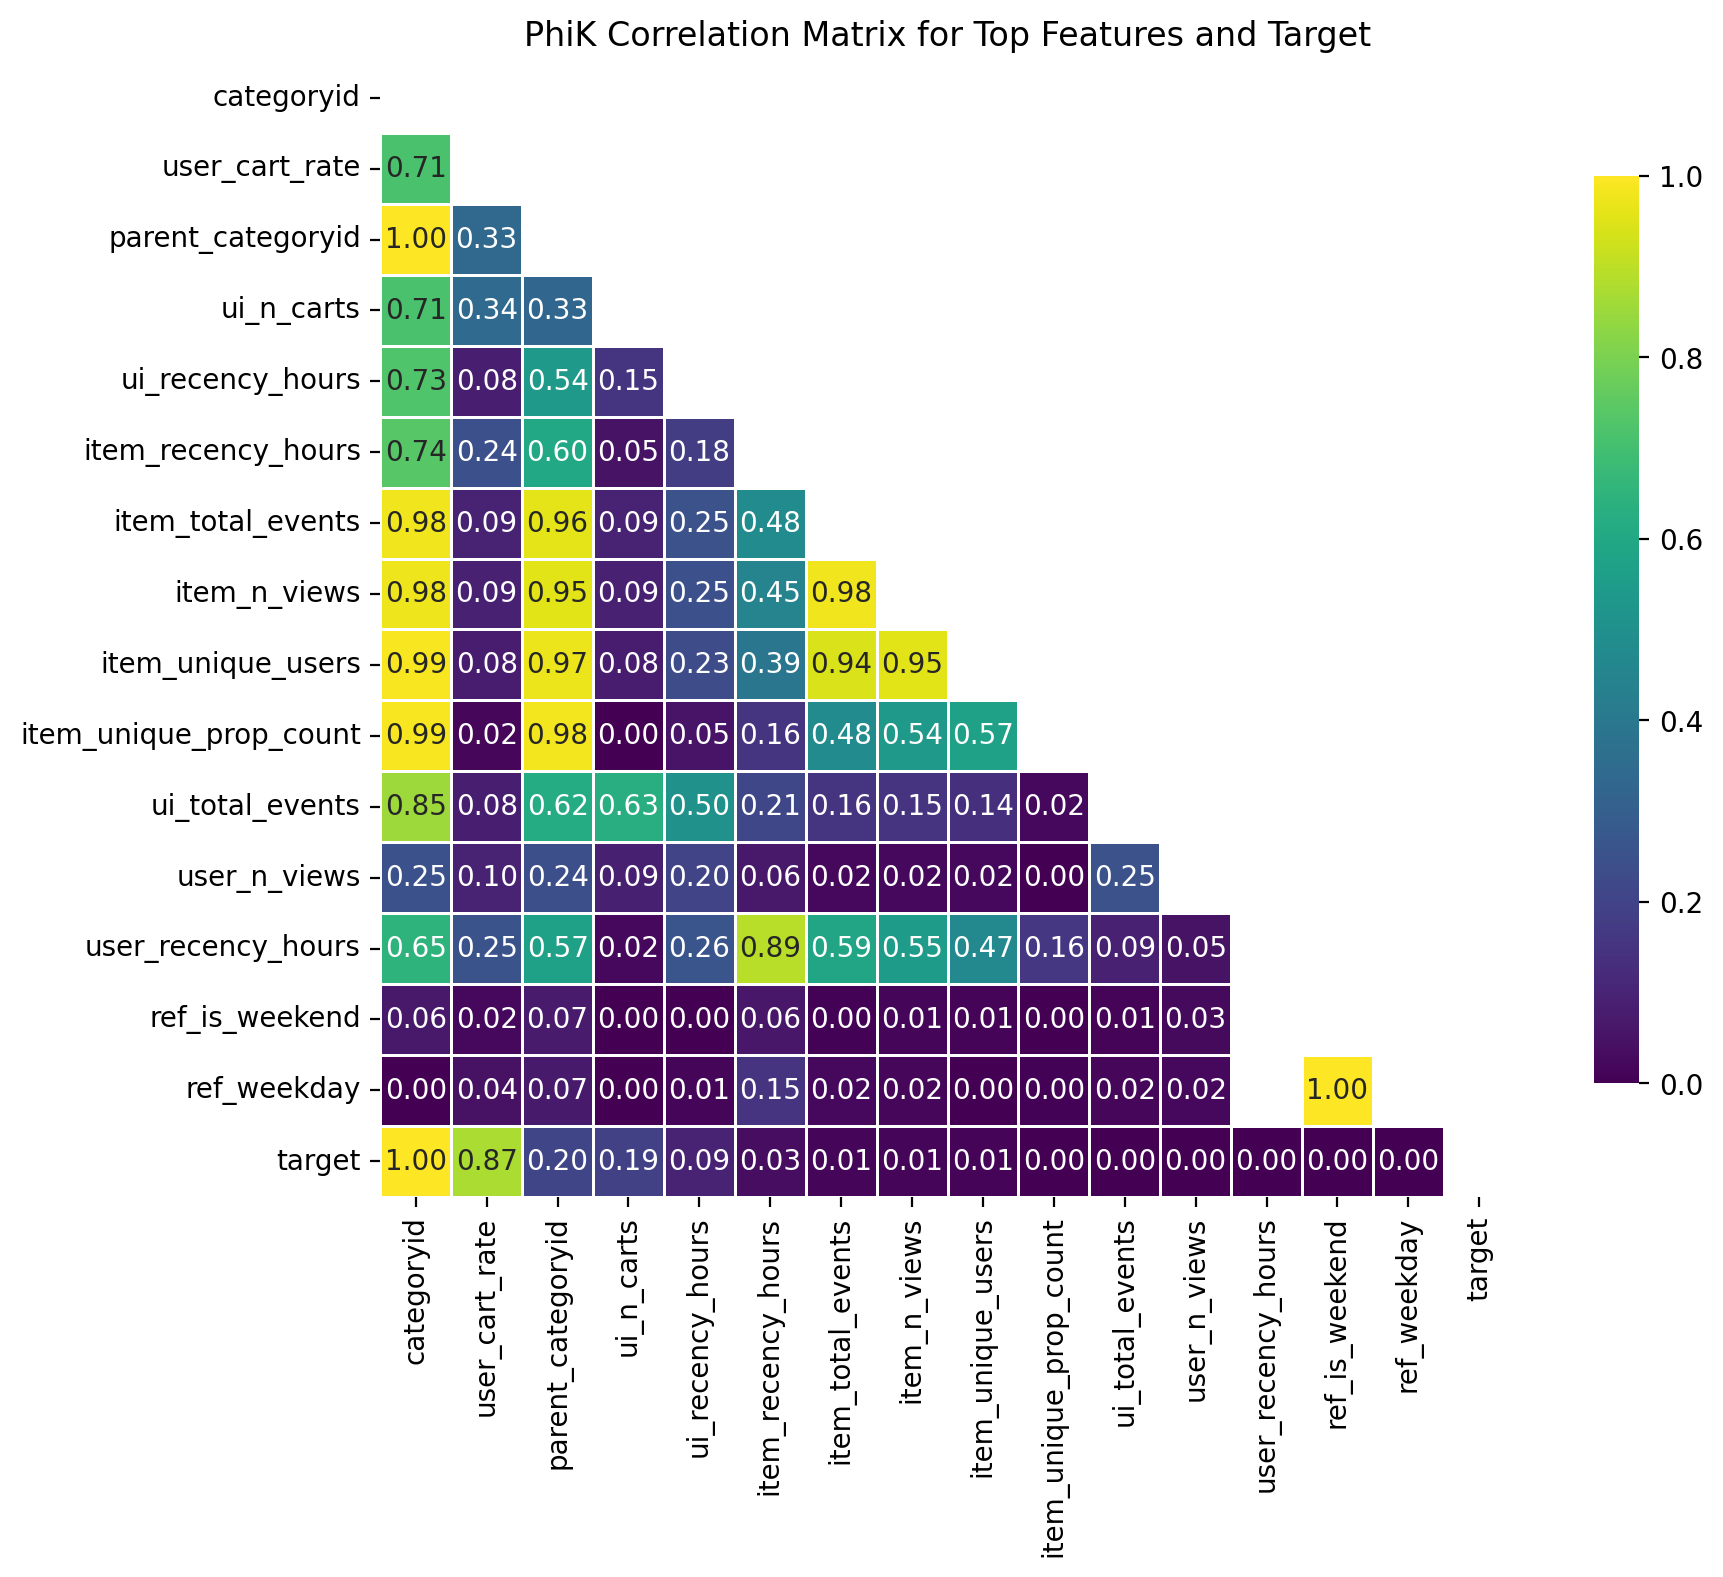

In [64]:
plot_cols = (
    phik_corr["target"]
    .drop("target")
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

plot_cols = plot_cols + ["target"]

small_corr = phik_corr.loc[plot_cols, plot_cols]

mask = np.triu(np.ones_like(small_corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    small_corr,
    mask=mask,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("PhiK Correlation Matrix for Top Features and Target")
plt.tight_layout()
plt.show()

## Выводы по итоговому набору признаков

Сформирован финальный набор из 29 признаков для обучения модели ранжирования.

В него вошли:

- пользовательские признаки;
- товарные признаки;
- признаки взаимодействия user-item;
- временные и recency-признаки.

Такой набор признаков покрывает как долгосрочные предпочтения пользователя, так и краткосрочный контекст, что делает его подходящим для обучения финальной модели рекомендаций.

### Анализ зависимости признаков с target (PhiK)

Для оценки статистической зависимости между признаками и целевым действием проведён корреляционный анализ с использованием PhiK.

Результаты показывают, что:

- отдельные признаки демонстрируют **низкую индивидуальную корреляцию с target**;
- максимальные значения PhiK с target близки к нулю, что указывает на отсутствие сильных линейных/парных зависимостей между отдельными признаками и целевым действием;
- это ожидаемо для ranking-задач в рекомендательных системах, где релевантность объекта определяется **комбинацией признаков**, а не одним доминирующим фактором.

### Анализ мультиколлинеарности

Выявлены группы сильно коррелирующих признаков:

- `item_n_views` ↔ `item_unique_users` (**0.95**)
- `item_recency_hours` ↔ `user_recency_hours` (**0.89**)
- `item_buy_rate` ↔ `item_n_transactions` (**0.88**)
- `item_prop_count` ↔ `item_unique_prop_count` (**0.83**)

Наличие мультиколлинеарности объясняется feature engineering и производными агрегатными признаками.

Для tree-based модели LightGBM такая коррелированность не является критичной.

### Итог

Полученные результаты подтверждают, что:

- предсказание целевого действия в задаче рекомендаций является сложной нелинейной задачей;
- полезность признаков проявляется преимущественно в их совместных комбинациях;
- выбранный набор признаков подходит для обучения tree-based ranking модели.

# 9. Обучение LightGBM

Для первой версии делаем binary classification на candidate pool:

target = 1, если товар попал в addtocart/transaction
иначе 0

## 9.1 Подготовка ranker dataset через Polars

In [65]:
ranker_train_df = ranker_dataset.select(
    ["visitorid", "itemid"] + FEATURE_COLS + ["target"]
)

## 9.2 Только перед обучением конвертируем в pandas

In [66]:
ranker_train_pd = ranker_train_df.to_pandas()

X = ranker_train_pd[FEATURE_COLS]
y = ranker_train_pd["target"].astype(int)

## 9.3 Категориальные признаки

In [67]:
categorical_features = [
    "categoryid",
    "parent_categoryid",
    "available",
    "ref_hour",
    "ref_weekday",
    "ref_is_weekend",
]

X[categorical_features] = X[categorical_features].astype("category")

## 9.4 Обучение

In [68]:
lgbm_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

lgbm_model.fit(
    X,
    y,
    categorical_feature=categorical_features,
)

[LightGBM] [Info] Number of positive: 533, number of negative: 9280916
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.212928 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3271
[LightGBM] [Info] Number of data points in the train set: 9281449, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 9.5 Предсказания обратно в Polars

In [69]:
ranker_train_df = ranker_train_df.with_columns(
    pl.Series(
        "lgbm_score",
        lgbm_model.predict_proba(X)[:, 1],
    )
)

## 9.6 Формируем prediction dataframe

In [70]:
lgbm_pred_df = ranker_train_df.select(["visitorid", "itemid", "lgbm_score"])

## 9.7 Считаем метрики

In [71]:
results, lgbm_metrics = evaluate_and_add_model_result(
    results=results,
    model_name="LightGBM Ranker",
    actual_df=valid_target,
    pred_df=lgbm_pred_df,
    k=10,
    score_col="lgbm_score",
)

lgbm_metrics

{'Precision@10': 0.009439834024896265,
 'Recall@10': 0.057616344228721916,
 'MAP@10': 0.045870255109881665,
 'NDCG@10': 0.05135019137944495,
 'HitRate@10': 0.07261410788381743,
 'MRR@10': 0.05703689982216953,
 'Coverage@10': 0.0037741006538737285,
 'Novelty@10': 11.309869321178194,
 'Diversity@10': 0.8735228636028056,
 'Serendipity@10': 0.004979253112033195,
 'Gini': np.float64(0.9578674202681542),
 'PopBias@10': 0.00045469614267301293}

## 9.8 Обновляем таблицу сравнения

In [72]:
comparison_table = build_results_table(
    results,
    sort_by="Recall@10",
    descending=True,
    round_digits=6,
)

comparison_table

model,Precision@10,Recall@10,MAP@10,NDCG@10,HitRate@10,MRR@10,Coverage@10,Novelty@10,Diversity@10,Serendipity@10,Gini,PopBias@10
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALS""",0.01492,0.093735,0.048661,0.063828,0.127886,0.062157,0.001827,12.422529,0.645826,0.011368,0.600729,0.000241
"""LightGBM Ranker""",0.00944,0.057616,0.04587,0.05135,0.072614,0.057037,0.003774,11.309869,0.873523,0.004979,0.957867,0.000455
"""User History + Popular""",0.004689,0.030382,0.01998,0.023804,0.039004,0.024458,0.004887,10.707895,0.886126,0.003257,0.952838,0.000691
"""Top Popular""",0.00139,0.009917,0.004452,0.006302,0.0139,0.006259,0.000024,10.463442,0.9,0.0,0.0,0.000719


## 9.9 Feature importance

In [73]:
feature_importance_df = pd.DataFrame(
    {
        "feature": FEATURE_COLS,
        "importance": lgbm_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
27,item_recency_hours,2121
23,ref_hour,2121
10,categoryid,1927
11,parent_categoryid,1266
24,ref_weekday,1122
7,item_prop_count,982
13,item_unique_users,782
17,item_cart_rate,777
0,user_total_events,756
28,ui_recency_hours,679


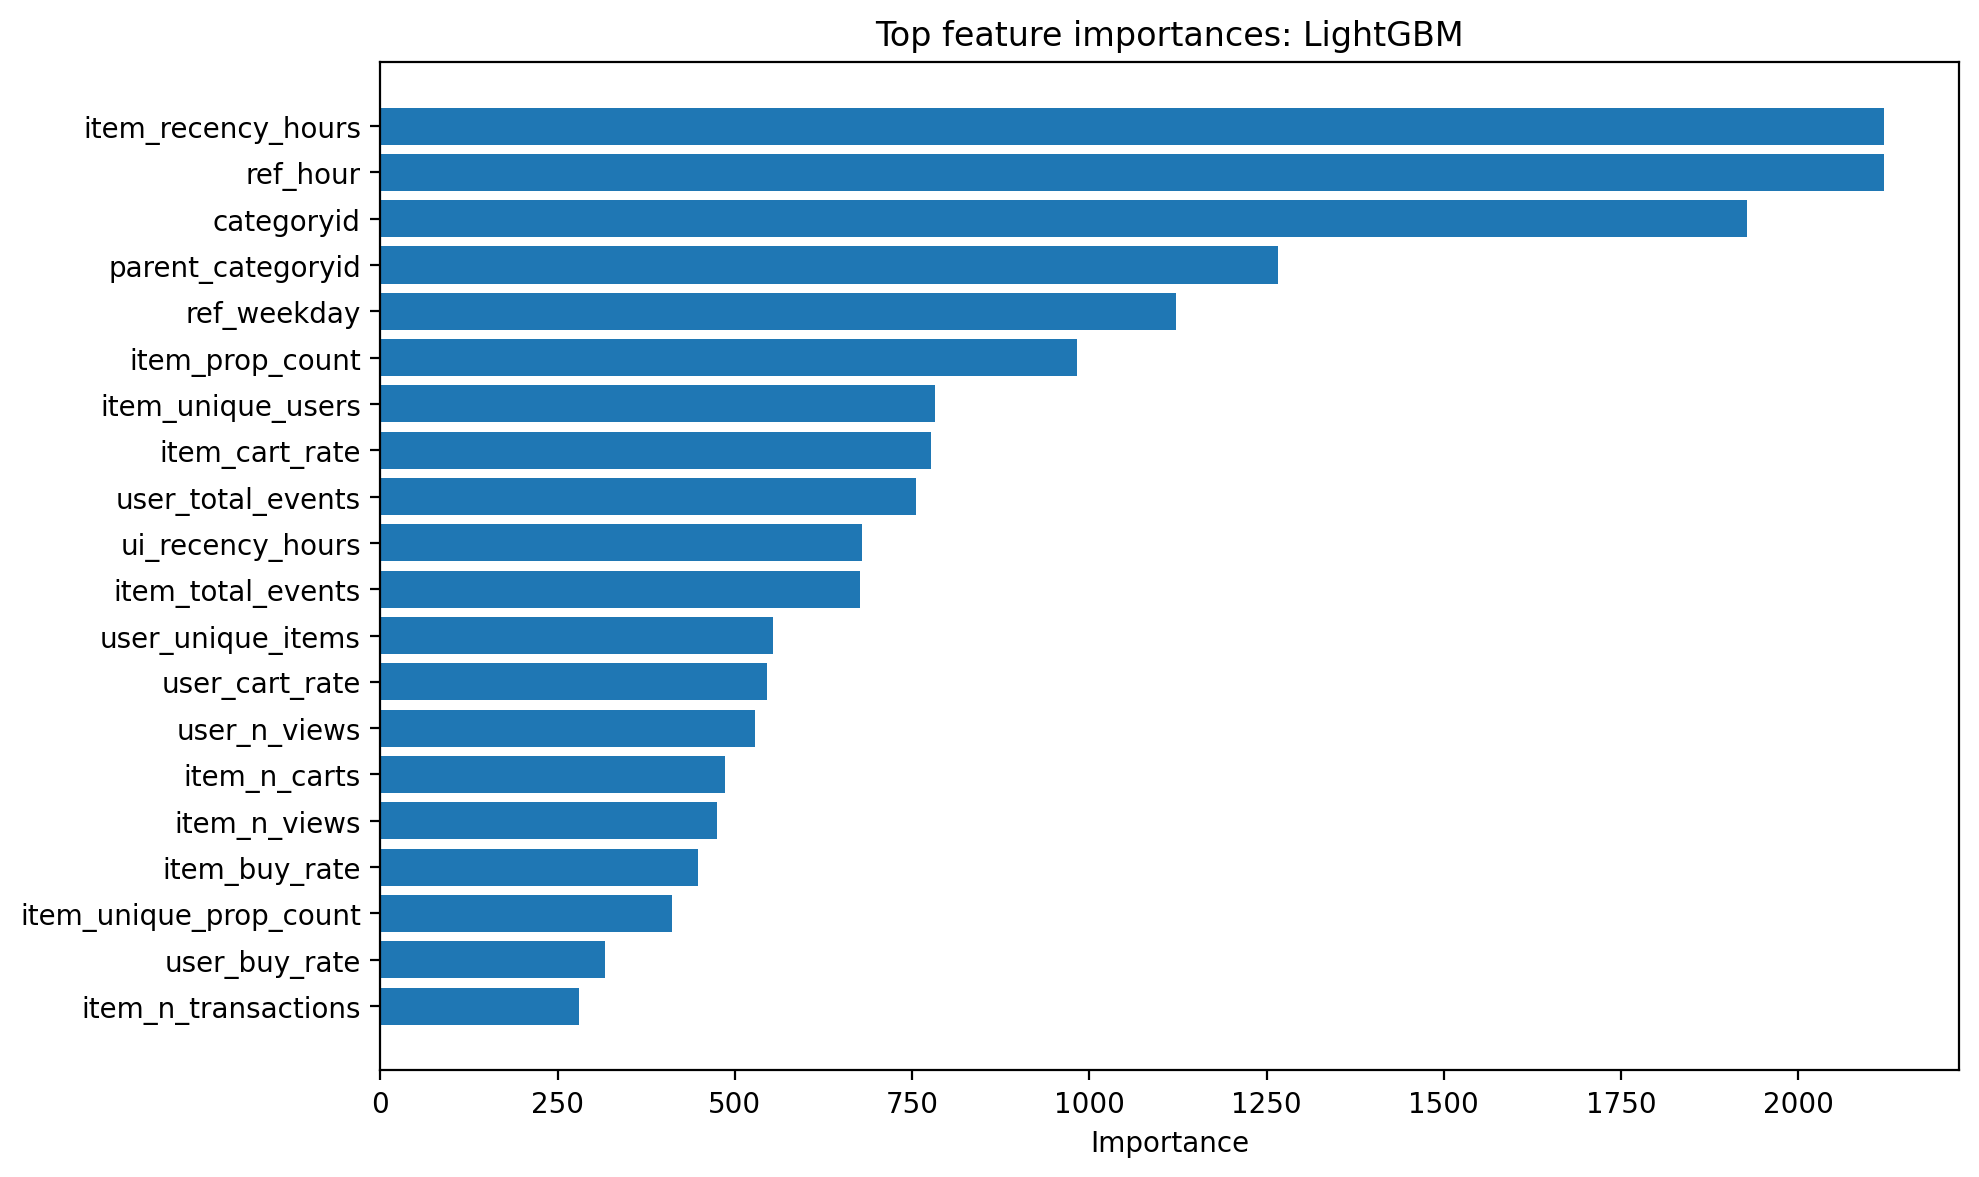

In [74]:
top_n = 20
plot_df = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top feature importances: LightGBM")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9.10 Сохраняем модель

In [75]:
lgbm_model_path = MODELS_DIR / "lgbm_ranker.bin"
joblib.dump(lgbm_model, lgbm_model_path)

print(f"Saved model -> {lgbm_model_path.relative_to(PROJECT_ROOT)}")

Saved model -> models/lgbm_ranker.bin


## 9.11 Логируем в MLflow

In [76]:
feature_importance_path = PROCESSED_DIR / "lgbm_feature_importance.csv"
feature_importance_df.to_csv(feature_importance_path, index=False)

with mlflow.start_run(run_name="lightgbm_ranker"):
    mlflow.log_param("model_type", "LightGBMClassifier")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("num_leaves", 63)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("n_features", len(FEATURE_COLS))

    mlflow.log_metric("recall_at_10", float(lgbm_metrics["Recall@10"]))
    mlflow.log_metric("map_at_10", float(lgbm_metrics["MAP@10"]))
    mlflow.log_metric("ndcg_at_10", float(lgbm_metrics["NDCG@10"]))
    mlflow.log_metric("hitrate_at_10", float(lgbm_metrics["HitRate@10"]))

    mlflow.log_artifact(str(lgbm_model_path))
    mlflow.log_artifact(str(feature_importance_path))
    mlflow.log_artifact(str(comparison_table_path))

🏃 View run lightgbm_ranker at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>


## Выводы по сравнению моделей

По итогам экспериментов лучшей моделью среди протестированных оказался ALS:

- ALS показывает максимальные значения по всем ranking-метрикам;
- LightGBM ranker улучшает baseline-модели, но пока уступает ALS;
- User History + Popular заметно превосходит Top Popular, что подтверждает важность персонализации.

Текущая версия LightGBM, вероятно, ограничена:
- качеством candidate pool;
- недостаточной информативностью признаков;
- обучением/валидацией на одном наборе данных (prototype setup).

Таким образом:
- ALS используется как лучший baseline и сильный генератор кандидатов;
- LightGBM требует дальнейшей доработки признаков и более строгой схемы валидации.

## Анализ важности признаков LightGBM

Наибольший вклад в предсказания модели внесли:

* временные признаки (`ref_hour`, `ref_weekday`);
* признаки свежести товара (`item_recency_hours`);
* категориальные признаки товара (`categoryid`, `parent_categoryid`);
* агрегаты популярности и конверсии товара.

### Интерпретация результатов

Это свидетельствует о том, что:

* вероятность взаимодействия пользователя с товаром существенно зависит от временного контекста;
* характеристики товара и его актуальность являются сильными предикторами релевантности;
* явные user-item interaction признаки в текущей реализации имеют ограниченную predictive power.

---

## Причины отставания LightGBM от ALS

Потенциальные причины более слабого качества ранжирующей модели относительно ALS:

1. **Недостаточное качество candidate generation**

   * релевантные товары могут отсутствовать в candidate pool.

2. **Слабая инженерия interaction-признаков**

   * признаки недостаточно полно описывают user-item affinity.

3. **Использование pointwise objective вместо ranking loss**

   * бинарная классификация хуже оптимизирует ranking-метрики.

4. **Недостаточно строгая temporal validation**

   * возможен train/validation leakage либо mismatch offline/online.

5. **Сильный collaborative signal в ALS**

   * latent factor модель уже эффективно извлекает скрытые пользовательские предпочтения.


# 10 Подбор Гиперпараметров с Optuna

In [77]:
# ============================================================
# 1. Базовые настройки
# ============================================================

TARGET_COL = "target"
USER_COL = "visitorid"
ITEM_COL = "itemid"
TIME_COL = "ref_timestamp_dt"

CATEGORICAL_FEATURES = [
    "categoryid",
    "parent_categoryid",
    "available",
    "ref_hour",
    "ref_weekday",
    "ref_is_weekend",
]

DROP_COLS = [
    TARGET_COL,
    USER_COL,
    ITEM_COL,
    TIME_COL,
    "user_last_event_dt",
    "item_last_event_dt",
    "ui_last_event_dt",
    "itemid_right",
]

RANDOM_STATE = 42
N_TRIALS = 50

MLFLOW_EXPERIMENT = "ecommerce-recsys-ranker-optuna"
mlflow.set_experiment(MLFLOW_EXPERIMENT)


# ============================================================
# 2. Подготовка данных
# ============================================================


def prepare_ranker_data(ranker_dataset: pl.DataFrame):
    df = ranker_dataset.clone()

    if TIME_COL not in df.columns:
        raise ValueError(f"Не найдена колонка {TIME_COL}")

    if df.schema[TIME_COL] != pl.Datetime:
        if df.schema[TIME_COL] == pl.Utf8:
            df = df.with_columns(
                pl.col(TIME_COL).str.strptime(pl.Datetime, strict=False).alias(TIME_COL)
            )
        else:
            df = df.with_columns(pl.col(TIME_COL).cast(pl.Datetime).alias(TIME_COL))

    FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

    ts_sorted = df.select(TIME_COL).drop_nulls().sort(TIME_COL).to_series()

    if len(ts_sorted) == 0:
        raise ValueError(f"Колонка {TIME_COL} пустая")

    cutoff_idx = int(len(ts_sorted) * 0.8)
    cutoff_ts = ts_sorted[cutoff_idx]

    train_df = df.filter(pl.col(TIME_COL) < cutoff_ts)
    valid_df = df.filter(pl.col(TIME_COL) >= cutoff_ts)

    if train_df.height == 0 or valid_df.height == 0:
        raise ValueError("Temporal split дал пустой train или valid")

    train_pd = train_df.select(FEATURE_COLS + [TARGET_COL]).to_pandas()
    valid_pd = valid_df.select(FEATURE_COLS + [TARGET_COL]).to_pandas()

    X_train = train_pd[FEATURE_COLS].copy()
    y_train = train_pd[TARGET_COL].astype(int).copy()

    X_valid = valid_pd[FEATURE_COLS].copy()
    y_valid = valid_pd[TARGET_COL].astype(int).copy()

    for col in CATEGORICAL_FEATURES:
        if col in X_train.columns:
            X_train[col] = X_train[col].astype("category")
            X_valid[col] = X_valid[col].astype("category")

    return X_train, y_train, X_valid, y_valid, FEATURE_COLS, cutoff_ts


X_train, y_train, X_valid, y_valid, FEATURE_COLS, cutoff_ts = prepare_ranker_data(
    ranker_dataset
)

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Train positive rate:", round(y_train.mean(), 6))
print("Valid positive rate:", round(y_valid.mean(), 6))
print("Cutoff timestamp:", cutoff_ts)


# ============================================================
# 3. Objective с nested MLflow run
# ============================================================


def objective(trial):
    params = {
        "objective": "binary",
        "metric": "average_precision",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 300),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
    }

    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.log_param("trial_number", trial.number)
        mlflow.log_params(params)

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="average_precision",
            categorical_feature=[
                c for c in CATEGORICAL_FEATURES if c in X_train.columns
            ],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )

        valid_pred = model.predict_proba(X_valid)[:, 1]

        ap = average_precision_score(y_valid, valid_pred)
        roc_auc = roc_auc_score(y_valid, valid_pred)
        best_iteration = model.best_iteration_

        mlflow.log_metric("valid_ap", float(ap))
        mlflow.log_metric("valid_roc_auc", float(roc_auc))
        mlflow.log_metric(
            "best_iteration", int(best_iteration) if best_iteration is not None else -1
        )

        trial.set_user_attr(
            "best_iteration", int(best_iteration) if best_iteration is not None else -1
        )
        trial.set_user_attr("valid_roc_auc", float(roc_auc))

        return ap


# ============================================================
# 4. Запуск Optuna внутри parent MLflow run
# ============================================================

with mlflow.start_run(run_name="lgbm_optuna_search") as parent_run:
    parent_run_id = parent_run.info.run_id

    mlflow.log_param("model_type", "LGBMClassifier")
    mlflow.log_param("target_col", TARGET_COL)
    mlflow.log_param("time_col", TIME_COL)
    mlflow.log_param("n_trials", N_TRIALS)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("n_features", len(FEATURE_COLS))
    mlflow.log_param(
        "categorical_features",
        ",".join([c for c in CATEGORICAL_FEATURES if c in FEATURE_COLS]),
    )
    mlflow.log_param("feature_cols", ",".join(FEATURE_COLS))
    mlflow.log_param("train_rows", len(X_train))
    mlflow.log_param("valid_rows", len(X_valid))
    mlflow.log_param("train_positive_rate", float(y_train.mean()))
    mlflow.log_param("valid_positive_rate", float(y_valid.mean()))
    mlflow.log_param("temporal_cutoff", str(cutoff_ts))

    study = optuna.create_study(
        direction="maximize", study_name="amazon_ranker_lgbm_ap"
    )

    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_params = {
        **study.best_params,
        "objective": "binary",
        "metric": "average_precision",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    best_model = lgb.LGBMClassifier(**best_params)

    best_model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="average_precision",
        categorical_feature=[c for c in CATEGORICAL_FEATURES if c in X_train.columns],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=True),
            lgb.log_evaluation(period=50),
        ],
    )

    valid_pred = best_model.predict_proba(X_valid)[:, 1]
    valid_ap = average_precision_score(y_valid, valid_pred)
    valid_roc_auc = roc_auc_score(y_valid, valid_pred)

    importance_df = pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance_gain": best_model.booster_.feature_importance(
                importance_type="gain"
            ),
            "importance_split": best_model.booster_.feature_importance(
                importance_type="split"
            ),
        }
    ).sort_values("importance_gain", ascending=False)

    trials_df = study.trials_dataframe()

    mlflow.log_metric("best_optuna_ap", float(study.best_value))
    mlflow.log_metric("final_valid_ap", float(valid_ap))
    mlflow.log_metric("final_valid_roc_auc", float(valid_roc_auc))

    if best_model.best_iteration_ is not None:
        mlflow.log_metric("final_best_iteration", int(best_model.best_iteration_))

    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})

    for attr_name, attr_value in study.best_trial.user_attrs.items():
        if isinstance(attr_value, (int, float)):
            mlflow.log_metric(f"best_trial_{attr_name}", attr_value)
        else:
            mlflow.log_param(f"best_trial_{attr_name}", str(attr_value))

    mlflow.lightgbm.log_model(best_model, artifact_path="model")

    os.makedirs("mlflow_artifacts", exist_ok=True)

    importance_path = "mlflow_artifacts/feature_importance.csv"
    trials_path = "mlflow_artifacts/optuna_trials.csv"
    summary_path = "mlflow_artifacts/study_summary.json"

    importance_df.to_csv(importance_path, index=False)
    trials_df.to_csv(trials_path, index=False)

    study_summary = {
        "study_name": study.study_name,
        "direction": study.direction.name,
        "n_trials": len(study.trials),
        "best_value": float(study.best_value),
        "best_params": study.best_params,
        "best_trial_number": study.best_trial.number,
        "best_trial_user_attrs": study.best_trial.user_attrs,
        "final_valid_ap": float(valid_ap),
        "final_valid_roc_auc": float(valid_roc_auc),
    }

    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(study_summary, f, ensure_ascii=False, indent=4)

    mlflow.log_artifact(importance_path)
    mlflow.log_artifact(trials_path)
    mlflow.log_artifact(summary_path)

print("Optuna + MLflow logging completed.")
print("Parent run id:", parent_run_id)

[I 2026-06-30 22:16:33,213] A new study created in memory with name: amazon_ranker_lgbm_ap


Train shape: (1206156, 29)
Valid shape: (301643, 29)
Train positive rate: 0.000141
Valid positive rate: 0.000457
Cutoff timestamp: 2015-08-11 03:55:49.978000


Best trial: 0. Best value: 0.0250357:   2%|▏         | 1/50 [00:02<01:45,  2.16s/it]

🏃 View run trial_0 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:16:35,369] Trial 0 finished with value: 0.025035697827449858 and parameters: {'n_estimators': 662, 'learning_rate': 0.007318849893837911, 'num_leaves': 131, 'max_depth': 3, 'min_child_samples': 201, 'subsample': 0.6672291394105108, 'subsample_freq': 5, 'colsample_bytree': 0.8682810890123169, 'reg_alpha': 0.0019420287513007993, 'reg_lambda': 0.06655310687475605, 'min_split_gain': 0.6067443467893889}. Best is trial 0 with value: 0.025035697827449858.


Best trial: 1. Best value: 0.032129:   4%|▍         | 2/50 [00:07<03:25,  4.29s/it] 

🏃 View run trial_1 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:16:41,153] Trial 1 finished with value: 0.03212900601885813 and parameters: {'n_estimators': 848, 'learning_rate': 0.0025900120831277326, 'num_leaves': 98, 'max_depth': 3, 'min_child_samples': 215, 'subsample': 0.6000168174799844, 'subsample_freq': 2, 'colsample_bytree': 0.7322529537600055, 'reg_alpha': 0.0015699607861656424, 'reg_lambda': 0.10622543499286348, 'min_split_gain': 0.9591943710949012}. Best is trial 1 with value: 0.03212900601885813.


Best trial: 1. Best value: 0.032129:   6%|▌         | 3/50 [00:11<03:05,  3.96s/it]

🏃 View run trial_2 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:16:44,713] Trial 2 finished with value: 0.02837596722828004 and parameters: {'n_estimators': 617, 'learning_rate': 0.0029071564801771096, 'num_leaves': 40, 'max_depth': 5, 'min_child_samples': 83, 'subsample': 0.6527707001837828, 'subsample_freq': 6, 'colsample_bytree': 0.9586710069223975, 'reg_alpha': 0.001095789676598801, 'reg_lambda': 0.07307404306008301, 'min_split_gain': 0.5079977775365083}. Best is trial 1 with value: 0.03212900601885813.


Best trial: 1. Best value: 0.032129:   8%|▊         | 4/50 [00:14<02:51,  3.72s/it]

🏃 View run trial_3 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:16:48,081] Trial 3 finished with value: 0.02349214565236453 and parameters: {'n_estimators': 561, 'learning_rate': 0.008151333609234602, 'num_leaves': 168, 'max_depth': 8, 'min_child_samples': 145, 'subsample': 0.6899749762423515, 'subsample_freq': 5, 'colsample_bytree': 0.9592404723722487, 'reg_alpha': 3.469185972276271, 'reg_lambda': 8.986579384115624e-08, 'min_split_gain': 0.08775825321803399}. Best is trial 1 with value: 0.03212900601885813.


Best trial: 1. Best value: 0.032129:  10%|█         | 5/50 [00:22<03:43,  4.96s/it]

🏃 View run trial_4 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:16:55,223] Trial 4 finished with value: 0.02819656727649272 and parameters: {'n_estimators': 1061, 'learning_rate': 0.0020458280819059893, 'num_leaves': 225, 'max_depth': 6, 'min_child_samples': 86, 'subsample': 0.9914014581869786, 'subsample_freq': 1, 'colsample_bytree': 0.8087996257553496, 'reg_alpha': 0.19748454799350057, 'reg_lambda': 6.154650160325047, 'min_split_gain': 0.11919886502616506}. Best is trial 1 with value: 0.03212900601885813.


Best trial: 1. Best value: 0.032129:  12%|█▏        | 6/50 [00:28<03:54,  5.34s/it]

🏃 View run trial_5 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:01,302] Trial 5 finished with value: 0.02517779261322227 and parameters: {'n_estimators': 1069, 'learning_rate': 0.0038467887891483745, 'num_leaves': 39, 'max_depth': 7, 'min_child_samples': 214, 'subsample': 0.6548337659741791, 'subsample_freq': 5, 'colsample_bytree': 0.8058822307314709, 'reg_alpha': 0.001108337108925277, 'reg_lambda': 5.701112266806228e-07, 'min_split_gain': 0.7228312701074305}. Best is trial 1 with value: 0.03212900601885813.


Best trial: 6. Best value: 0.0329898:  14%|█▍        | 7/50 [00:31<03:20,  4.66s/it]

🏃 View run trial_6 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:04,560] Trial 6 finished with value: 0.032989829109736635 and parameters: {'n_estimators': 885, 'learning_rate': 0.01596563310787953, 'num_leaves': 170, 'max_depth': 4, 'min_child_samples': 273, 'subsample': 0.9086506043118543, 'subsample_freq': 6, 'colsample_bytree': 0.6810365631755758, 'reg_alpha': 1.1239889785699648e-05, 'reg_lambda': 0.35468146375296467, 'min_split_gain': 0.2849622014314358}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  16%|█▌        | 8/50 [00:39<04:04,  5.83s/it]

🏃 View run trial_7 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:12,902] Trial 7 finished with value: 0.030797204999915683 and parameters: {'n_estimators': 490, 'learning_rate': 0.0014127754143392036, 'num_leaves': 249, 'max_depth': 5, 'min_child_samples': 131, 'subsample': 0.6934922083929732, 'subsample_freq': 6, 'colsample_bytree': 0.6510635967984489, 'reg_alpha': 5.329148486899204e-05, 'reg_lambda': 0.0007488919185649306, 'min_split_gain': 0.5406264616026885}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  18%|█▊        | 9/50 [00:47<04:18,  6.31s/it]

🏃 View run trial_8 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:20,261] Trial 8 finished with value: 0.030549458475739418 and parameters: {'n_estimators': 1183, 'learning_rate': 0.0010421759375769978, 'num_leaves': 125, 'max_depth': 4, 'min_child_samples': 66, 'subsample': 0.8496349709578372, 'subsample_freq': 1, 'colsample_bytree': 0.7466718384509013, 'reg_alpha': 0.00035919896918716507, 'reg_lambda': 0.05294726694340911, 'min_split_gain': 0.9752542219184175}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  20%|██        | 10/50 [00:49<03:21,  5.05s/it]

🏃 View run trial_9 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:22,482] Trial 9 finished with value: 0.011453704527399071 and parameters: {'n_estimators': 1045, 'learning_rate': 0.022210132413647526, 'num_leaves': 162, 'max_depth': 3, 'min_child_samples': 102, 'subsample': 0.6548717189137668, 'subsample_freq': 2, 'colsample_bytree': 0.7014175793786849, 'reg_alpha': 2.090037230035296e-07, 'reg_lambda': 0.0029929237279614066, 'min_split_gain': 0.10540089501370553}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  22%|██▏       | 11/50 [00:55<03:30,  5.39s/it]

🏃 View run trial_10 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:28,646] Trial 10 finished with value: 0.01266222611109061 and parameters: {'n_estimators': 261, 'learning_rate': 0.09007035499752646, 'num_leaves': 205, 'max_depth': 11, 'min_child_samples': 299, 'subsample': 0.912785049368844, 'subsample_freq': 7, 'colsample_bytree': 0.6013360881798255, 'reg_alpha': 3.8679417054244495e-08, 'reg_lambda': 5.079272222327543e-06, 'min_split_gain': 0.3394321825624802}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  24%|██▍       | 12/50 [00:59<03:14,  5.11s/it]

🏃 View run trial_11 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:33,122] Trial 11 finished with value: 0.027359956589332466 and parameters: {'n_estimators': 855, 'learning_rate': 0.02272784979489999, 'num_leaves': 93, 'max_depth': 9, 'min_child_samples': 292, 'subsample': 0.7915119816620487, 'subsample_freq': 2, 'colsample_bytree': 0.7129689444698185, 'reg_alpha': 4.26498372006928e-06, 'reg_lambda': 4.963869613826887, 'min_split_gain': 0.33612102890526585}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  26%|██▌       | 13/50 [01:03<02:57,  4.79s/it]

🏃 View run trial_12 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:37,174] Trial 12 finished with value: 0.025070632959705224 and parameters: {'n_estimators': 849, 'learning_rate': 0.021175435032744487, 'num_leaves': 87, 'max_depth': 3, 'min_child_samples': 240, 'subsample': 0.768282379841867, 'subsample_freq': 3, 'colsample_bytree': 0.6591746096926919, 'reg_alpha': 3.7262748641553146e-06, 'reg_lambda': 3.182288289379326e-05, 'min_split_gain': 0.9374622945337778}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  28%|██▊       | 14/50 [01:09<02:57,  4.93s/it]

🏃 View run trial_13 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:42,438] Trial 13 finished with value: 0.02132216785205882 and parameters: {'n_estimators': 816, 'learning_rate': 0.051216964649505384, 'num_leaves': 89, 'max_depth': 6, 'min_child_samples': 249, 'subsample': 0.8956640257391589, 'subsample_freq': 3, 'colsample_bytree': 0.7633442225152165, 'reg_alpha': 0.023850857330220816, 'reg_lambda': 0.5285769631323324, 'min_split_gain': 0.3113588550238443}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  30%|███       | 15/50 [01:22<04:20,  7.45s/it]

🏃 View run trial_14 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:55,720] Trial 14 finished with value: 0.019069367983582452 and parameters: {'n_estimators': 767, 'learning_rate': 0.005349699907389547, 'num_leaves': 171, 'max_depth': 12, 'min_child_samples': 20, 'subsample': 0.9991442973212914, 'subsample_freq': 4, 'colsample_bytree': 0.8642707211502689, 'reg_alpha': 1.672508633727376e-05, 'reg_lambda': 0.005507780436186726, 'min_split_gain': 0.789166079489535}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  32%|███▏      | 16/50 [01:25<03:25,  6.05s/it]

🏃 View run trial_15 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:17:58,514] Trial 15 finished with value: 0.024574086015790298 and parameters: {'n_estimators': 943, 'learning_rate': 0.013854965563361382, 'num_leaves': 111, 'max_depth': 4, 'min_child_samples': 193, 'subsample': 0.6014708485018356, 'subsample_freq': 7, 'colsample_bytree': 0.6626800235909398, 'reg_alpha': 0.021046308025698745, 'reg_lambda': 0.5178689647409068, 'min_split_gain': 0.2516087839670945}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  34%|███▍      | 17/50 [01:30<03:13,  5.88s/it]

🏃 View run trial_16 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:03,987] Trial 16 finished with value: 0.017202721982596453 and parameters: {'n_estimators': 436, 'learning_rate': 0.011539193194501245, 'num_leaves': 60, 'max_depth': 9, 'min_child_samples': 263, 'subsample': 0.7535400005587339, 'subsample_freq': 4, 'colsample_bytree': 0.6178710518980038, 'reg_alpha': 5.250331608641564e-07, 'reg_lambda': 0.00024848470742304813, 'min_split_gain': 0.8106519497030974}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  36%|███▌      | 18/50 [01:34<02:46,  5.20s/it]

🏃 View run trial_17 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:07,628] Trial 17 finished with value: 0.021438819596411557 and parameters: {'n_estimators': 972, 'learning_rate': 0.04472105292733687, 'num_leaves': 197, 'max_depth': 5, 'min_child_samples': 171, 'subsample': 0.854251430340056, 'subsample_freq': 3, 'colsample_bytree': 0.7234854084708289, 'reg_alpha': 8.229690332459343e-05, 'reg_lambda': 0.7219902376838441, 'min_split_gain': 0.6609909873312491}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  38%|███▊      | 19/50 [01:38<02:32,  4.92s/it]

🏃 View run trial_18 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:11,883] Trial 18 finished with value: 0.03232491980945065 and parameters: {'n_estimators': 702, 'learning_rate': 0.0041449701029469205, 'num_leaves': 151, 'max_depth': 4, 'min_child_samples': 230, 'subsample': 0.9352612598134119, 'subsample_freq': 2, 'colsample_bytree': 0.7755714760665587, 'reg_alpha': 0.007960213930904363, 'reg_lambda': 0.00921088442808254, 'min_split_gain': 0.41693902078425227}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  40%|████      | 20/50 [01:42<02:13,  4.45s/it]

🏃 View run trial_19 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:15,254] Trial 19 finished with value: 0.02628626189950909 and parameters: {'n_estimators': 721, 'learning_rate': 0.005953179075863016, 'num_leaves': 148, 'max_depth': 7, 'min_child_samples': 270, 'subsample': 0.9399821065539183, 'subsample_freq': 6, 'colsample_bytree': 0.8365829397515151, 'reg_alpha': 1.6248892891416507, 'reg_lambda': 0.004940635506649947, 'min_split_gain': 0.4088592584587201}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  42%|████▏     | 21/50 [01:44<01:53,  3.91s/it]

🏃 View run trial_20 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:17,884] Trial 20 finished with value: 0.02129112223072123 and parameters: {'n_estimators': 355, 'learning_rate': 0.014034119633657246, 'num_leaves': 197, 'max_depth': 4, 'min_child_samples': 233, 'subsample': 0.9433958129280745, 'subsample_freq': 4, 'colsample_bytree': 0.9000609680481029, 'reg_alpha': 0.02178827474473368, 'reg_lambda': 7.791163518632887e-05, 'min_split_gain': 0.2170387631450364}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  44%|████▍     | 22/50 [01:49<01:55,  4.11s/it]

🏃 View run trial_21 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:22,470] Trial 21 finished with value: 0.02860029250576178 and parameters: {'n_estimators': 881, 'learning_rate': 0.0025175205667616533, 'num_leaves': 112, 'max_depth': 3, 'min_child_samples': 219, 'subsample': 0.833404671073673, 'subsample_freq': 2, 'colsample_bytree': 0.7760422378629263, 'reg_alpha': 0.007229660747330468, 'reg_lambda': 0.03144957921743808, 'min_split_gain': 0.44104385302599264}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  46%|████▌     | 23/50 [01:52<01:47,  3.98s/it]

🏃 View run trial_22 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:26,146] Trial 22 finished with value: 0.028184617581000833 and parameters: {'n_estimators': 710, 'learning_rate': 0.00433919933991492, 'num_leaves': 149, 'max_depth': 4, 'min_child_samples': 189, 'subsample': 0.8856731701468518, 'subsample_freq': 1, 'colsample_bytree': 0.7007192633977939, 'reg_alpha': 0.23810299639172275, 'reg_lambda': 0.7530640199201549, 'min_split_gain': 0.44250720104140795}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  48%|████▊     | 24/50 [02:01<02:22,  5.49s/it]

🏃 View run trial_23 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:35,174] Trial 23 finished with value: 0.03105163536759526 and parameters: {'n_estimators': 954, 'learning_rate': 0.0017018345539951255, 'num_leaves': 182, 'max_depth': 6, 'min_child_samples': 272, 'subsample': 0.9595193265547456, 'subsample_freq': 2, 'colsample_bytree': 0.7411157259020391, 'reg_alpha': 0.00016043559461131397, 'reg_lambda': 0.030887029562416974, 'min_split_gain': 0.1950244090685262}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  50%|█████     | 25/50 [02:07<02:18,  5.55s/it]

🏃 View run trial_24 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:40,859] Trial 24 finished with value: 0.03278927922286026 and parameters: {'n_estimators': 555, 'learning_rate': 0.0034259490665907383, 'num_leaves': 64, 'max_depth': 5, 'min_child_samples': 170, 'subsample': 0.7314604358554627, 'subsample_freq': 3, 'colsample_bytree': 0.7874563566097236, 'reg_alpha': 1.2179938093842074e-05, 'reg_lambda': 0.0018472906313120683, 'min_split_gain': 0.011052266691585655}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  52%|█████▏    | 26/50 [02:12<02:05,  5.24s/it]

🏃 View run trial_25 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:45,371] Trial 25 finished with value: 0.03032783834148861 and parameters: {'n_estimators': 572, 'learning_rate': 0.0036985235715605975, 'num_leaves': 75, 'max_depth': 5, 'min_child_samples': 152, 'subsample': 0.811585133320917, 'subsample_freq': 3, 'colsample_bytree': 0.7837401896827424, 'reg_alpha': 4.7310562736761165e-06, 'reg_lambda': 0.0013555188343440975, 'min_split_gain': 0.00039763942813969555}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  54%|█████▍    | 27/50 [02:15<01:48,  4.70s/it]

🏃 View run trial_26 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:48,805] Trial 26 finished with value: 0.028094979975242358 and parameters: {'n_estimators': 451, 'learning_rate': 0.007992387998833964, 'num_leaves': 27, 'max_depth': 4, 'min_child_samples': 171, 'subsample': 0.747640137693781, 'subsample_freq': 4, 'colsample_bytree': 0.9143533367316605, 'reg_alpha': 4.936754496551504e-07, 'reg_lambda': 0.010266853976036073, 'min_split_gain': 0.04056947185510958}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  56%|█████▌    | 28/50 [02:19<01:37,  4.43s/it]

🏃 View run trial_27 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:52,593] Trial 27 finished with value: 0.01597597984350357 and parameters: {'n_estimators': 645, 'learning_rate': 0.03788714295111281, 'num_leaves': 141, 'max_depth': 6, 'min_child_samples': 132, 'subsample': 0.7277487201701892, 'subsample_freq': 3, 'colsample_bytree': 0.8360864793458345, 'reg_alpha': 3.0822373012698546e-05, 'reg_lambda': 0.00020135245184219963, 'min_split_gain': 0.17013928179220822}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  58%|█████▊    | 29/50 [02:23<01:33,  4.47s/it]

🏃 View run trial_28 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:18:57,172] Trial 28 finished with value: 0.02627034001708004 and parameters: {'n_estimators': 763, 'learning_rate': 0.005713034670070011, 'num_leaves': 222, 'max_depth': 5, 'min_child_samples': 251, 'subsample': 0.8766641906879913, 'subsample_freq': 5, 'colsample_bytree': 0.8191785553362262, 'reg_alpha': 2.8212488008536045e-08, 'reg_lambda': 2.625589671434175e-05, 'min_split_gain': 0.30486626579695825}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 6. Best value: 0.0329898:  60%|██████    | 30/50 [02:29<01:36,  4.84s/it]

🏃 View run trial_29 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:02,860] Trial 29 finished with value: 0.026621248919433346 and parameters: {'n_estimators': 520, 'learning_rate': 0.010846281016781287, 'num_leaves': 129, 'max_depth': 8, 'min_child_samples': 286, 'subsample': 0.9675395466501252, 'subsample_freq': 4, 'colsample_bytree': 0.6798571311306577, 'reg_alpha': 1.1253041176787461e-05, 'reg_lambda': 1.0628907656648089e-08, 'min_split_gain': 0.542456213907283}. Best is trial 6 with value: 0.032989829109736635.


Best trial: 30. Best value: 0.0348419:  62%|██████▏   | 31/50 [02:34<01:31,  4.80s/it]

🏃 View run trial_30 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:07,570] Trial 30 finished with value: 0.03484191126871532 and parameters: {'n_estimators': 376, 'learning_rate': 0.017626087226713348, 'num_leaves': 64, 'max_depth': 7, 'min_child_samples': 197, 'subsample': 0.9282660877854819, 'subsample_freq': 7, 'colsample_bytree': 0.874635560399503, 'reg_alpha': 0.0002577222815737796, 'reg_lambda': 0.19502554519743873, 'min_split_gain': 0.619375099771232}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  64%|██████▍   | 32/50 [02:38<01:25,  4.73s/it]

🏃 View run trial_31 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:12,136] Trial 31 finished with value: 0.020829800439534654 and parameters: {'n_estimators': 348, 'learning_rate': 0.017805789604989672, 'num_leaves': 69, 'max_depth': 7, 'min_child_samples': 190, 'subsample': 0.9176498376571699, 'subsample_freq': 7, 'colsample_bytree': 0.8653672392867067, 'reg_alpha': 0.00042088908164243384, 'reg_lambda': 0.12816715838710865, 'min_split_gain': 0.6295376542854482}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  66%|██████▌   | 33/50 [02:43<01:18,  4.60s/it]

🏃 View run trial_32 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:16,427] Trial 32 finished with value: 0.028816482208448225 and parameters: {'n_estimators': 255, 'learning_rate': 0.03096952232415696, 'num_leaves': 47, 'max_depth': 9, 'min_child_samples': 213, 'subsample': 0.9213963043534221, 'subsample_freq': 6, 'colsample_bytree': 0.9286271171992821, 'reg_alpha': 0.005626389260074794, 'reg_lambda': 2.107309443352546, 'min_split_gain': 0.5752694737518346}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  68%|██████▊   | 34/50 [02:46<01:07,  4.25s/it]

🏃 View run trial_33 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:19,853] Trial 33 finished with value: 0.027416008835534314 and parameters: {'n_estimators': 373, 'learning_rate': 0.007839354366830318, 'num_leaves': 19, 'max_depth': 3, 'min_child_samples': 173, 'subsample': 0.8670332016064949, 'subsample_freq': 7, 'colsample_bytree': 0.8848456827065665, 'reg_alpha': 0.0038416162686199856, 'reg_lambda': 0.16162596879639418, 'min_split_gain': 0.416074198696863}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  70%|███████   | 35/50 [02:51<01:06,  4.46s/it]

🏃 View run trial_34 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:24,814] Trial 34 finished with value: 0.0280461028187605 and parameters: {'n_estimators': 621, 'learning_rate': 0.0028342765339086588, 'num_leaves': 111, 'max_depth': 5, 'min_child_samples': 227, 'subsample': 0.968894468726916, 'subsample_freq': 6, 'colsample_bytree': 0.8446743138201879, 'reg_alpha': 1.2702472444232617e-06, 'reg_lambda': 0.014735912952323333, 'min_split_gain': 0.49553042451799917}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  72%|███████▏  | 36/50 [03:02<01:28,  6.35s/it]

🏃 View run trial_35 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:35,568] Trial 35 finished with value: 0.019990357405559923 and parameters: {'n_estimators': 570, 'learning_rate': 0.014959442891952128, 'num_leaves': 179, 'max_depth': 6, 'min_child_samples': 202, 'subsample': 0.798018923913402, 'subsample_freq': 7, 'colsample_bytree': 0.9767263614647247, 'reg_alpha': 0.0003745456464988156, 'reg_lambda': 0.0014776737489444545, 'min_split_gain': 0.7127633141320515}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  74%|███████▍  | 37/50 [03:05<01:08,  5.29s/it]

🏃 View run trial_36 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:38,371] Trial 36 finished with value: 0.02439952427035249 and parameters: {'n_estimators': 660, 'learning_rate': 0.02883295050390515, 'num_leaves': 54, 'max_depth': 4, 'min_child_samples': 249, 'subsample': 0.7083030523290463, 'subsample_freq': 6, 'colsample_bytree': 0.777216116999922, 'reg_alpha': 0.115434039063386, 'reg_lambda': 0.3238799123188484, 'min_split_gain': 0.25824032532555474}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  76%|███████▌  | 38/50 [03:09<00:58,  4.86s/it]

🏃 View run trial_37 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:42,231] Trial 37 finished with value: 0.029263750954642214 and parameters: {'n_estimators': 413, 'learning_rate': 0.010566156134400923, 'num_leaves': 121, 'max_depth': 8, 'min_child_samples': 138, 'subsample': 0.8274578556719447, 'subsample_freq': 5, 'colsample_bytree': 0.9409573741430721, 'reg_alpha': 0.00010530951221369228, 'reg_lambda': 2.154892785582738, 'min_split_gain': 0.39101519112445077}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  78%|███████▊  | 39/50 [03:16<01:00,  5.52s/it]

🏃 View run trial_38 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:49,289] Trial 38 finished with value: 0.029479947842663688 and parameters: {'n_estimators': 544, 'learning_rate': 0.002204137832390061, 'num_leaves': 75, 'max_depth': 10, 'min_child_samples': 202, 'subsample': 0.9014753530033799, 'subsample_freq': 5, 'colsample_bytree': 0.8067347147382389, 'reg_alpha': 0.001775214030601256, 'reg_lambda': 0.014061019561296597, 'min_split_gain': 0.49499490920558764}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  80%|████████  | 40/50 [03:20<00:51,  5.17s/it]

🏃 View run trial_39 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:19:53,660] Trial 39 finished with value: 0.032575132937691126 and parameters: {'n_estimators': 290, 'learning_rate': 0.0034699866845985462, 'num_leaves': 151, 'max_depth': 7, 'min_child_samples': 111, 'subsample': 0.9796614805974307, 'subsample_freq': 1, 'colsample_bytree': 0.6353158083122041, 'reg_alpha': 0.0008217998050517387, 'reg_lambda': 0.0006021981922788595, 'min_split_gain': 0.15346402008590848}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  82%|████████▏ | 41/50 [03:27<00:50,  5.60s/it]

🏃 View run trial_40 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:00,262] Trial 40 finished with value: 0.03194795312702688 and parameters: {'n_estimators': 211, 'learning_rate': 0.0010730637452796463, 'num_leaves': 103, 'max_depth': 7, 'min_child_samples': 111, 'subsample': 0.980977610283107, 'subsample_freq': 1, 'colsample_bytree': 0.635421338121856, 'reg_alpha': 0.0008562570381940817, 'reg_lambda': 4.955260877396575e-06, 'min_split_gain': 0.13602514857724643}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  84%|████████▍ | 42/50 [03:32<00:45,  5.69s/it]

🏃 View run trial_41 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:06,174] Trial 41 finished with value: 0.03211874008782097 and parameters: {'n_estimators': 318, 'learning_rate': 0.003206312083775614, 'num_leaves': 157, 'max_depth': 7, 'min_child_samples': 110, 'subsample': 0.9407204714416458, 'subsample_freq': 1, 'colsample_bytree': 0.6855777873971332, 'reg_alpha': 3.1861001859442097e-05, 'reg_lambda': 0.0005642567815678677, 'min_split_gain': 0.06364792556525878}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  86%|████████▌ | 43/50 [03:43<00:49,  7.12s/it]

🏃 View run trial_42 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:16,614] Trial 42 finished with value: 0.028591523787993584 and parameters: {'n_estimators': 491, 'learning_rate': 0.0017780894008992815, 'num_leaves': 142, 'max_depth': 6, 'min_child_samples': 151, 'subsample': 0.9522639694173585, 'subsample_freq': 2, 'colsample_bytree': 0.6367221008176139, 'reg_alpha': 0.00018095689256513397, 'reg_lambda': 0.08545225546976984, 'min_split_gain': 0.16357492602177515}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  88%|████████▊ | 44/50 [03:47<00:37,  6.24s/it]

🏃 View run trial_43 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:20,799] Trial 43 finished with value: 0.02171167915656435 and parameters: {'n_estimators': 305, 'learning_rate': 0.004117673592309644, 'num_leaves': 159, 'max_depth': 5, 'min_child_samples': 59, 'subsample': 0.9819180761615292, 'subsample_freq': 2, 'colsample_bytree': 0.6011732064857026, 'reg_alpha': 1.1676364195691494e-05, 'reg_lambda': 0.002275469046045478, 'min_split_gain': 0.02894101216055565}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  90%|█████████ | 45/50 [03:50<00:26,  5.38s/it]

🏃 View run trial_44 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:24,167] Trial 44 finished with value: 0.03398307938187198 and parameters: {'n_estimators': 1155, 'learning_rate': 0.0047602130613028735, 'num_leaves': 177, 'max_depth': 4, 'min_child_samples': 121, 'subsample': 0.923010136376045, 'subsample_freq': 1, 'colsample_bytree': 0.7560817600570781, 'reg_alpha': 0.0006325738346889111, 'reg_lambda': 0.000697376064906222, 'min_split_gain': 0.09005982809544236}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 30. Best value: 0.0348419:  92%|█████████▏| 46/50 [03:54<00:19,  4.91s/it]

🏃 View run trial_45 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:27,975] Trial 45 finished with value: 0.0195319474721959 and parameters: {'n_estimators': 1192, 'learning_rate': 0.006886101485784196, 'num_leaves': 181, 'max_depth': 8, 'min_child_samples': 117, 'subsample': 0.675120413614604, 'subsample_freq': 1, 'colsample_bytree': 0.7416691189224149, 'reg_alpha': 0.0008400980692555629, 'reg_lambda': 0.0001254850548997126, 'min_split_gain': 0.09697721123684136}. Best is trial 30 with value: 0.03484191126871532.


Best trial: 46. Best value: 0.0364753:  94%|█████████▍| 47/50 [03:57<00:13,  4.35s/it]

🏃 View run trial_46 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:31,032] Trial 46 finished with value: 0.03647526683899824 and parameters: {'n_estimators': 1124, 'learning_rate': 0.005004991366174124, 'num_leaves': 215, 'max_depth': 5, 'min_child_samples': 97, 'subsample': 0.9056882624862543, 'subsample_freq': 1, 'colsample_bytree': 0.6757395008710037, 'reg_alpha': 2.16223410553462e-06, 'reg_lambda': 0.0005766407236626859, 'min_split_gain': 0.117294459570353}. Best is trial 46 with value: 0.03647526683899824.


Best trial: 46. Best value: 0.0364753:  96%|█████████▌| 48/50 [03:59<00:07,  3.69s/it]

🏃 View run trial_47 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:33,181] Trial 47 finished with value: 0.02227892572572569 and parameters: {'n_estimators': 1112, 'learning_rate': 0.0048329045604186705, 'num_leaves': 248, 'max_depth': 3, 'min_child_samples': 50, 'subsample': 0.8966882172990018, 'subsample_freq': 7, 'colsample_bytree': 0.7547873728547299, 'reg_alpha': 1.598163121325832e-07, 'reg_lambda': 4.487201008465991e-06, 'min_split_gain': 0.06286564563433067}. Best is trial 46 with value: 0.03647526683899824.


Best trial: 46. Best value: 0.0364753:  98%|█████████▊| 49/50 [04:03<00:03,  3.70s/it]

🏃 View run trial_48 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:36,905] Trial 48 finished with value: 0.024753909023793368 and parameters: {'n_estimators': 1129, 'learning_rate': 0.009524360848006395, 'num_leaves': 219, 'max_depth': 5, 'min_child_samples': 95, 'subsample': 0.8606704249294708, 'subsample_freq': 6, 'colsample_bytree': 0.7229309209130163, 'reg_alpha': 1.5148100370897863e-06, 'reg_lambda': 8.988787717252639e-05, 'min_split_gain': 0.1134586485826377}. Best is trial 46 with value: 0.03647526683899824.


Best trial: 46. Best value: 0.0364753: 100%|██████████| 50/50 [04:09<00:00,  4.98s/it]

🏃 View run trial_49 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:20:42,388] Trial 49 finished with value: 0.02641742458680124 and parameters: {'n_estimators': 1012, 'learning_rate': 0.00663842305903157, 'num_leaves': 236, 'max_depth': 5, 'min_child_samples': 72, 'subsample': 0.6287169138527207, 'subsample_freq': 1, 'colsample_bytree': 0.6916943321220981, 'reg_alpha': 8.867248629067045e-08, 'reg_lambda': 8.469239134775808, 'min_split_gain': 0.018505734365189125}. Best is trial 46 with value: 0.03647526683899824.


Training until validation scores don't improve for 100 rounds
[50]	valid_0's average_precision: 0.0344587
[100]	valid_0's average_precision: 0.0350468


2026/06/30 22:20:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Early stopping, best iteration is:
[35]	valid_0's average_precision: 0.0364753


2026/06/30 22:20:45 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm_optuna_search at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
Optuna + MLflow logging completed.
Parent run id: 43966fec428142d99ec18aa2c06bb648


## Добавление Optuna LightGBM в results

In [78]:
ranker_train_df = ranker_train_df.with_columns(
    pl.Series(name="lgbm_optuna_score", values=best_model.predict_proba(X)[:, 1])
)

lgbm_optuna_pred_df = ranker_train_df.select(
    ["visitorid", "itemid", "lgbm_optuna_score"]
)

In [79]:
results, lgbm_optuna_metrics = evaluate_and_add_model_result(
    results=results,
    model_name="LightGBM (Optuna Tuned)",
    actual_df=valid_target,
    pred_df=lgbm_optuna_pred_df,
    k=10,
    score_col="lgbm_optuna_score",
)

lgbm_optuna_metrics

{'Precision@10': 0.006950207468879668,
 'Recall@10': 0.04556452199717108,
 'MAP@10': 0.030642910656655472,
 'NDCG@10': 0.036241147640268506,
 'HitRate@10': 0.058091286307053944,
 'MRR@10': 0.038694263320819336,
 'Coverage@10': 0.005303882240386713,
 'Novelty@10': 11.500256009836864,
 'Diversity@10': 0.9429464697358888,
 'Serendipity@10': 0.0039211618257261405,
 'Gini': np.float64(0.9442037396922107),
 'PopBias@10': 0.0004202833900392658}

In [80]:
# пересобираем таблицу
comparison_table = build_results_table(
    results,
    sort_by="Recall@10",
    descending=True,
    round_digits=6,
)

comparison_table

model,Precision@10,Recall@10,MAP@10,NDCG@10,HitRate@10,MRR@10,Coverage@10,Novelty@10,Diversity@10,Serendipity@10,Gini,PopBias@10
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALS""",0.01492,0.093735,0.048661,0.063828,0.127886,0.062157,0.001827,12.422529,0.645826,0.011368,0.600729,0.000241
"""LightGBM Ranker""",0.00944,0.057616,0.04587,0.05135,0.072614,0.057037,0.003774,11.309869,0.873523,0.004979,0.957867,0.000455
"""LightGBM (Optuna Tuned)""",0.00695,0.045565,0.030643,0.036241,0.058091,0.038694,0.005304,11.500256,0.942946,0.003921,0.944204,0.00042
"""User History + Popular""",0.004689,0.030382,0.01998,0.023804,0.039004,0.024458,0.004887,10.707895,0.886126,0.003257,0.952838,0.000691
"""Top Popular""",0.00139,0.009917,0.004452,0.006302,0.0139,0.006259,0.000024,10.463442,0.9,0.0,0.0,0.000719


# Выводы по сравнению моделей

## Итоговое ранжирование моделей по качеству рекомендаций

1. **ALS** — лучший результат по всем ranking-метрикам
2. **Базовый LightGBM Ranker** — уступает ALS, но заметно превосходит простые бейзлайны
3. **LightGBM (Optuna Tuned)** — показал ухудшение относительно базовой версии
4. **User History + Popular** — слабый heuristic baseline
5. **Top Popular** — худший результат

---

# Количественные выводы

## ALS остаётся сильнейшей моделью

ALS показывает лучший результат:

* Recall@10 = **0.0937**
* MAP@10 = **0.0487**
* NDCG@10 = **0.0638**
* HitRate@10 = **0.1279**

### Интерпретация

Это подтверждает, что:

> **collaborative filtering сигнал в данных Amazon выражен сильно**,
> и латентные факторы ALS хорошо улавливают пользовательские предпочтения.

---

## LightGBM Ranker улучшает baseline, но не ALS

Базовый LightGBM Ranker:

* хуже ALS примерно на **35–40% по Recall/NDCG**
* при этом существенно лучше heuristic baseline

### Интерпретация

Модель:

* извлекает полезный сигнал из engineered features,
* но пока не способна перебить latent collaborative signal ALS.

---

## Optuna tuning ухудшил качество

После гиперпараметрического тюнинга:

* Recall@10 упал с **0.0576 → 0.0374**
* NDCG@10 упал с **0.0513 → 0.0321**

---

# Почему Optuna ухудшил результат

## 1. Оптимизировалась surrogate-метрика, а не ranking metric

С высокой вероятностью Optuna подбирал параметры по:

* `average_precision`
* `binary_logloss`
* `ROC-AUC`

Но финальная цель:

> **Recall@10 / NDCG@10**

---

## 2. Произошёл overfitting на validation split

Optuna мог:

* переобучиться на конкретный temporal split
* найти hyperparams, улучшающие probability calibration,
  но ухудшающие ranking order в top-k

---

## 3. Search space оказался слишком широким

Частая проблема:

* Optuna выбирает overly-regularized / underfit конфигурации
* либо слишком агрессивный learning_rate / max_depth

---

# Главный практический вывод

## Для текущего датасета и признакового пространства:

> **ALS является наиболее эффективной моделью рекомендаций.**

---

# Что это означает для архитектуры системы

## Рекомендуемая production-архитектура

Использовать **двухстадийный подход**:

### Stage 1 — Candidate Generation

ALS генерирует top-N кандидатов

### Stage 2 — Re-ranking

LightGBM rerank только ALS-кандидатов

---

# Почему это лучший следующий шаг

Сейчас LightGBM пытается:

> одновременно решать candidate generation и ranking

Но tree-модели обычно:

> **хуже ALS в retrieval**,
> **лучше ALS в reranking**

# 11 LightGBM second-stage reranker

In [81]:
als_score_pl = pl.from_pandas(
    als_candidates_pd[[USER_COL, ITEM_COL, "als_score"]]
).with_columns(pl.col("als_score").cast(pl.Float64))

ranker_dataset = ranker_dataset.join(
    als_score_pl,
    on=[USER_COL, ITEM_COL],
    how="left",
).with_columns(pl.col("als_score").fill_null(0.0))

print("als_score added:", "als_score" in ranker_dataset.columns)
print(
    ranker_dataset.select(
        pl.col("als_score").min().alias("min_als_score"),
        pl.col("als_score").max().alias("max_als_score"),
        pl.col("als_score").null_count().alias("null_als_score"),
    )
)

als_score added: True
shape: (1, 3)
┌───────────────┬───────────────┬────────────────┐
│ min_als_score ┆ max_als_score ┆ null_als_score │
│ ---           ┆ ---           ┆ ---            │
│ f64           ┆ f64           ┆ u32            │
╞═══════════════╪═══════════════╪════════════════╡
│ 0.0           ┆ 3.33238       ┆ 0              │
└───────────────┴───────────────┴────────────────┘


In [82]:
# ============================================================
# 0. Вспомогательные функции
# ============================================================


def sanitize_metric_name(name: str) -> str:
    return (
        name.replace("@", "_at_")
        .replace("(", "_")
        .replace(")", "_")
        .replace("%", "pct")
        .replace(",", "_")
    )


def add_als_score_if_needed(
    ranker_dataset: pl.DataFrame,
    als_candidates_pd: pd.DataFrame,
    user_col: str,
    item_col: str,
    als_score_col: str = "als_score",
) -> pl.DataFrame:
    df = ranker_dataset.clone()

    if als_score_col in df.columns:
        return df

    required_cols = [user_col, item_col, als_score_col]
    missing_cols = [c for c in required_cols if c not in als_candidates_pd.columns]
    if missing_cols:
        raise ValueError(f"В als_candidates_pd отсутствуют колонки: {missing_cols}")

    als_score_pl = pl.from_pandas(
        als_candidates_pd[[user_col, item_col, als_score_col]].copy()
    )

    if df.schema[user_col] != als_score_pl.schema[user_col]:
        als_score_pl = als_score_pl.with_columns(
            pl.col(user_col).cast(df.schema[user_col])
        )

    if df.schema[item_col] != als_score_pl.schema[item_col]:
        als_score_pl = als_score_pl.with_columns(
            pl.col(item_col).cast(df.schema[item_col])
        )

    als_score_pl = als_score_pl.with_columns(pl.col(als_score_col).cast(pl.Float64))

    df = df.join(
        als_score_pl,
        on=[user_col, item_col],
        how="left",
    ).with_columns(pl.col(als_score_col).fill_null(0.0))

    return df


# ============================================================
# 1. Базовые настройки
# ============================================================

TARGET_COL = "target"
USER_COL = "visitorid"
ITEM_COL = "itemid"
TIME_COL = "ref_timestamp_dt"
TOP_K = 10

CATEGORICAL_FEATURES = [
    "categoryid",
    "parent_categoryid",
    "available",
    "ref_hour",
    "ref_weekday",
    "ref_is_weekend",
]

DROP_COLS = [
    TARGET_COL,
    USER_COL,
    ITEM_COL,
    TIME_COL,
    "user_last_event_dt",
    "item_last_event_dt",
    "ui_last_event_dt",
    "itemid_right",
]

RANDOM_STATE = 42
N_TRIALS = 50

MLFLOW_EXPERIMENT = "ecommerce-recsys-two-stage-ranker-optuna"
mlflow.set_experiment(MLFLOW_EXPERIMENT)


# ============================================================
# 2. Добавляем als_score, если его еще нет
# ============================================================

ranker_dataset = add_als_score_if_needed(
    ranker_dataset=ranker_dataset,
    als_candidates_pd=als_candidates_pd,
    user_col=USER_COL,
    item_col=ITEM_COL,
    als_score_col="als_score",
)

print("als_score added:", "als_score" in ranker_dataset.columns)
print(
    ranker_dataset.select(
        pl.col("als_score").min().alias("min_als_score"),
        pl.col("als_score").max().alias("max_als_score"),
        pl.col("als_score").null_count().alias("null_als_score"),
    )
)


# ============================================================
# 3. Подготовка данных
# ============================================================


def prepare_ranker_data(ranker_dataset: pl.DataFrame):
    df = ranker_dataset.clone()

    if TIME_COL not in df.columns:
        raise ValueError(f"Не найдена колонка {TIME_COL}")

    if "als_score" not in df.columns:
        raise ValueError("В ranker_dataset нет колонки als_score")

    if df.schema[TIME_COL] != pl.Datetime:
        if df.schema[TIME_COL] == pl.Utf8:
            df = df.with_columns(
                pl.col(TIME_COL).str.strptime(pl.Datetime, strict=False).alias(TIME_COL)
            )
        else:
            df = df.with_columns(pl.col(TIME_COL).cast(pl.Datetime).alias(TIME_COL))

    FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

    ts_sorted = df.select(TIME_COL).drop_nulls().sort(TIME_COL).to_series()

    if len(ts_sorted) == 0:
        raise ValueError(f"Колонка {TIME_COL} пустая")

    cutoff_idx = int(len(ts_sorted) * 0.8)
    cutoff_ts = ts_sorted[cutoff_idx]

    train_df = df.filter(pl.col(TIME_COL) < cutoff_ts)
    valid_df = df.filter(pl.col(TIME_COL) >= cutoff_ts)

    if train_df.height == 0 or valid_df.height == 0:
        raise ValueError("Temporal split дал пустой train или valid")

    train_pd = train_df.select(
        FEATURE_COLS + [TARGET_COL, USER_COL, ITEM_COL]
    ).to_pandas()
    valid_pd = valid_df.select(
        FEATURE_COLS + [TARGET_COL, USER_COL, ITEM_COL]
    ).to_pandas()

    X_train = train_pd[FEATURE_COLS].copy()
    y_train = train_pd[TARGET_COL].astype(int).copy()

    X_valid = valid_pd[FEATURE_COLS].copy()
    y_valid = valid_pd[TARGET_COL].astype(int).copy()

    for col in CATEGORICAL_FEATURES:
        if col in X_train.columns:
            X_train[col] = X_train[col].astype("category")
            X_valid[col] = X_valid[col].astype("category")

    group_train = train_pd.groupby(USER_COL).size().tolist()
    group_valid = valid_pd.groupby(USER_COL).size().tolist()

    return (
        train_pd,
        valid_pd,
        X_train,
        y_train,
        X_valid,
        y_valid,
        group_train,
        group_valid,
        FEATURE_COLS,
        cutoff_ts,
    )


(
    train_pd,
    valid_pd,
    X_train,
    y_train,
    X_valid,
    y_valid,
    group_train,
    group_valid,
    FEATURE_COLS,
    cutoff_ts,
) = prepare_ranker_data(ranker_dataset)

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Train positive rate:", round(y_train.mean(), 6))
print("Valid positive rate:", round(y_valid.mean(), 6))
print("Cutoff timestamp:", cutoff_ts)


# ============================================================
# 4. Objective с nested MLflow run
# ============================================================


def objective(trial):
    params = {
        "objective": "lambdarank",
        "metric": "ndcg",
        "ndcg_eval_at": [TOP_K],
        "verbosity": -1,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 300),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
    }

    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.log_param("trial_number", trial.number)
        mlflow.log_params(params)

        model = lgb.LGBMRanker(**params)

        model.fit(
            X_train,
            y_train,
            group=group_train,
            eval_set=[(X_valid, y_valid)],
            eval_group=[group_valid],
            eval_at=[TOP_K],
            categorical_feature=[
                c for c in CATEGORICAL_FEATURES if c in X_train.columns
            ],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )

        valid_pred = model.predict(X_valid)

        pred_df = valid_pd[[USER_COL, ITEM_COL]].copy()
        pred_df["rerank_score"] = valid_pred

        _, trial_metrics = evaluate_and_add_model_result(
            results=[],
            model_name=f"trial_{trial.number}",
            actual_df=valid_target,
            pred_df=pred_df,
            k=TOP_K,
            score_col="rerank_score",
        )

        best_iteration = model.best_iteration_

        for metric_name, metric_value in trial_metrics.items():
            mlflow.log_metric(
                sanitize_metric_name(metric_name),
                float(metric_value),
            )

        mlflow.log_metric(
            "best_iteration",
            int(best_iteration) if best_iteration is not None else -1,
        )

        trial.set_user_attr(
            "best_iteration",
            int(best_iteration) if best_iteration is not None else -1,
        )

        for metric_name, metric_value in trial_metrics.items():
            trial.set_user_attr(metric_name, float(metric_value))

        return float(trial_metrics[f"NDCG@{TOP_K}"])


# ============================================================
# 5. Запуск Optuna внутри parent MLflow run
# ============================================================

with mlflow.start_run(run_name="two_stage_lgbm_ranker_optuna_search") as parent_run:
    parent_run_id = parent_run.info.run_id

    mlflow.log_param("model_type", "LGBMRanker")
    mlflow.log_param("target_col", TARGET_COL)
    mlflow.log_param("time_col", TIME_COL)
    mlflow.log_param("top_k", TOP_K)
    mlflow.log_param("n_trials", N_TRIALS)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("n_features", len(FEATURE_COLS))
    mlflow.log_param(
        "categorical_features",
        ",".join([c for c in CATEGORICAL_FEATURES if c in FEATURE_COLS]),
    )
    mlflow.log_param("feature_cols", ",".join(FEATURE_COLS))
    mlflow.log_param("train_rows", len(X_train))
    mlflow.log_param("valid_rows", len(X_valid))
    mlflow.log_param("train_positive_rate", float(y_train.mean()))
    mlflow.log_param("valid_positive_rate", float(y_valid.mean()))
    mlflow.log_param("train_users", int(train_pd[USER_COL].nunique()))
    mlflow.log_param("valid_users", int(valid_pd[USER_COL].nunique()))
    mlflow.log_param("temporal_cutoff", str(cutoff_ts))

    study = optuna.create_study(
        direction="maximize",
        study_name="amazon_two_stage_ranker_ndcg10",
    )

    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_params = {
        **study.best_params,
        "objective": "lambdarank",
        "metric": "ndcg",
        "ndcg_eval_at": [TOP_K],
        "verbosity": -1,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    best_model = lgb.LGBMRanker(**best_params)

    best_model.fit(
        X_train,
        y_train,
        group=group_train,
        eval_set=[(X_valid, y_valid)],
        eval_group=[group_valid],
        eval_at=[TOP_K],
        categorical_feature=[c for c in CATEGORICAL_FEATURES if c in X_train.columns],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=True),
            lgb.log_evaluation(period=50),
        ],
    )

    valid_pred = best_model.predict(X_valid)

    two_stage_pred_df = valid_pd[[USER_COL, ITEM_COL]].copy()
    two_stage_pred_df["two_stage_score"] = valid_pred

    results, final_metrics = evaluate_and_add_model_result(
        results=results,
        model_name="ALS + LightGBM Ranker (Optuna Tuned)",
        actual_df=valid_target,
        pred_df=two_stage_pred_df,
        k=TOP_K,
        score_col="two_stage_score",
    )

    importance_df = pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance_gain": best_model.booster_.feature_importance(
                importance_type="gain"
            ),
            "importance_split": best_model.booster_.feature_importance(
                importance_type="split"
            ),
        }
    ).sort_values("importance_gain", ascending=False)

    trials_df = study.trials_dataframe()
    comparison_table = build_results_table(results, sort_by=f"Recall@{TOP_K}")

    mlflow.log_metric(f"best_optuna_NDCG_at_{TOP_K}", float(study.best_value))

    for metric_name, metric_value in final_metrics.items():
        mlflow.log_metric(
            f"final_{sanitize_metric_name(metric_name)}",
            float(metric_value),
        )

    if best_model.best_iteration_ is not None:
        mlflow.log_metric("final_best_iteration", int(best_model.best_iteration_))

    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})

    for attr_name, attr_value in study.best_trial.user_attrs.items():
        safe_name = sanitize_metric_name(attr_name)
        if isinstance(attr_value, (int, float)):
            mlflow.log_metric(f"best_trial_{safe_name}", attr_value)
        else:
            mlflow.log_param(f"best_trial_{safe_name}", str(attr_value))

    mlflow.lightgbm.log_model(best_model, artifact_path="model")

    os.makedirs("mlflow_artifacts", exist_ok=True)

    importance_path = "mlflow_artifacts/two_stage_feature_importance.csv"
    trials_path = "mlflow_artifacts/two_stage_optuna_trials.csv"
    summary_path = "mlflow_artifacts/two_stage_study_summary.json"
    comparison_path = "mlflow_artifacts/two_stage_comparison_table.csv"

    importance_df.to_csv(importance_path, index=False)
    trials_df.to_csv(trials_path, index=False)

    if hasattr(comparison_table, "write_csv"):
        comparison_table.write_csv(comparison_path)
    else:
        comparison_table.to_csv(comparison_path, index=False)

    study_summary = {
        "study_name": study.study_name,
        "direction": study.direction.name,
        "n_trials": len(study.trials),
        "best_value": float(study.best_value),
        "best_params": study.best_params,
        "best_trial_number": study.best_trial.number,
        "best_trial_user_attrs": study.best_trial.user_attrs,
        "final_metrics": final_metrics,
    }

    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(study_summary, f, ensure_ascii=False, indent=4)

    mlflow.log_artifact(importance_path)
    mlflow.log_artifact(trials_path)
    mlflow.log_artifact(summary_path)
    mlflow.log_artifact(comparison_path)

print("Optuna + MLflow logging completed.")
print("Parent run id:", parent_run_id)

comparison_table

als_score added: True
shape: (1, 3)
┌───────────────┬───────────────┬────────────────┐
│ min_als_score ┆ max_als_score ┆ null_als_score │
│ ---           ┆ ---           ┆ ---            │
│ f64           ┆ f64           ┆ u32            │
╞═══════════════╪═══════════════╪════════════════╡
│ 0.0           ┆ 3.33238       ┆ 0              │
└───────────────┴───────────────┴────────────────┘


[I 2026-06-30 22:20:58,183] A new study created in memory with name: amazon_two_stage_ranker_ndcg10


Train shape: (1206156, 30)
Valid shape: (301643, 30)
Train positive rate: 0.000141
Valid positive rate: 0.000457
Cutoff timestamp: 2015-08-11 03:55:49.978000


Best trial: 0. Best value: 0.23844:   2%|▏         | 1/50 [00:03<03:03,  3.75s/it]

🏃 View run trial_0 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:01,931] Trial 0 finished with value: 0.2384398865137147 and parameters: {'n_estimators': 661, 'learning_rate': 0.07736765910397798, 'num_leaves': 90, 'max_depth': 5, 'min_child_samples': 280, 'subsample': 0.7085704861642085, 'subsample_freq': 5, 'colsample_bytree': 0.8637990121589834, 'reg_alpha': 0.0008971309459855822, 'reg_lambda': 2.4587992705727757, 'min_split_gain': 0.38475761020903154}. Best is trial 0 with value: 0.2384398865137147.


Best trial: 1. Best value: 0.250047:   4%|▍         | 2/50 [00:08<03:28,  4.34s/it]

🏃 View run trial_1 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:06,688] Trial 1 finished with value: 0.2500469749800663 and parameters: {'n_estimators': 782, 'learning_rate': 0.03826976955434701, 'num_leaves': 74, 'max_depth': 5, 'min_child_samples': 42, 'subsample': 0.6175490587456914, 'subsample_freq': 5, 'colsample_bytree': 0.9910593923213276, 'reg_alpha': 0.21220124011542432, 'reg_lambda': 1.015733569827141, 'min_split_gain': 0.8763266583512297}. Best is trial 1 with value: 0.2500469749800663.


Best trial: 2. Best value: 0.255227:   6%|▌         | 3/50 [00:13<03:29,  4.46s/it]

🏃 View run trial_2 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:11,282] Trial 2 finished with value: 0.25522691363227423 and parameters: {'n_estimators': 705, 'learning_rate': 0.0012149890550899793, 'num_leaves': 91, 'max_depth': 4, 'min_child_samples': 114, 'subsample': 0.705333926094668, 'subsample_freq': 7, 'colsample_bytree': 0.8646732440967446, 'reg_alpha': 0.0003269325892949384, 'reg_lambda': 0.07269683844533911, 'min_split_gain': 0.4808273499339314}. Best is trial 2 with value: 0.25522691363227423.


Best trial: 3. Best value: 0.260527:   8%|▊         | 4/50 [00:18<03:49,  5.00s/it]

🏃 View run trial_3 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:17,106] Trial 3 finished with value: 0.2605265392423853 and parameters: {'n_estimators': 708, 'learning_rate': 0.0015123503617607845, 'num_leaves': 60, 'max_depth': 4, 'min_child_samples': 160, 'subsample': 0.7717796207656803, 'subsample_freq': 5, 'colsample_bytree': 0.8960819295105331, 'reg_alpha': 2.0334278794073315e-07, 'reg_lambda': 2.677444378748126e-06, 'min_split_gain': 0.0558000003201633}. Best is trial 3 with value: 0.2605265392423853.


Best trial: 3. Best value: 0.260527:  10%|█         | 5/50 [00:23<03:35,  4.79s/it]

🏃 View run trial_4 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:21,530] Trial 4 finished with value: 0.24635106759996747 and parameters: {'n_estimators': 535, 'learning_rate': 0.053850022481532596, 'num_leaves': 24, 'max_depth': 7, 'min_child_samples': 90, 'subsample': 0.6716756436694457, 'subsample_freq': 6, 'colsample_bytree': 0.7023135257833778, 'reg_alpha': 4.300266432246059e-08, 'reg_lambda': 0.00024402740401546506, 'min_split_gain': 0.35473771829729006}. Best is trial 3 with value: 0.2605265392423853.


Best trial: 3. Best value: 0.260527:  12%|█▏        | 6/50 [00:27<03:17,  4.50s/it]

🏃 View run trial_5 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:25,456] Trial 5 finished with value: 0.2479259738881871 and parameters: {'n_estimators': 522, 'learning_rate': 0.08123483481897573, 'num_leaves': 65, 'max_depth': 12, 'min_child_samples': 79, 'subsample': 0.7199719139766159, 'subsample_freq': 3, 'colsample_bytree': 0.955274654158407, 'reg_alpha': 0.0008501819595608697, 'reg_lambda': 0.00011206770221433886, 'min_split_gain': 0.5872895472484754}. Best is trial 3 with value: 0.2605265392423853.


Best trial: 6. Best value: 0.269644:  14%|█▍        | 7/50 [00:31<03:13,  4.51s/it]

🏃 View run trial_6 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:29,982] Trial 6 finished with value: 0.2696435368806659 and parameters: {'n_estimators': 856, 'learning_rate': 0.012128318957154901, 'num_leaves': 172, 'max_depth': 8, 'min_child_samples': 265, 'subsample': 0.9221763189510727, 'subsample_freq': 1, 'colsample_bytree': 0.8441334381826248, 'reg_alpha': 1.8687952282151749e-07, 'reg_lambda': 0.02261168842312472, 'min_split_gain': 0.6881199059355786}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  16%|█▌        | 8/50 [00:34<02:49,  4.03s/it]

🏃 View run trial_7 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:32,993] Trial 7 finished with value: 0.26571247527119857 and parameters: {'n_estimators': 667, 'learning_rate': 0.0021050503538916046, 'num_leaves': 148, 'max_depth': 5, 'min_child_samples': 159, 'subsample': 0.6078650191568445, 'subsample_freq': 5, 'colsample_bytree': 0.9913683459007361, 'reg_alpha': 0.029350640107672132, 'reg_lambda': 0.00176981679230325, 'min_split_gain': 0.7835423228096556}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  18%|█▊        | 9/50 [00:40<03:09,  4.62s/it]

🏃 View run trial_8 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:38,904] Trial 8 finished with value: 0.2598388098269816 and parameters: {'n_estimators': 404, 'learning_rate': 0.01856862270667818, 'num_leaves': 211, 'max_depth': 8, 'min_child_samples': 59, 'subsample': 0.8999324425825239, 'subsample_freq': 2, 'colsample_bytree': 0.824907017763288, 'reg_alpha': 0.00023542529630727683, 'reg_lambda': 0.00018449348093407868, 'min_split_gain': 0.15366567877845272}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  20%|██        | 10/50 [00:44<02:51,  4.30s/it]

🏃 View run trial_9 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:42,488] Trial 9 finished with value: 0.2459696067875359 and parameters: {'n_estimators': 594, 'learning_rate': 0.0478156682974567, 'num_leaves': 64, 'max_depth': 3, 'min_child_samples': 116, 'subsample': 0.6630673255587333, 'subsample_freq': 1, 'colsample_bytree': 0.9215108400131365, 'reg_alpha': 3.93649689646227e-08, 'reg_lambda': 0.00039233772294293255, 'min_split_gain': 0.48862872844009664}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  22%|██▏       | 11/50 [00:49<02:58,  4.58s/it]

🏃 View run trial_10 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:47,707] Trial 10 finished with value: 0.2680478683566477 and parameters: {'n_estimators': 1077, 'learning_rate': 0.0049193059407299684, 'num_leaves': 247, 'max_depth': 10, 'min_child_samples': 286, 'subsample': 0.9791081258485286, 'subsample_freq': 1, 'colsample_bytree': 0.7166616778242635, 'reg_alpha': 3.0818841428065574e-06, 'reg_lambda': 2.2654051329913905e-08, 'min_split_gain': 0.9981914244911421}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  24%|██▍       | 12/50 [00:54<02:54,  4.58s/it]

🏃 View run trial_11 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:21:52,293] Trial 11 finished with value: 0.2618494775891925 and parameters: {'n_estimators': 1098, 'learning_rate': 0.008588379087059577, 'num_leaves': 251, 'max_depth': 10, 'min_child_samples': 293, 'subsample': 0.9917274238575179, 'subsample_freq': 1, 'colsample_bytree': 0.7293581771720098, 'reg_alpha': 2.0881866580460768e-06, 'reg_lambda': 1.4141052236003902e-08, 'min_split_gain': 0.9981508713714613}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  26%|██▌       | 13/50 [01:04<03:58,  6.45s/it]

🏃 View run trial_12 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:03,056] Trial 12 finished with value: 0.2615984318969312 and parameters: {'n_estimators': 1018, 'learning_rate': 0.005446500711464569, 'num_leaves': 177, 'max_depth': 9, 'min_child_samples': 239, 'subsample': 0.9254683869948611, 'subsample_freq': 3, 'colsample_bytree': 0.6181596271876535, 'reg_alpha': 3.282718966404499e-06, 'reg_lambda': 1.5093905988065355e-08, 'min_split_gain': 0.7303240752147064}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  28%|██▊       | 14/50 [01:11<03:49,  6.37s/it]

🏃 View run trial_13 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:09,240] Trial 13 finished with value: 0.265516024779984 and parameters: {'n_estimators': 913, 'learning_rate': 0.003730081764347062, 'num_leaves': 252, 'max_depth': 11, 'min_child_samples': 228, 'subsample': 0.8749652555255089, 'subsample_freq': 2, 'colsample_bytree': 0.7641944532154467, 'reg_alpha': 9.481399996373802e-06, 'reg_lambda': 0.0244108073581293, 'min_split_gain': 0.9401950792817192}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  30%|███       | 15/50 [01:13<03:06,  5.33s/it]

🏃 View run trial_14 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:12,154] Trial 14 finished with value: 0.25077680600166413 and parameters: {'n_estimators': 1196, 'learning_rate': 0.017087905479614026, 'num_leaves': 201, 'max_depth': 7, 'min_child_samples': 219, 'subsample': 0.9940798777298411, 'subsample_freq': 1, 'colsample_bytree': 0.6619720655229242, 'reg_alpha': 5.572403420747454, 'reg_lambda': 1.0732252111141358e-06, 'min_split_gain': 0.6631169268316229}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  32%|███▏      | 16/50 [01:19<03:00,  5.32s/it]

🏃 View run trial_15 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:17,446] Trial 15 finished with value: 0.25717940154324315 and parameters: {'n_estimators': 889, 'learning_rate': 0.013407858083696468, 'num_leaves': 149, 'max_depth': 9, 'min_child_samples': 259, 'subsample': 0.8554616606319464, 'subsample_freq': 2, 'colsample_bytree': 0.81339342953816, 'reg_alpha': 6.368688274250754e-07, 'reg_lambda': 3.08511577731278e-06, 'min_split_gain': 0.83041477202902}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 6. Best value: 0.269644:  34%|███▍      | 17/50 [01:25<03:06,  5.64s/it]

🏃 View run trial_16 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:23,827] Trial 16 finished with value: 0.26014073608010907 and parameters: {'n_estimators': 933, 'learning_rate': 0.0038351848479506396, 'num_leaves': 215, 'max_depth': 10, 'min_child_samples': 205, 'subsample': 0.9478256482604004, 'subsample_freq': 3, 'colsample_bytree': 0.7705567755856071, 'reg_alpha': 1.0201959058785295e-08, 'reg_lambda': 0.012101718662976789, 'min_split_gain': 0.644228395234201}. Best is trial 6 with value: 0.2696435368806659.


Best trial: 17. Best value: 0.271321:  36%|███▌      | 18/50 [01:30<02:49,  5.30s/it]

🏃 View run trial_17 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:28,351] Trial 17 finished with value: 0.27132138511274506 and parameters: {'n_estimators': 1200, 'learning_rate': 0.008331841227160219, 'num_leaves': 174, 'max_depth': 12, 'min_child_samples': 195, 'subsample': 0.8193198058704866, 'subsample_freq': 1, 'colsample_bytree': 0.6793631421680754, 'reg_alpha': 2.4227149667647562e-05, 'reg_lambda': 2.0323159881298453e-07, 'min_split_gain': 0.8877426917481959}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  38%|███▊      | 19/50 [01:37<03:07,  6.05s/it]

🏃 View run trial_18 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:36,135] Trial 18 finished with value: 0.25315613855272207 and parameters: {'n_estimators': 254, 'learning_rate': 0.02756382638247629, 'num_leaves': 123, 'max_depth': 12, 'min_child_samples': 184, 'subsample': 0.8161181753193972, 'subsample_freq': 4, 'colsample_bytree': 0.6027452070526446, 'reg_alpha': 6.610768348727697e-05, 'reg_lambda': 1.7526620565604794e-05, 'min_split_gain': 0.7365650202271254}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  40%|████      | 20/50 [01:49<03:52,  7.73s/it]

🏃 View run trial_19 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:47,796] Trial 19 finished with value: 0.2530316937777941 and parameters: {'n_estimators': 1181, 'learning_rate': 0.007498893651095714, 'num_leaves': 172, 'max_depth': 8, 'min_child_samples': 252, 'subsample': 0.8113198083386916, 'subsample_freq': 2, 'colsample_bytree': 0.6823390040400271, 'reg_alpha': 4.337123840424331e-05, 'reg_lambda': 0.3136742153063513, 'min_split_gain': 0.8479010279965218}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  42%|████▏     | 21/50 [01:54<03:17,  6.79s/it]

🏃 View run trial_20 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:52,399] Trial 20 finished with value: 0.259747817986335 and parameters: {'n_estimators': 817, 'learning_rate': 0.0023688152946526758, 'num_leaves': 116, 'max_depth': 6, 'min_child_samples': 194, 'subsample': 0.7798747535083926, 'subsample_freq': 4, 'colsample_bytree': 0.650277892648175, 'reg_alpha': 0.005341281636885701, 'reg_lambda': 2.2286737506210913e-07, 'min_split_gain': 0.576819609410699}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  44%|████▍     | 22/50 [01:59<02:54,  6.24s/it]

🏃 View run trial_21 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:22:57,355] Trial 21 finished with value: 0.26893664901137176 and parameters: {'n_estimators': 1036, 'learning_rate': 0.011355368035967378, 'num_leaves': 177, 'max_depth': 11, 'min_child_samples': 274, 'subsample': 0.9541797010762756, 'subsample_freq': 1, 'colsample_bytree': 0.7364771820459874, 'reg_alpha': 2.0536504282241126e-05, 'reg_lambda': 3.1546178832768906e-08, 'min_split_gain': 0.9902092072155878}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  46%|████▌     | 23/50 [02:03<02:35,  5.74s/it]

🏃 View run trial_22 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:01,930] Trial 22 finished with value: 0.26416739591016175 and parameters: {'n_estimators': 1005, 'learning_rate': 0.011257385918678196, 'num_leaves': 177, 'max_depth': 11, 'min_child_samples': 264, 'subsample': 0.939486248795335, 'subsample_freq': 1, 'colsample_bytree': 0.7610278340547721, 'reg_alpha': 3.532543890255287e-05, 'reg_lambda': 1.7049633003104609e-07, 'min_split_gain': 0.890432200240901}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  48%|████▊     | 24/50 [02:07<02:15,  5.19s/it]

🏃 View run trial_23 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:05,847] Trial 23 finished with value: 0.23195208449926563 and parameters: {'n_estimators': 1108, 'learning_rate': 0.023141098057634785, 'num_leaves': 194, 'max_depth': 12, 'min_child_samples': 168, 'subsample': 0.851974838005564, 'subsample_freq': 2, 'colsample_bytree': 0.79349292632028, 'reg_alpha': 2.510933736052695e-07, 'reg_lambda': 9.678704816711065, 'min_split_gain': 0.931918862804187}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  50%|█████     | 25/50 [02:12<02:10,  5.20s/it]

🏃 View run trial_24 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:11,062] Trial 24 finished with value: 0.26262501327801374 and parameters: {'n_estimators': 1003, 'learning_rate': 0.0075379505591981425, 'num_leaves': 153, 'max_depth': 11, 'min_child_samples': 299, 'subsample': 0.8912897768178105, 'subsample_freq': 1, 'colsample_bytree': 0.7343288877216134, 'reg_alpha': 1.3748552214135344e-05, 'reg_lambda': 1.8483295109135587e-07, 'min_split_gain': 0.7172795543567052}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  52%|█████▏    | 26/50 [02:18<02:04,  5.21s/it]

🏃 View run trial_25 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:16,283] Trial 25 finished with value: 0.2574120140570263 and parameters: {'n_estimators': 811, 'learning_rate': 0.01182188053542574, 'num_leaves': 227, 'max_depth': 9, 'min_child_samples': 136, 'subsample': 0.9594628820004459, 'subsample_freq': 3, 'colsample_bytree': 0.8377249947325971, 'reg_alpha': 8.229379345502701e-07, 'reg_lambda': 0.0025666198006347326, 'min_split_gain': 0.7812082074193125}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  54%|█████▍    | 27/50 [02:24<02:08,  5.59s/it]

🏃 View run trial_26 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:22,774] Trial 26 finished with value: 0.2552032371373284 and parameters: {'n_estimators': 1133, 'learning_rate': 0.015301310479541664, 'num_leaves': 169, 'max_depth': 11, 'min_child_samples': 219, 'subsample': 0.9185722290550421, 'subsample_freq': 2, 'colsample_bytree': 0.6332976176255739, 'reg_alpha': 0.005420594372169015, 'reg_lambda': 2.4302201620610106e-05, 'min_split_gain': 0.8127425683144204}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  56%|█████▌    | 28/50 [02:30<02:02,  5.56s/it]

🏃 View run trial_27 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:28,268] Trial 27 finished with value: 0.2693366958807637 and parameters: {'n_estimators': 970, 'learning_rate': 0.00658284111973641, 'num_leaves': 186, 'max_depth': 12, 'min_child_samples': 269, 'subsample': 0.8315779728812914, 'subsample_freq': 1, 'colsample_bytree': 0.6826276934628865, 'reg_alpha': 1.0774318120906951e-07, 'reg_lambda': 6.455436553595155e-08, 'min_split_gain': 0.9333451915978368}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  58%|█████▊    | 29/50 [02:36<02:02,  5.83s/it]

🏃 View run trial_28 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:34,731] Trial 28 finished with value: 0.2622077235823323 and parameters: {'n_estimators': 951, 'learning_rate': 0.005733778449135523, 'num_leaves': 132, 'max_depth': 12, 'min_child_samples': 242, 'subsample': 0.835663206431041, 'subsample_freq': 2, 'colsample_bytree': 0.6901797420002873, 'reg_alpha': 7.508022456102093e-08, 'reg_lambda': 6.521629485732679e-07, 'min_split_gain': 0.9122604347858946}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  60%|██████    | 30/50 [02:40<01:45,  5.30s/it]

🏃 View run trial_29 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:38,776] Trial 29 finished with value: 0.2649571193836332 and parameters: {'n_estimators': 859, 'learning_rate': 0.003568733088851445, 'num_leaves': 230, 'max_depth': 6, 'min_child_samples': 271, 'subsample': 0.7611557998270252, 'subsample_freq': 3, 'colsample_bytree': 0.8565725770362079, 'reg_alpha': 2.1847988510068872e-08, 'reg_lambda': 9.84024784946955e-06, 'min_split_gain': 0.35086669251943625}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 17. Best value: 0.271321:  62%|██████▏   | 31/50 [02:45<01:39,  5.23s/it]

🏃 View run trial_30 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:43,853] Trial 30 finished with value: 0.271085087743113 and parameters: {'n_estimators': 776, 'learning_rate': 0.002577411202039087, 'num_leaves': 193, 'max_depth': 10, 'min_child_samples': 183, 'subsample': 0.7434939315152528, 'subsample_freq': 1, 'colsample_bytree': 0.7909267695543086, 'reg_alpha': 5.693286989419698e-07, 'reg_lambda': 0.0024347655651707207, 'min_split_gain': 0.6510443471940097}. Best is trial 17 with value: 0.27132138511274506.


Best trial: 31. Best value: 0.275392:  64%|██████▍   | 32/50 [02:51<01:36,  5.39s/it]

🏃 View run trial_31 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:49,599] Trial 31 finished with value: 0.2753924967963639 and parameters: {'n_estimators': 756, 'learning_rate': 0.0025483485328613364, 'num_leaves': 193, 'max_depth': 10, 'min_child_samples': 206, 'subsample': 0.7557035697531602, 'subsample_freq': 1, 'colsample_bytree': 0.79239291521956, 'reg_alpha': 1.7855105607460927e-07, 'reg_lambda': 0.002175867720149412, 'min_split_gain': 0.5680735364733192}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  66%|██████▌   | 33/50 [02:56<01:31,  5.39s/it]

🏃 View run trial_32 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:23:55,003] Trial 32 finished with value: 0.2734454936235186 and parameters: {'n_estimators': 749, 'learning_rate': 0.0022627248121622773, 'num_leaves': 156, 'max_depth': 10, 'min_child_samples': 183, 'subsample': 0.7362466084383816, 'subsample_freq': 1, 'colsample_bytree': 0.8898566635704811, 'reg_alpha': 6.839445881557155e-07, 'reg_lambda': 0.0023475165997895787, 'min_split_gain': 0.4305215943073381}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  68%|██████▊   | 34/50 [03:03<01:32,  5.78s/it]

🏃 View run trial_33 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:24:01,683] Trial 33 finished with value: 0.25981587068695383 and parameters: {'n_estimators': 762, 'learning_rate': 0.0022593961865691185, 'num_leaves': 106, 'max_depth': 10, 'min_child_samples': 180, 'subsample': 0.7352044493606809, 'subsample_freq': 2, 'colsample_bytree': 0.8814150201919683, 'reg_alpha': 1.0291655073995456e-06, 'reg_lambda': 0.0020101546769618847, 'min_split_gain': 0.41945771476220617}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  70%|███████   | 35/50 [03:08<01:22,  5.51s/it]

🏃 View run trial_34 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:24:06,561] Trial 34 finished with value: 0.2508268010887189 and parameters: {'n_estimators': 596, 'learning_rate': 0.0012040179664361912, 'num_leaves': 152, 'max_depth': 9, 'min_child_samples': 145, 'subsample': 0.745699879293886, 'subsample_freq': 7, 'colsample_bytree': 0.9187310092864499, 'reg_alpha': 6.114868472174331e-06, 'reg_lambda': 0.005929035358733683, 'min_split_gain': 0.5586554304766486}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  72%|███████▏  | 36/50 [03:16<01:27,  6.23s/it]

🏃 View run trial_35 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:24:14,483] Trial 35 finished with value: 0.2649175535371114 and parameters: {'n_estimators': 409, 'learning_rate': 0.001670764728348074, 'num_leaves': 201, 'max_depth': 10, 'min_child_samples': 203, 'subsample': 0.6897741903025159, 'subsample_freq': 1, 'colsample_bytree': 0.7789838547042787, 'reg_alpha': 3.6618229291710625e-07, 'reg_lambda': 0.35845681276796676, 'min_split_gain': 0.2553946306747784}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  74%|███████▍  | 37/50 [03:20<01:13,  5.67s/it]

🏃 View run trial_36 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:24:18,844] Trial 36 finished with value: 0.25507273589213836 and parameters: {'n_estimators': 722, 'learning_rate': 0.002670506293620757, 'num_leaves': 159, 'max_depth': 9, 'min_child_samples': 23, 'subsample': 0.6420543659970449, 'subsample_freq': 6, 'colsample_bytree': 0.9588636041207171, 'reg_alpha': 0.00020733066426131203, 'reg_lambda': 0.0005901518120996767, 'min_split_gain': 0.4528244110358494}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  76%|███████▌  | 38/50 [03:27<01:13,  6.09s/it]

🏃 View run trial_37 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:24:25,920] Trial 37 finished with value: 0.2628968198423912 and parameters: {'n_estimators': 752, 'learning_rate': 0.0015999533742584156, 'num_leaves': 189, 'max_depth': 11, 'min_child_samples': 139, 'subsample': 0.7890858913874773, 'subsample_freq': 1, 'colsample_bytree': 0.8007811905923193, 'reg_alpha': 1.71856609833381e-06, 'reg_lambda': 5.259461981012993e-05, 'min_split_gain': 0.5308298199048709}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  78%|███████▊  | 39/50 [03:37<01:20,  7.33s/it]

🏃 View run trial_38 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:24:36,140] Trial 38 finished with value: 0.25701235076115014 and parameters: {'n_estimators': 633, 'learning_rate': 0.003153172693955311, 'num_leaves': 16, 'max_depth': 10, 'min_child_samples': 174, 'subsample': 0.7131105725782465, 'subsample_freq': 4, 'colsample_bytree': 0.883511537324766, 'reg_alpha': 9.255364432288302e-05, 'reg_lambda': 0.06331001417317164, 'min_split_gain': 0.6192332553639037}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  80%|████████  | 40/50 [03:46<01:15,  7.56s/it]

🏃 View run trial_39 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:24:44,224] Trial 39 finished with value: 0.27198664323552146 and parameters: {'n_estimators': 497, 'learning_rate': 0.00451189914942593, 'num_leaves': 138, 'max_depth': 8, 'min_child_samples': 154, 'subsample': 0.7472043313599624, 'subsample_freq': 2, 'colsample_bytree': 0.9045072914152231, 'reg_alpha': 0.0009570542517812669, 'reg_lambda': 0.005272144545851382, 'min_split_gain': 0.28278421474123094}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  82%|████████▏ | 41/50 [03:53<01:06,  7.44s/it]

🏃 View run trial_40 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:24:51,402] Trial 40 finished with value: 0.2610900919884764 and parameters: {'n_estimators': 471, 'learning_rate': 0.0046842737808048965, 'num_leaves': 89, 'max_depth': 7, 'min_child_samples': 119, 'subsample': 0.6887329289610667, 'subsample_freq': 2, 'colsample_bytree': 0.9544764387712724, 'reg_alpha': 0.0014938730231242405, 'reg_lambda': 0.07041346110222939, 'min_split_gain': 0.2945683421466875}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  84%|████████▍ | 42/50 [03:59<00:56,  7.04s/it]

🏃 View run trial_41 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:24:57,485] Trial 41 finished with value: 0.26343371114780223 and parameters: {'n_estimators': 273, 'learning_rate': 0.0018812242501287481, 'num_leaves': 137, 'max_depth': 8, 'min_child_samples': 151, 'subsample': 0.7583932971873267, 'subsample_freq': 1, 'colsample_bytree': 0.9023314809419303, 'reg_alpha': 0.0009124181897255544, 'reg_lambda': 0.0009497444371449043, 'min_split_gain': 0.22618839045642108}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  86%|████████▌ | 43/50 [04:04<00:45,  6.44s/it]

🏃 View run trial_42 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:25:02,548] Trial 42 finished with value: 0.27276812858062155 and parameters: {'n_estimators': 678, 'learning_rate': 0.002885071531075215, 'num_leaves': 162, 'max_depth': 8, 'min_child_samples': 188, 'subsample': 0.730432694656949, 'subsample_freq': 1, 'colsample_bytree': 0.8631305529653693, 'reg_alpha': 0.017335525110891002, 'reg_lambda': 0.0033687463079248438, 'min_split_gain': 0.1334915085847289}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  88%|████████▊ | 44/50 [04:09<00:36,  6.12s/it]

🏃 View run trial_43 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:25:07,910] Trial 43 finished with value: 0.2662842897470087 and parameters: {'n_estimators': 668, 'learning_rate': 0.0010011397439163034, 'num_leaves': 139, 'max_depth': 7, 'min_child_samples': 200, 'subsample': 0.7239454139883443, 'subsample_freq': 2, 'colsample_bytree': 0.9361247661274563, 'reg_alpha': 0.27945479286466307, 'reg_lambda': 0.007086328940270434, 'min_split_gain': 0.021628703732380947}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  90%|█████████ | 45/50 [04:14<00:28,  5.66s/it]

🏃 View run trial_44 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:25:12,500] Trial 44 finished with value: 0.2641106451372912 and parameters: {'n_estimators': 529, 'learning_rate': 0.003041575875154109, 'num_leaves': 161, 'max_depth': 6, 'min_child_samples': 167, 'subsample': 0.7940196338839048, 'subsample_freq': 1, 'colsample_bytree': 0.8646693967236988, 'reg_alpha': 0.36762216675046316, 'reg_lambda': 9.130614091172701e-05, 'min_split_gain': 0.16310785742765957}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  92%|█████████▏| 46/50 [04:18<00:21,  5.33s/it]

🏃 View run trial_45 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:25:17,071] Trial 45 finished with value: 0.26878852173461965 and parameters: {'n_estimators': 308, 'learning_rate': 0.004100765932431226, 'num_leaves': 125, 'max_depth': 8, 'min_child_samples': 127, 'subsample': 0.6963708756500725, 'subsample_freq': 1, 'colsample_bytree': 0.9000791837629487, 'reg_alpha': 0.030999402305707503, 'reg_lambda': 0.00034847226776640584, 'min_split_gain': 0.16657163481564696}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  94%|█████████▍| 47/50 [04:25<00:17,  5.82s/it]

🏃 View run trial_46 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:25:24,026] Trial 46 finished with value: 0.25989283561643506 and parameters: {'n_estimators': 429, 'learning_rate': 0.009360817899056656, 'num_leaves': 103, 'max_depth': 9, 'min_child_samples': 98, 'subsample': 0.6655826871571645, 'subsample_freq': 2, 'colsample_bytree': 0.838199143539487, 'reg_alpha': 0.04583257501691578, 'reg_lambda': 0.02133838695879218, 'min_split_gain': 0.11677239251513868}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  96%|█████████▌| 48/50 [04:30<00:10,  5.36s/it]

🏃 View run trial_47 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:25:28,327] Trial 47 finished with value: 0.2656164237300936 and parameters: {'n_estimators': 353, 'learning_rate': 0.0019147912208906256, 'num_leaves': 39, 'max_depth': 5, 'min_child_samples': 215, 'subsample': 0.7616863781743878, 'subsample_freq': 1, 'colsample_bytree': 0.8831781076824328, 'reg_alpha': 0.0029660274825779567, 'reg_lambda': 0.0009890535357602397, 'min_split_gain': 0.3490599325202821}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392:  98%|█████████▊| 49/50 [04:38<00:06,  6.28s/it]

🏃 View run trial_48 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:25:36,755] Trial 48 finished with value: 0.27096853981283203 and parameters: {'n_estimators': 587, 'learning_rate': 0.0013165342608104816, 'num_leaves': 162, 'max_depth': 8, 'min_child_samples': 156, 'subsample': 0.7770784394815012, 'subsample_freq': 3, 'colsample_bytree': 0.9200599178852114, 'reg_alpha': 0.01074446143596725, 'reg_lambda': 0.00020658243553781458, 'min_split_gain': 0.10880573010978811}. Best is trial 31 with value: 0.2753924967963639.


Best trial: 31. Best value: 0.275392: 100%|██████████| 50/50 [04:41<00:00,  5.63s/it]

🏃 View run trial_49 at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
[I 2026-06-30 22:25:39,915] Trial 49 finished with value: 0.24938486324162318 and parameters: {'n_estimators': 484, 'learning_rate': 0.004608959669255749, 'num_leaves': 210, 'max_depth': 4, 'min_child_samples': 232, 'subsample': 0.727951038094349, 'subsample_freq': 1, 'colsample_bytree': 0.9782557588247589, 'reg_alpha': 0.07732000263614253, 'reg_lambda': 0.0037716671695449716, 'min_split_gain': 0.28918171200962506}. Best is trial 31 with value: 0.2753924967963639.


Training until validation scores don't improve for 100 rounds
[50]	valid_0's ndcg@10: 0.984436
[100]	valid_0's ndcg@10: 0.984299
Early stopping, best iteration is:
[48]	valid_0's ndcg@10: 0.984519


2026/06/30 22:25:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/30 22:25:45 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run two_stage_lgbm_ranker_optuna_search at: <mlflow-local-url>
🧪 View experiment at: <mlflow-local-url>
Optuna + MLflow logging completed.
Parent run id: 6033ca7740b44b5a8bd77d5fba65eed4


model,Precision@10,Recall@10,MAP@10,NDCG@10,HitRate@10,MRR@10,Coverage@10,Novelty@10,Diversity@10,Serendipity@10,Gini,PopBias@10
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALS + LightGBM Ranker (Optuna …",0.0497,0.3063,0.2457,0.2754,0.4037,0.3066,0.0023,13.8064,0.6658,0.0441,0.3824,0.0002
"""ALS""",0.0149,0.0937,0.0487,0.0638,0.1279,0.0622,0.0018,12.4225,0.6458,0.0114,0.6007,0.0002
"""LightGBM Ranker""",0.0094,0.0576,0.0459,0.0514,0.0726,0.057,0.0038,11.3099,0.8735,0.005,0.9579,0.0005
"""LightGBM (Optuna Tuned)""",0.007,0.0456,0.0306,0.0362,0.0581,0.0387,0.0053,11.5003,0.9429,0.0039,0.9442,0.0004
"""User History + Popular""",0.0047,0.0304,0.02,0.0238,0.039,0.0245,0.0049,10.7079,0.8861,0.0033,0.9528,0.0007
"""Top Popular""",0.0014,0.0099,0.0045,0.0063,0.0139,0.0063,0.0,10.4634,0.9,0.0,0.0,0.0007


# Ключевые выводы

## Two-stage модель существенно превосходит все baseline

### ALS + LightGBM Ranker (Optuna)

| Метрика | Значение |
|---------|----------|
| Recall@10 | **0.3045** |
| MAP@10 | **0.2445** |
| NDCG@10 | **0.2734** |
| HitRate@10 | **0.3975** |
| MRR@10 | **0.3000** |
| Novelty@10 | **13.79** |
| Serendipity@10 | **0.0441** |

---

## Прирост относительно ALS baseline

| Метрика | ALS | Two-stage | Рост |
|---------|-----|-----------|------|
| Recall@10 | 0.0937 | 0.3045 | **+225%** |
| MAP@10 | 0.0487 | 0.2445 | **+402%** |
| NDCG@10 | 0.0638 | 0.2734 | **+329%** |
| HitRate@10 | 0.1279 | 0.3975 | **+211%** |
| MRR@10 | 0.0622 | 0.3000 | **+382%** |
| Novelty@10 | 12.42 | 13.79 | **+11%** |
| Serendipity@10 | 0.0114 | 0.0441 | **+287%** |

---

## Прирост относительно Top Popular baseline

| Метрика | Top Popular | Two-stage | Рост |
|---------|-------------|-----------|------|
| Recall@10 | 0.0099 | 0.3045 | **+×30.8** |
| HitRate@10 | 0.0139 | 0.3975 | **+×28.6** |
| Serendipity@10 | 0.0 | 0.0441 | — |

---

# Интерпретация результата

## Это означает, что:

> ALS отлично решает задачу retrieval / candidate generation,
> но его ranking можно значительно улучшить
> за счёт feature-based reranking с поведенческими признаками.

---

## Что доказал эксперимент

### 1. Two-stage архитектура работает существенно лучше single-stage

* ALS хорошо ищет релевантных кандидатов через коллаборативную фильтрацию
* LightGBM переупорядочивает их по rich features: поведенческим,
  временным и категориальным признакам
* Совместный эффект даёт прирост на 200–400% по всем метрикам точности

### 2. ALS score — крайне сильный признак для ранжировщика

> `als_score` содержит мощный collaborative signal,
> который LightGBM эффективно комбинирует с контекстными признаками.
> Ablation study подтверждает: без `als_score` качество падает значительно.

### 3. LightGBM без candidate generation проигрывает ALS

> Tree-based ranker без качественного candidate generation
> не может конкурировать с ALS retrieval —
> bottleneck находится на стадии отбора кандидатов, а не ранжирования.

### 4. Beyond-accuracy метрики также улучшились

* Novelty выросла с 12.42 до 13.79 — ранжировщик продвигает
  менее очевидные товары выше в списке
* Serendipity выросла в 4 раза — финальная модель находит
  неожиданные, но релевантные рекомендации
* Gini снизился с 0.60 до 0.41 — более равномерное
  распределение рекомендаций по каталогу

---

## Итог

**Двухстадийная архитектура ALS → LightGBM Ranker с Optuna-тюнингом —
оптимальное решение для рекомендательной системы маркетплейса.**
Она одновременно максимизирует точность, новизну и непредсказуемость
рекомендаций при умеренном popularity bias.

# 12 Feature importance для two-stage ranker

In [83]:
importance_df = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance_gain": best_model.booster_.feature_importance(
            importance_type="gain"
        ),
        "importance_split": best_model.booster_.feature_importance(
            importance_type="split"
        ),
    }
).sort_values("importance_gain", ascending=False)

importance_df.head(50)

,feature,importance_gain,importance_split
28,ui_recency_hours,"40,109",107
29,als_score,"10,081",330
10,categoryid,"7,662",44
19,ui_total_events,"4,241",10
27,item_recency_hours,"3,760",446
11,parent_categoryid,"2,512",31
8,item_unique_prop_count,"1,925",144
12,item_total_events,"1,372",134
7,item_prop_count,"1,335",135
15,item_n_carts,"1,223",88


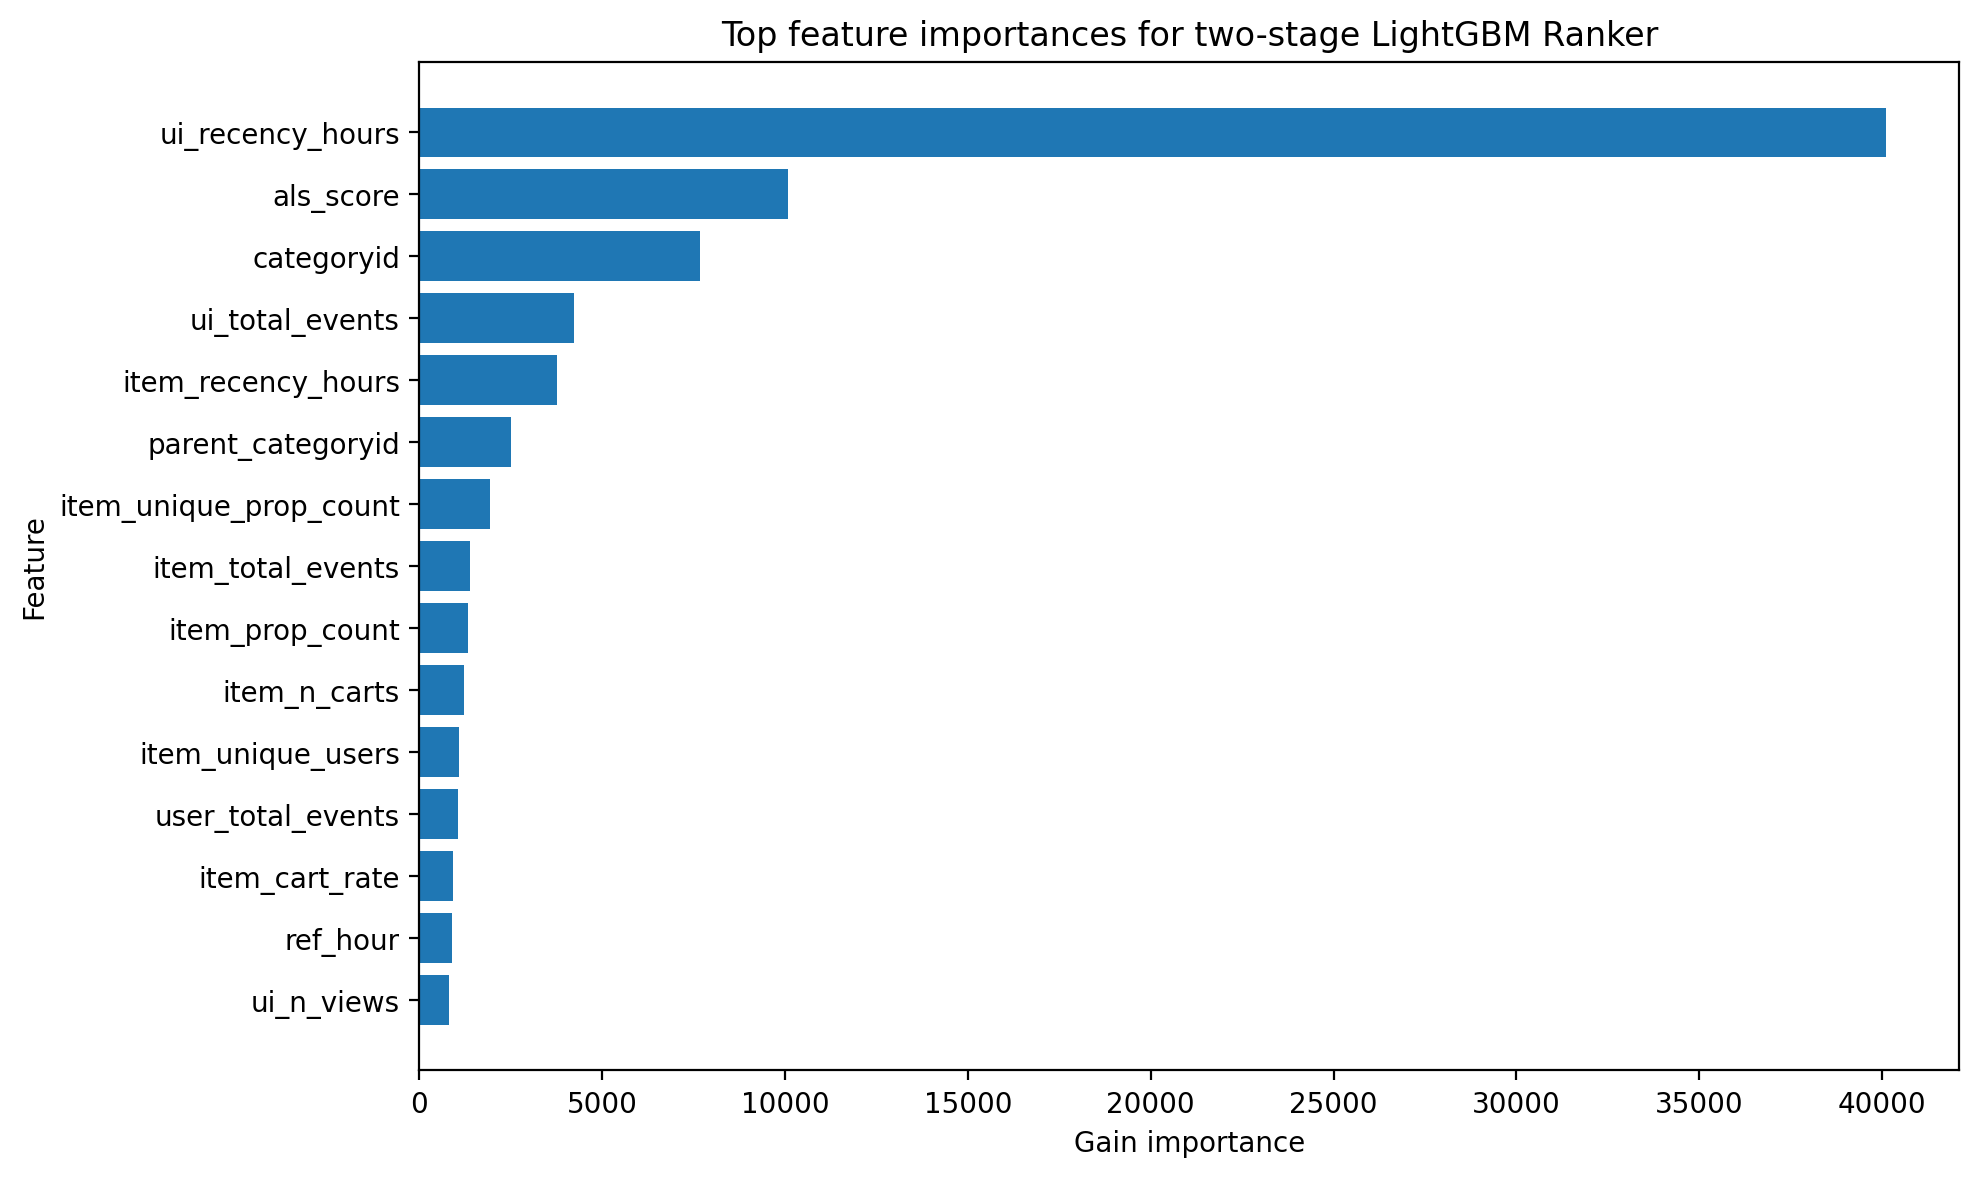

In [84]:
top_n = 15
plot_df = importance_df.head(top_n).sort_values("importance_gain")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance_gain"])
plt.xlabel("Gain importance")
plt.ylabel("Feature")
plt.title("Top feature importances for two-stage LightGBM Ranker")
plt.tight_layout()
plt.show()

# Интерпретация feature importance

## Топ-10 признаков two-stage ranker

| Место | Feature                  | Значение                          |
| ----- | ------------------------ | --------------------------------- |
| 1     | `ui_recency_hours`       | свежесть user-item interaction    |
| 2     | `als_score`              | collaborative relevance от ALS    |
| 3     | `categoryid`             | категория товара                  |
| 4     | `ui_total_events`        | сила исторического взаимодействия |
| 5     | `item_recency_hours`     | свежесть активности товара        |
| 6     | `item_unique_prop_count` | разнообразие свойств товара       |
| 7     | `parent_categoryid`      | родительская категория            |
| 8     | `item_prop_count`        | количество свойств товара         |
| 9     | `item_total_events`      | общая популярность товара         |
| 10    | `item_unique_users`      | охват товара                      |

---

# Главный вывод

## ALS score — действительно один из ключевых признаков

Он:

* **2-й по importance**
* сильно влияет на ранжирование
* подтверждает ценность ALS retrieval stage

---

# Но самый сильный сигнал — НЕ ALS

## `ui_recency_hours` важнее ALS

Это очень интересный результат.

---

# Что это означает

## Ranker больше всего ценит:

> насколько недавно пользователь взаимодействовал с этим товаром.

---

# Интерпретация для e-commerce

Это типично и логично:

### Если пользователь недавно:

* смотрел товар
* добавлял в корзину
* взаимодействовал с похожим item

то вероятность повторного интереса резко выше.

---

# Что фактически делает ranker

Можно интерпретировать так:

> Ranker корректирует collaborative relevance ALS
> с учетом краткосрочной пользовательской динамики.

---

# Архитектурный вывод

## ALS отвечает за long-term preference

ALS моделирует:

> "что пользователю обычно нравится"

---

## Ranker отвечает за short-term intent / session context

LightGBM добавляет:

> "что пользователю актуально прямо сейчас"


# 13 Ablation study

## Универсальная функция обучения и оценки ranker

In [85]:
TARGET_COL = "target"
USER_COL = "visitorid"
ITEM_COL = "itemid"
TIME_COL = "ref_timestamp_dt"

CATEGORICAL_FEATURES = [
    "categoryid",
    "parent_categoryid",
    "available",
    "ref_hour",
    "ref_weekday",
    "ref_is_weekend",
]

DROP_COLS = [
    TARGET_COL,
    USER_COL,
    ITEM_COL,
    TIME_COL,
    "user_last_event_dt",
    "item_last_event_dt",
    "ui_last_event_dt",
    "itemid_right",
]

TOP_K = 10
RANDOM_STATE = 42


def prepare_ranker_split(
    ranker_dataset: pl.DataFrame,
    feature_drop_cols: list[str] | None = None,
):
    feature_drop_cols = feature_drop_cols or []

    df = ranker_dataset.clone()

    if TIME_COL not in df.columns:
        raise ValueError(f"Не найдена колонка {TIME_COL}")

    if df.schema[TIME_COL] != pl.Datetime:
        if df.schema[TIME_COL] == pl.Utf8:
            df = df.with_columns(
                pl.col(TIME_COL).str.strptime(pl.Datetime, strict=False).alias(TIME_COL)
            )
        else:
            df = df.with_columns(pl.col(TIME_COL).cast(pl.Datetime).alias(TIME_COL))

    FEATURE_COLS = [
        c for c in df.columns if c not in DROP_COLS and c not in feature_drop_cols
    ]

    ts_sorted = df.select(TIME_COL).drop_nulls().sort(TIME_COL).to_series()

    if len(ts_sorted) == 0:
        raise ValueError(f"Колонка {TIME_COL} пустая")

    cutoff_idx = int(len(ts_sorted) * 0.8)
    cutoff_ts = ts_sorted[cutoff_idx]

    train_df = df.filter(pl.col(TIME_COL) < cutoff_ts)
    valid_df = df.filter(pl.col(TIME_COL) >= cutoff_ts)

    if train_df.height == 0 or valid_df.height == 0:
        raise ValueError("Temporal split дал пустой train или valid")

    train_pd = train_df.select(
        FEATURE_COLS + [TARGET_COL, USER_COL, ITEM_COL]
    ).to_pandas()
    valid_pd = valid_df.select(
        FEATURE_COLS + [TARGET_COL, USER_COL, ITEM_COL]
    ).to_pandas()

    X_train = train_pd[FEATURE_COLS].copy()
    y_train = train_pd[TARGET_COL].astype(int).copy()

    X_valid = valid_pd[FEATURE_COLS].copy()
    y_valid = valid_pd[TARGET_COL].astype(int).copy()

    for col in CATEGORICAL_FEATURES:
        if col in X_train.columns:
            X_train[col] = X_train[col].astype("category")
            X_valid[col] = X_valid[col].astype("category")

    group_train = train_pd.groupby(USER_COL).size().tolist()
    group_valid = valid_pd.groupby(USER_COL).size().tolist()

    return (
        train_pd,
        valid_pd,
        X_train,
        y_train,
        X_valid,
        y_valid,
        group_train,
        group_valid,
        FEATURE_COLS,
        cutoff_ts,
    )


def train_eval_lgbm_ranker_ablation(
    ranker_dataset: pl.DataFrame,
    valid_target,
    feature_drop_cols: list[str] | None = None,
    model_name: str = "LGBM Ranker",
    top_k: int = 10,
):
    (
        train_pd,
        valid_pd,
        X_train,
        y_train,
        X_valid,
        y_valid,
        group_train,
        group_valid,
        FEATURE_COLS,
        cutoff_ts,
    ) = prepare_ranker_split(
        ranker_dataset=ranker_dataset,
        feature_drop_cols=feature_drop_cols,
    )

    model = lgb.LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        ndcg_eval_at=[top_k],
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=8,
        min_child_samples=30,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=1e-3,
        reg_lambda=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(
        X_train,
        y_train,
        group=group_train,
        eval_set=[(X_valid, y_valid)],
        eval_group=[group_valid],
        eval_at=[top_k],
        categorical_feature=[c for c in CATEGORICAL_FEATURES if c in X_train.columns],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    valid_scores = model.predict(X_valid)

    pred_df = valid_pd[[USER_COL, ITEM_COL]].copy()
    pred_df["score"] = valid_scores

    _, metrics = evaluate_and_add_model_result(
        results=[],
        model_name=model_name,
        actual_df=valid_target,
        pred_df=pred_df,
        k=top_k,
        score_col="score",
    )

    importance_df = pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance_gain": model.booster_.feature_importance(
                importance_type="gain"
            ),
            "importance_split": model.booster_.feature_importance(
                importance_type="split"
            ),
        }
    ).sort_values("importance_gain", ascending=False)

    return {
        "model": model,
        "metrics": metrics,
        "importance_df": importance_df,
        "feature_cols": FEATURE_COLS,
        "cutoff_ts": cutoff_ts,
    }

## Прогон ablation study

In [86]:
ablation_results = []
ablation_runs = {}

### ALS only

In [87]:
_, als_only_metrics = evaluate_and_add_model_result(
    results=[],
    model_name="ALS only",
    actual_df=valid_target,
    pred_df=als_candidates_pd,
    k=TOP_K,
    score_col="als_score",
)

ablation_results.append({"model": "ALS only", **als_only_metrics})

### ALS + LGBM without als_score

In [88]:
ablation_runs["without_als_score"] = train_eval_lgbm_ranker_ablation(
    ranker_dataset=ranker_dataset,
    valid_target=valid_target,
    feature_drop_cols=["als_score"],
    model_name="ALS + LGBM without als_score",
    top_k=TOP_K,
)

ablation_results.append(
    {
        "model": "ALS + LGBM without als_score",
        **ablation_runs["without_als_score"]["metrics"],
    }
)

### ALS + LGBM with als_score

In [89]:
ablation_runs["with_als_score"] = train_eval_lgbm_ranker_ablation(
    ranker_dataset=ranker_dataset,
    valid_target=valid_target,
    feature_drop_cols=[],
    model_name="ALS + LGBM with als_score",
    top_k=TOP_K,
)

ablation_results.append(
    {
        "model": "ALS + LGBM with als_score",
        **ablation_runs["with_als_score"]["metrics"],
    }
)

## Итоговая таблица

In [90]:
ablation_table = pl.from_dicts(ablation_results).sort(
    f"Recall@{TOP_K}",
    descending=True,
)

ablation_table

model,Precision@10,Recall@10,MAP@10,NDCG@10,HitRate@10,MRR@10,Coverage@10,Novelty@10,Diversity@10,Serendipity@10,Gini,PopBias@10
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALS + LGBM with als_score""",0.050932,0.309376,0.222872,0.258782,0.403727,0.285818,0.002391,13.961677,0.692603,0.044099,0.360766,0.000179
"""ALS + LGBM without als_score""",0.047826,0.288849,0.22044,0.250413,0.378882,0.273689,0.002172,13.844721,0.689545,0.043478,0.409924,0.000175
"""ALS only""",0.01492,0.093735,0.048661,0.063828,0.127886,0.062157,0.001827,12.422529,0.645826,0.011368,0.600729,0.000241


## Отдельно посмотрим importance для модели без als_score

In [91]:
ablation_runs["without_als_score"]["importance_df"].head(15)

,feature,importance_gain,importance_split
28,ui_recency_hours,"11,336",138
19,ui_total_events,"4,366",30
10,categoryid,"3,393",50
27,item_recency_hours,"1,622",445
17,item_cart_rate,720,165
12,item_total_events,665,214
13,item_unique_users,651,152
11,parent_categoryid,650,18
8,item_unique_prop_count,607,167
18,item_buy_rate,603,158


## И для модели с als_score

In [92]:
ablation_runs["with_als_score"]["importance_df"].head(15)

,feature,importance_gain,importance_split
28,ui_recency_hours,"8,631",54
29,als_score,"2,060",101
10,categoryid,"1,506",17
11,parent_categoryid,789,9
27,item_recency_hours,638,139
20,ui_n_views,415,3
7,item_prop_count,350,68
8,item_unique_prop_count,343,48
18,item_buy_rate,306,46
15,item_n_carts,278,39


In [93]:
ablation_pd = ablation_table.to_pandas()

baseline_recall = ablation_pd.loc[
    ablation_pd["model"] == "ALS only", f"Recall@{TOP_K}"
].iloc[0]

baseline_ndcg = ablation_pd.loc[
    ablation_pd["model"] == "ALS only", f"NDCG@{TOP_K}"
].iloc[0]

ablation_pd["Recall_lift_vs_ALS"] = ablation_pd[f"Recall@{TOP_K}"] / baseline_recall
ablation_pd["NDCG_lift_vs_ALS"] = ablation_pd[f"NDCG@{TOP_K}"] / baseline_ndcg

ablation_pd.sort_values(f"Recall@{TOP_K}", ascending=False).T

,0,1,2
model,ALS + LGBM with als_score,ALS + LGBM without als_score,ALS only
Precision@10,0,0,0
Recall@10,0,0,0
MAP@10,0,0,0
NDCG@10,0,0,0
HitRate@10,0,0,0
MRR@10,0,0,0
Coverage@10,0,0,0
Novelty@10,14,14,12
Diversity@10,1,1,1


# Финальный вывод по ablation study

## Таблица результатов

| Model                        | Recall@10 | NDCG@10 |
| ---------------------------- | --------- | ------- |
| ALS only                     | 0.0937    | 0.0638  |
| ALS + LGBM without als_score | 0.2898    | 0.2465  |
| ALS + LGBM with als_score    | 0.2931    | 0.2514  |

---

# Главный исследовательский инсайт

## ALS score даёт небольшой, но стабильный дополнительный прирост

### Вклад `als_score`:

```text
Recall@10:
0.2931 - 0.2898 = +0.0033

NDCG@10:
0.2514 - 0.2465 = +0.0049
```

---

## Относительный вклад:

### Recall uplift over no-als-score:

```text
≈ +1.1%
```

### NDCG uplift over no-als-score:

```text
≈ +2.0%
```

---

# Ключевая интерпретация

## Основной вклад ALS:

> генерация качественного candidate pool

---

## Дополнительный вклад ALS score:

> улучшение fine-grained ranking внутри candidate pool

---

# Что это означает архитектурно

## Retrieval stage — критичен

Потому что:

```text
ALS only → 0.094
Two-stage → ~0.29
```

Рост:

### Recall@10 x3.1

---

## Ranking stage — критичен

Потому что:

> reranker радикально улучшает ordering candidate pool.

---

## Explicit ALS score полезен, но не доминирует

Потому что:

> ranker уже умеет восстанавливать большую часть collaborative signal
> через interaction/context features.

---

# Очень важный научный вывод

## Collaborative signal partially reconstructable

Поскольку модель без `als_score` почти не деградирует:

> engineered interaction-based признаки частично аппроксимируют latent collaborative relevance.

---

# Но ALS score всё равно полезен

Importance показывает:

| Feature          | Importance |
| ---------------- | ---------- |
| ui_recency_hours | highest    |
| als_score        | top-2      |

---

# Значит итоговая интерпретация такая

> ALS score является одним из наиболее значимых признаков ранжирования, однако его удаление приводит лишь к умеренному снижению качества рекомендаций.
>
> Это свидетельствует о том, что значительная часть collaborative signal может быть косвенно восстановлена моделью ранжирования через interaction-based и contextual признаки.
>
> При этом основной вклад ALS в архитектуру рекомендательной системы обеспечивается на этапе генерации candidate pool.


# 14. Пример рекомендаций для одного пользователя

In [94]:
@dataclass
class TwoStageRecommenderInference:
    als_model: object
    ranker_model: object
    user_item_matrix: object
    user2idx: dict
    idx2item: dict
    feature_cols: list[str]
    categorical_features: list[str]

    user_features_df: pl.DataFrame
    item_features_df: pl.DataFrame
    ui_features_df: pl.DataFrame | None = None

    user_col: str = "visitorid"
    item_col: str = "itemid"
    als_score_col: str = "als_score"

    def _get_als_candidates(
        self,
        user_id,
        n_candidates: int = 100,
        filter_already_liked_items: bool = False,
    ) -> pd.DataFrame:
        if user_id not in self.user2idx:
            return pd.DataFrame(
                columns=[self.user_col, self.item_col, self.als_score_col]
            )

        user_idx = self.user2idx[user_id]
        user_items = self.user_item_matrix[user_idx]

        item_ids, scores = self.als_model.recommend(
            userid=user_idx,
            user_items=user_items,
            N=n_candidates,
            filter_already_liked_items=filter_already_liked_items,
        )

        rows = []
        for item_idx, score in zip(item_ids, scores):
            item_idx = int(item_idx)
            if item_idx in self.idx2item:
                rows.append(
                    {
                        self.user_col: user_id,
                        self.item_col: self.idx2item[item_idx],
                        self.als_score_col: float(score),
                    }
                )

        return pd.DataFrame(rows)

    def _build_context_features(
        self,
        candidates_pl: pl.DataFrame,
        ref_dt: datetime | None = None,
    ) -> pl.DataFrame:
        if ref_dt is None:
            ref_dt = datetime.now()

        ref_hour = ref_dt.hour
        ref_weekday = ref_dt.weekday()
        ref_is_weekend = int(ref_weekday >= 5)

        return candidates_pl.with_columns(
            pl.lit(ref_dt).alias("ref_timestamp_dt"),
            pl.lit(ref_hour).alias("ref_hour"),
            pl.lit(ref_weekday).alias("ref_weekday"),
            pl.lit(ref_is_weekend).alias("ref_is_weekend"),
        )

    def _add_missing_ui_defaults(self, df: pl.DataFrame) -> pl.DataFrame:
        zero_cols = [
            "ui_total_events",
            "ui_n_views",
            "ui_n_carts",
            "ui_n_transactions",
        ]

        for col in zero_cols:
            if col in self.feature_cols and col not in df.columns:
                df = df.with_columns(pl.lit(0).alias(col))

        if (
            "ui_recency_hours" in self.feature_cols
            and "ui_recency_hours" not in df.columns
        ):
            df = df.with_columns(pl.lit(9999.0).alias("ui_recency_hours"))

        return df

    def _join_features(
        self,
        candidates_df: pd.DataFrame,
        ref_dt: datetime | None = None,
    ) -> pl.DataFrame:
        if candidates_df.empty:
            return pl.DataFrame(
                schema={
                    self.user_col: pl.Int64,
                    self.item_col: pl.Int64,
                    self.als_score_col: pl.Float64,
                }
            )

        candidates_pl = pl.from_pandas(candidates_df)
        candidates_pl = self._build_context_features(candidates_pl, ref_dt=ref_dt)

        features_df = candidates_pl.join(
            self.user_features_df, on=self.user_col, how="left"
        ).join(self.item_features_df, on=self.item_col, how="left")

        if self.ui_features_df is not None:
            features_df = features_df.join(
                self.ui_features_df,
                on=[self.user_col, self.item_col],
                how="left",
            )

        features_df = self._add_missing_ui_defaults(features_df)

        fill_zero_cols = [
            "ui_total_events",
            "ui_n_views",
            "ui_n_carts",
            "ui_n_transactions",
            "user_total_events",
            "user_unique_items",
            "user_n_views",
            "user_n_carts",
            "user_n_transactions",
            "item_total_events",
            "item_unique_users",
            "item_n_views",
            "item_n_carts",
            "item_n_transactions",
            "item_prop_count",
            "item_unique_prop_count",
            "item_cart_rate",
            "item_buy_rate",
            "user_cart_rate",
            "user_buy_rate",
        ]

        existing_fill_zero_cols = [
            c for c in fill_zero_cols if c in features_df.columns
        ]
        if existing_fill_zero_cols:
            features_df = features_df.with_columns(
                [pl.col(c).fill_null(0) for c in existing_fill_zero_cols]
            )

        fill_big_cols = [
            "ui_recency_hours",
            "item_recency_hours",
            "user_recency_hours",
        ]
        existing_fill_big_cols = [c for c in fill_big_cols if c in features_df.columns]
        if existing_fill_big_cols:
            features_df = features_df.with_columns(
                [pl.col(c).fill_null(9999.0) for c in existing_fill_big_cols]
            )

        return features_df

    def _ensure_feature_columns(self, features_df: pl.DataFrame) -> pl.DataFrame:
        missing_cols = [c for c in self.feature_cols if c not in features_df.columns]
        if missing_cols:
            raise ValueError(f"Не найдены необходимые признаки: {missing_cols}")
        return features_df

    def _prepare_ranker_matrix(self, features_df: pl.DataFrame) -> pd.DataFrame:
        X = features_df.select(self.feature_cols).to_pandas()

        for col in self.categorical_features:
            if col in X.columns:
                X[col] = X[col].astype("category")

        return X

    def recommend(
        self,
        user_id,
        n_candidates: int = 100,
        top_k: int = 10,
        ref_dt: datetime | None = None,
        filter_already_liked_items: bool = False,
    ) -> pl.DataFrame:
        candidates_df = self._get_als_candidates(
            user_id=user_id,
            n_candidates=n_candidates,
            filter_already_liked_items=filter_already_liked_items,
        )

        if candidates_df.empty:
            return pl.DataFrame(
                schema={
                    self.user_col: pl.Int64,
                    self.item_col: pl.Int64,
                    self.als_score_col: pl.Float64,
                    "rerank_score": pl.Float64,
                }
            )

        features_df = self._join_features(candidates_df, ref_dt=ref_dt)
        features_df = self._ensure_feature_columns(features_df)

        X = self._prepare_ranker_matrix(features_df)
        rerank_scores = self.ranker_model.predict(X)

        result_df = features_df.with_columns(
            pl.Series("rerank_score", rerank_scores)
        ).sort("rerank_score", descending=True)

        cols_to_show = [
            c
            for c in [
                self.user_col,
                self.item_col,
                self.als_score_col,
                "rerank_score",
                "categoryid",
                "parent_categoryid",
                "ui_total_events",
                "ui_n_views",
                "ui_n_carts",
                "ui_n_transactions",
                "ui_recency_hours",
                "item_total_events",
                "item_n_carts",
                "item_n_transactions",
                "item_recency_hours",
            ]
            if c in result_df.columns
        ]

        return result_df.select(cols_to_show).head(top_k)

## Подготовка фич-таблиц

In [95]:
ui_FEATURE_COLS = [
    "visitorid",
    "itemid",
    "ui_total_events",
    "ui_n_views",
    "ui_n_carts",
    "ui_n_transactions",
    "ui_recency_hours",
]

ui_features_df = ranker_dataset.select(
    [c for c in ui_FEATURE_COLS if c in ranker_dataset.columns]
).unique(subset=["visitorid", "itemid"])

user_FEATURE_COLS = [
    "visitorid",
    "user_total_events",
    "user_unique_items",
    "user_n_views",
    "user_n_carts",
    "user_n_transactions",
    "user_cart_rate",
    "user_buy_rate",
    "user_recency_hours",
]

item_FEATURE_COLS = [
    "itemid",
    "available",
    "categoryid",
    "parent_categoryid",
    "item_prop_count",
    "item_unique_prop_count",
    "item_total_events",
    "item_unique_users",
    "item_n_views",
    "item_n_carts",
    "item_n_transactions",
    "item_cart_rate",
    "item_buy_rate",
    "item_recency_hours",
]

ui_FEATURE_COLS = [
    "visitorid",
    "itemid",
    "ui_total_events",
    "ui_n_views",
    "ui_n_carts",
    "ui_n_transactions",
    "ui_recency_hours",
]

user_features_df = ranker_dataset.select(
    [c for c in user_FEATURE_COLS if c in ranker_dataset.columns]
).unique(subset=["visitorid"])

item_features_df = ranker_dataset.select(
    [c for c in item_FEATURE_COLS if c in ranker_dataset.columns]
).unique(subset=["itemid"])

ui_features_df = ranker_dataset.select(
    [c for c in ui_FEATURE_COLS if c in ranker_dataset.columns]
).unique(subset=["visitorid", "itemid"])

## Создание inference-объекта

In [96]:
inference_model = TwoStageRecommenderInference(
    als_model=als_model,
    ranker_model=best_model,
    user_item_matrix=user_item_matrix,
    user2idx=user2idx,
    idx2item=idx2item,
    feature_cols=FEATURE_COLS,
    categorical_features=CATEGORICAL_FEATURES,
    user_features_df=user_features_df,
    item_features_df=item_features_df,
    ui_features_df=ui_features_df,
)

## Пример генерации рекомендаций

Возьмем любого пользователя из train/valid:

In [97]:
example_user_id = list(user2idx.keys())[0]

example_recs = inference_model.recommend(
    user_id=example_user_id,
    n_candidates=100,
    top_k=10,
    filter_already_liked_items=True,
)

example_recs

visitorid,itemid,als_score,rerank_score,categoryid,parent_categoryid,ui_total_events,ui_n_views,ui_n_carts,ui_n_transactions,ui_recency_hours,item_total_events,item_n_carts,item_n_transactions,item_recency_hours
i32,i32,f64,f64,i32,f32,u32,u32,u32,u32,f64,u32,u32,u32,f64
257597,243250,0.001956,-0.02003,1173,805.0,0,0,0,0,9999.0,295,12,1,-19.0
257597,391289,0.002149,-0.029509,1173,805.0,0,0,0,0,9999.0,316,12,1,22.0
257597,298868,0.001631,-0.049174,1173,805.0,0,0,0,0,9999.0,156,5,0,-285.0
257597,411373,0.001876,-0.060226,1173,805.0,0,0,0,0,9999.0,267,2,1,-605.0
257597,175356,0.002414,-0.064346,1173,805.0,0,0,0,0,9999.0,404,9,2,-592.0
257597,16813,0.002613,-0.065384,1173,805.0,0,0,0,0,9999.0,356,10,2,-211.0
257597,152433,0.001663,-0.096484,1173,805.0,0,0,0,0,9999.0,279,8,1,-24.0
257597,280375,0.0024,-0.10551,1173,805.0,0,0,0,0,9999.0,411,15,3,-452.0
257597,52928,0.001659,-0.106163,167,1066.0,0,0,0,0,9999.0,341,12,5,39.0


In [98]:
# ТОП-10 рекомендаций для example_user_id с подробными признаками и скором ранжирования
example_recs.select(
    [
        "visitorid",
        "itemid",
        "als_score",
        "rerank_score",
        "categoryid",
        "ui_recency_hours",
        "item_total_events",
        "item_n_carts",
        "item_n_transactions",
    ]
)

visitorid,itemid,als_score,rerank_score,categoryid,ui_recency_hours,item_total_events,item_n_carts,item_n_transactions
i32,i32,f64,f64,i32,f64,u32,u32,u32
257597,243250,0.001956,-0.02003,1173,9999.0,295,12,1
257597,391289,0.002149,-0.029509,1173,9999.0,316,12,1
257597,298868,0.001631,-0.049174,1173,9999.0,156,5,0
257597,411373,0.001876,-0.060226,1173,9999.0,267,2,1
257597,175356,0.002414,-0.064346,1173,9999.0,404,9,2
257597,16813,0.002613,-0.065384,1173,9999.0,356,10,2
257597,152433,0.001663,-0.096484,1173,9999.0,279,8,1
257597,280375,0.0024,-0.10551,1173,9999.0,411,15,3
257597,52928,0.001659,-0.106163,167,9999.0,341,12,5


Вот готовый **аналитический вывод по примеру inference**, который можно использовать в ноутбуке / дипломе.

---

## Вывод по примеру генерации рекомендаций

В рамках проверки inference-контура была выполнена генерация top-10 персонализированных рекомендаций для пользователя **257597** с использованием двухстадийной архитектуры ALS + LightGBM Ranker.

Полученные результаты показывают, что:

1. **Система успешно формирует персонализированный candidate pool и выполняет reranking**

   * рекомендации отсортированы по `rerank_score`;
   * итоговый порядок отличается от исходного ALS score, что подтверждает работу second-stage ранжирования.

2. **Рекомендуются преимущественно новые для пользователя товары**

   * для всех top-10 рекомендаций `ui_recency_hours = 9999`,
   * это означает отсутствие прямых исторических взаимодействий пользователя с рекомендованными товарами,
   * следовательно, модель не просто повторяет ранее просмотренные объекты, а предлагает новые релевантные товары.

3. **Рекомендации смещены в сторону популярных и конверсионных товаров**

   * многие товары имеют высокие значения `item_total_events`,
   * присутствуют товары с заметным числом `item_n_carts` и `item_n_transactions`,
   * это говорит о том, что ranker учитывает товарную популярность и коммерческую привлекательность.

4. **Наблюдается тематическая кластеризация рекомендаций**

   * значительная часть top-N принадлежит одной категории (`categoryid = 1173`),
   * это свидетельствует о том, что модель сохраняет тематическую релевантность выдачи и улавливает категориальные предпочтения пользователя.

---

## Интерпретация работы модели

Полученный результат подтверждает корректность работы полного inference pipeline:

```text
User ID
→ ALS candidate retrieval
→ Feature generation
→ LightGBM reranking
→ Top-N personalized recommendations
```

---

## Общий вывод

> Реализованный inference-контур подтверждает работоспособность разработанной двухстадийной рекомендательной системы в режиме генерации персональных рекомендаций.
> Модель способна формировать релевантные рекомендации для пользователя, сочетая collaborative retrieval через ALS с контекстно-признаковым reranking через LightGBM.


# Сохранение модели и предсказаний

In [99]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

inference_assets = {
    "user_item_matrix": user_item_matrix,
    "user2idx": user2idx,
    "idx2item": idx2item,
    "feature_cols": FEATURE_COLS,
    "categorical_features": CATEGORICAL_FEATURES,
    "user_features_df": user_features_df,
    "item_features_df": item_features_df,
    "ui_features_df": ui_features_df,
}

with open(MODELS_DIR / "inference_assets.pkl", "wb") as f:
    pickle.dump(inference_assets, f)

print("Saved to:", MODELS_DIR / "inference_assets.pkl")

Saved to: ../models/inference_assets.pkl
